# Step 0 — Two-Phase Experiment Configuration (small ↔ full)

In [1]:
from pathlib import Path
import json
import datetime as dt

from dataclasses import dataclass
from typing import Union, Tuple, Dict, Sequence, Optional, List, Any

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
import random

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
import time

import shutil

In [2]:
!ls ../../data/inputs/label/label_test.tif

../../data/inputs/label/label_test.tif


In [3]:
# ---- Phase switch ----
PHASE = "small"   # "small" (4 scenes) or "full" (full area)

# ---- Shared defaults (match your baseline conventions) ----
seed = 42
num_classes = 3
label_values = [0, 1, 2]
nodata_value = -9999
ignore_index = -9999

in_channels = 6
bands = ["R", "G", "B", "NIR", "SWIR1", "SWIR2"]
normalisation = "per_band_mean_std"  # computed on TRAIN patches only

# ---- Phase configs ----
CONFIGS = {
    "small": {
        # TODO: set these paths to your 4-scene composite + labels
        "img_path": "../../data/inputs/map/map_test.tif",
        "lbl_path": "../../data/inputs/label/label_test.tif",

        # spatial design (keep same style; can keep p256 for comparability)
        "patch_size": 256,
        "stride_train": 256,
        "block_size": 2048,

        # MC dropout + runtime budget
        "T_mc": 10,
        "max_epochs": 10,       # keep short in Phase 1
        "n_runs": 1,            # 1 seed for speed in Phase 1

        # outputs
        "split_dir": "../../data/outputs/proposed/small_unet_mcdo_p256_b2048",
    },
    "full": {
        # TODO: set these paths to your full composite + labels
        "img_path": "../../data/inputs/map/map.tif",
        "lbl_path": "../../data/inputs/label/para_three_class.tif",

        # match baseline final design exactly (recommended)
        "patch_size": 256,
        "stride_train": 256,
        "block_size": 2048,

        # MC dropout + runtime budget
        "T_mc": 20,
        "max_epochs": 50,       # early stopping will decide actual stop
        "n_runs": 1,            # start with 1 seed; expand later if needed

        # outputs
        "split_dir": "../../data/outputs/proposed/full_unet_mcdo_p256_b2048",
    },
}

assert PHASE in CONFIGS, f"PHASE must be one of {list(CONFIGS.keys())}"

cfg = CONFIGS[PHASE].copy()
cfg.update({
    "phase": PHASE,
    "seed": seed,
    "num_classes": num_classes,
    "label_values": label_values,
    "nodata_value": nodata_value,
    "ignore_index": ignore_index,
    "in_channels": in_channels,
    "bands": bands,
    "normalisation": normalisation,
    "timestamp_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
})

# ---- Prepare output directory + save config ----
split_dir = Path(cfg["split_dir"])
split_dir.mkdir(parents=True, exist_ok=True)

config_path = split_dir / "config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(cfg, f, indent=2, sort_keys=True)

# ---- Print active config summary ----
print("=== Active phase configuration ===")
print(f"PHASE        : {cfg['phase']}")
print(f"img_path     : {cfg['img_path']}")
print(f"lbl_path     : {cfg['lbl_path']}")
print(f"patch_size   : {cfg['patch_size']}")
print(f"stride_train : {cfg['stride_train']}")
print(f"block_size   : {cfg['block_size']}")
print(f"T_mc         : {cfg['T_mc']}")
print(f"max_epochs   : {cfg['max_epochs']}")
print(f"n_runs       : {cfg['n_runs']}")
print(f"outputs      : {split_dir}")
print(f"saved config : {config_path}")

=== Active phase configuration ===
PHASE        : small
img_path     : ../../data/inputs/map/map_test.tif
lbl_path     : ../../data/inputs/label/label_test.tif
patch_size   : 256
stride_train : 256
block_size   : 2048
T_mc         : 10
max_epochs   : 10
n_runs       : 1
outputs      : ../../data/outputs/proposed/small_unet_mcdo_p256_b2048
saved config : ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/config.json


# Step 1 — Build / Export / Reload Splits (+ train mean/std)

In [4]:
# ----------------------------
# 1.1 PatchSpec + patch grid
# ----------------------------

from dataclasses import dataclass
from pathlib import Path
from typing import Union, Tuple, Dict, Sequence, Optional, List
import rasterio

@dataclass(frozen=True)
class PatchSpec:
    row_off: int
    col_off: int
    height: int
    width: int

def build_patch_index(
    img_path: Union[str, Path],
    lbl_path: Union[str, Path],
    patch_size: int,
    stride: int,
) -> List[PatchSpec]:
    img_path = Path(img_path)
    lbl_path = Path(lbl_path)

    with rasterio.open(img_path) as img, rasterio.open(lbl_path) as lbl:
        assert img.width == lbl.width and img.height == lbl.height, "Shape mismatch"
        assert img.transform == lbl.transform, "Transform mismatch"
        assert img.crs == lbl.crs, "CRS mismatch"

        H, W = img.height, img.width
        patches: List[PatchSpec] = []

        for row_off in range(0, H - patch_size + 1, stride):
            for col_off in range(0, W - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))

        # edge coverage
        if (H - patch_size) % stride != 0:
            row_off = H - patch_size
            for col_off in range(0, W - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))
        if (W - patch_size) % stride != 0:
            col_off = W - patch_size
            for row_off in range(0, H - patch_size + 1, stride):
                patches.append(PatchSpec(row_off, col_off, patch_size, patch_size))
        if (H - patch_size) % stride != 0 and (W - patch_size) % stride != 0:
            patches.append(PatchSpec(H - patch_size, W - patch_size, patch_size, patch_size))

    return patches


# ----------------------------
# 1.2 Block split (same as baseline)
# ----------------------------

def assign_block_id(p: PatchSpec, block_size: int) -> Tuple[int, int]:
    block_row = p.row_off // block_size
    block_col = p.col_off // block_size
    return (block_row, block_col)

def spatial_block_split(
    patches: Sequence[PatchSpec],
    block_size: int,
    ratios=(0.70, 0.15, 0.15),
    seed: int = 42,
):
    assert abs(sum(ratios) - 1.0) < 1e-6, "ratios must sum to 1"

    block_to_patches: Dict[Tuple[int, int], list[PatchSpec]] = {}
    for p in patches:
        bid = assign_block_id(p, block_size)
        block_to_patches.setdefault(bid, []).append(p)

    block_ids = list(block_to_patches.keys())
    rng = random.Random(seed)
    rng.shuffle(block_ids)

    n = len(block_ids)
    n_train = int(ratios[0] * n)
    n_val   = int(ratios[1] * n)

    train_blocks = set(block_ids[:n_train])
    val_blocks   = set(block_ids[n_train:n_train + n_val])
    test_blocks  = set(block_ids[n_train + n_val:])

    train = [p for bid in train_blocks for p in block_to_patches[bid]]
    val   = [p for bid in val_blocks   for p in block_to_patches[bid]]
    test  = [p for bid in test_blocks  for p in block_to_patches[bid]]

    return train, val, test, train_blocks, val_blocks, test_blocks


# ----------------------------
# 1.3 Filter empty-label patches (same as baseline)
# ----------------------------

def has_any_valid_label(lbl_path: Union[str, Path], p: PatchSpec, ignore_index: int) -> bool:
    with rasterio.open(lbl_path) as lbl:
        w = Window(p.col_off, p.row_off, p.width, p.height)
        y = lbl.read(1, window=w)
    return np.any(y != ignore_index)

def filter_all_ignore_patches(lbl_path: Union[str, Path], patch_list: Sequence[PatchSpec], ignore_index: int):
    return [p for p in patch_list if has_any_valid_label(lbl_path, p, ignore_index=ignore_index)]


# ----------------------------
# 1.4 Train-only mean/std (same as baseline)
# ----------------------------

def estimate_mean_std(
    img_path: Union[str, Path],
    patch_list: Sequence[PatchSpec],
    nodata_value: int,
    max_patches: int = 400,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    n = min(max_patches, len(patch_list))
    sample = rng.choice(np.array(patch_list, dtype=object), size=n, replace=False)

    sums = None
    sumsqs = None
    counts = None

    with rasterio.open(img_path) as img:
        for p in sample:
            w = Window(p.col_off, p.row_off, p.width, p.height)
            x = img.read(window=w).astype(np.float32)  # [C,H,W]

            valid = x != nodata_value

            if sums is None:
                C = x.shape[0]
                sums   = np.zeros(C, dtype=np.float64)
                sumsqs = np.zeros(C, dtype=np.float64)
                counts = np.zeros(C, dtype=np.int64)

            for c in range(x.shape[0]):
                vc = valid[c]
                vals = x[c][vc]
                counts[c] += vals.size
                if vals.size > 0:
                    sums[c]   += vals.sum(dtype=np.float64)
                    sumsqs[c] += (vals.astype(np.float64) ** 2).sum(dtype=np.float64)

    mean = sums / np.maximum(counts, 1)
    var  = (sumsqs / np.maximum(counts, 1)) - mean**2
    std  = np.sqrt(np.maximum(var, 1e-12))

    return mean.astype(np.float32), std.astype(np.float32)


# ----------------------------
# 1.5 Export / load patch specs
# ----------------------------

def export_patch_specs(patches: Sequence[PatchSpec], csv_path: Path) -> pd.DataFrame:
    df = pd.DataFrame([{
        "row_off": p.row_off,
        "col_off": p.col_off,
        "height":  p.height,
        "width":   p.width,
    } for p in patches])
    df.to_csv(csv_path, index=False)
    return df

def load_patch_specs(csv_path: Path) -> List[PatchSpec]:
    df = pd.read_csv(csv_path)
    return [PatchSpec(int(r.row_off), int(r.col_off), int(r.height), int(r.width))
            for r in df.itertuples(index=False)]


# ----------------------------
# 1.6 Build or load splits (export always, like baseline)
# ----------------------------

def build_export_or_load_splits(
    img_path: Union[str, Path],
    lbl_path: Union[str, Path],
    split_dir: Path,
    patch_size: int,
    stride_train: int,
    block_size: int,
    ratios=(0.70, 0.15, 0.15),
    seed: int = 42,
    nodata_value: int = -9999,
    ignore_index: int = -9999,
):
    split_dir.mkdir(parents=True, exist_ok=True)

    train_csv = split_dir / "train_patches.csv"
    val_csv   = split_dir / "val_patches.csv"
    test_csv  = split_dir / "test_patches.csv"
    mean_npy  = split_dir / "train_mean.npy"
    std_npy   = split_dir / "train_std.npy"

    # If already exists, load to stay reproducible
    if train_csv.exists() and val_csv.exists() and test_csv.exists() and mean_npy.exists() and std_npy.exists():
        train_patches = load_patch_specs(train_csv)
        val_patches   = load_patch_specs(val_csv)
        test_patches  = load_patch_specs(test_csv)
        train_mean    = np.load(mean_npy)
        train_std     = np.load(std_npy)

        meta = {"mode": "loaded_existing"}
        return train_patches, val_patches, test_patches, train_mean, train_std, meta

    # Otherwise build & export
    patches = build_patch_index(img_path, lbl_path, patch_size=patch_size, stride=stride_train)

    train_patches, val_patches, test_patches, train_blocks, val_blocks, test_blocks = spatial_block_split(
        patches, block_size=block_size, ratios=ratios, seed=seed
    )

    train_patches = filter_all_ignore_patches(lbl_path, train_patches, ignore_index=ignore_index)
    val_patches   = filter_all_ignore_patches(lbl_path, val_patches,   ignore_index=ignore_index)
    test_patches  = filter_all_ignore_patches(lbl_path, test_patches,  ignore_index=ignore_index)

    export_patch_specs(train_patches, train_csv)
    export_patch_specs(val_patches,   val_csv)
    export_patch_specs(test_patches,  test_csv)

    # export blocks too (nice for reporting)
    pd.DataFrame(sorted(list(train_blocks)), columns=["block_row", "block_col"]).to_csv(split_dir/"train_blocks.csv", index=False)
    pd.DataFrame(sorted(list(val_blocks)),   columns=["block_row", "block_col"]).to_csv(split_dir/"val_blocks.csv",   index=False)
    pd.DataFrame(sorted(list(test_blocks)),  columns=["block_row", "block_col"]).to_csv(split_dir/"test_blocks.csv",  index=False)

    train_mean, train_std = estimate_mean_std(
        img_path=img_path,
        patch_list=train_patches,
        nodata_value=nodata_value,
        max_patches=400,
        seed=seed,
    )
    np.save(mean_npy, train_mean)
    np.save(std_npy, train_std)

    meta = {
        "mode": "built_and_exported",
        "n_patches_total": len(patches),
        "n_train_blocks": len(train_blocks),
        "n_val_blocks": len(val_blocks),
        "n_test_blocks": len(test_blocks),
    }
    return train_patches, val_patches, test_patches, train_mean, train_std, meta


# ----------------------------
# 1.7 Integrity checks (no duplicates across splits)
# ----------------------------

def keys_from_patches(patches: Sequence[PatchSpec]):
    return set((p.row_off, p.col_off, p.height, p.width) for p in patches)

def integrity_check_no_duplicates(train_patches, val_patches, test_patches):
    kt = keys_from_patches(train_patches)
    kv = keys_from_patches(val_patches)
    ks = keys_from_patches(test_patches)

    inter_tv = len(kt & kv)
    inter_ts = len(kt & ks)
    inter_vs = len(kv & ks)

    print("Duplicate patch keys across splits (should all be 0):")
    print("Train ∩ Val :", inter_tv)
    print("Train ∩ Test:", inter_ts)
    print("Val ∩ Test  :", inter_vs)

    assert inter_tv == 0 and inter_ts == 0 and inter_vs == 0, "Overlap detected across splits!"


# ----------------------------
# 1.8 Run Step 1 using cfg from Step 0
# ----------------------------

img_path = cfg["img_path"]
lbl_path = cfg["lbl_path"]
patch_size = int(cfg["patch_size"])
stride_train = int(cfg["stride_train"])
block_size = int(cfg["block_size"])
ratios = (0.70, 0.15, 0.15)

train_patches, val_patches, test_patches, train_mean, train_std, meta = build_export_or_load_splits(
    img_path=img_path,
    lbl_path=lbl_path,
    split_dir=split_dir,
    patch_size=patch_size,
    stride_train=stride_train,
    block_size=block_size,
    ratios=ratios,
    seed=cfg["seed"],
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
)

print("\n=== Split build/load ===")
print("Mode:", meta.get("mode"))
print("Train/Val/Test:", len(train_patches), len(val_patches), len(test_patches))
if "n_patches_total" in meta:
    print("Total patches (pre-filter):", meta["n_patches_total"])
    print("Blocks (train/val/test):", meta["n_train_blocks"], meta["n_val_blocks"], meta["n_test_blocks"])

# Integrity check: no duplicates across splits
integrity_check_no_duplicates(train_patches, val_patches, test_patches)

print("\nSaved artefacts in:", split_dir)
print(" - train/val/test CSVs")
print(" - train_mean.npy, train_std.npy")
print(" - train/val/test blocks CSVs (optional)")


=== Split build/load ===
Mode: loaded_existing
Train/Val/Test: 2012 432 520
Duplicate patch keys across splits (should all be 0):
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Saved artefacts in: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048
 - train/val/test CSVs
 - train_mean.npy, train_std.npy
 - train/val/test blocks CSVs (optional)


## Add-on: Block ratio report + optional ROI coverage check

In [5]:
# ----------------------------
# A) Report block ratios (based on exported block CSVs)
# ----------------------------

train_blocks_csv = split_dir / "train_blocks.csv"
val_blocks_csv   = split_dir / "val_blocks.csv"
test_blocks_csv  = split_dir / "test_blocks.csv"

train_blocks_df = pd.read_csv(train_blocks_csv)
val_blocks_df   = pd.read_csv(val_blocks_csv)
test_blocks_df  = pd.read_csv(test_blocks_csv)

n_train_b = len(train_blocks_df)
n_val_b   = len(val_blocks_df)
n_test_b  = len(test_blocks_df)
n_total_b = n_train_b + n_val_b + n_test_b

print("=== Block ratio report ===")
print(f"Blocks (train/val/test): {n_train_b} / {n_val_b} / {n_test_b} (total={n_total_b})")
print(
    "Block ratios:",
    f"train={n_train_b/n_total_b:.3f},",
    f"val={n_val_b/n_total_b:.3f},",
    f"test={n_test_b/n_total_b:.3f}",
)
print("Target ratios:", f"train={ratios[0]:.3f}, val={ratios[1]:.3f}, test={ratios[2]:.3f}")


# ----------------------------
# B) Optional ROI coverage overlap check (pixel-space)
#    Confirms patches across splits do not overlap within a chosen ROI.
# ----------------------------

# Load exported split CSVs (patch lists)
train_df = pd.read_csv(split_dir / "train_patches.csv")
val_df   = pd.read_csv(split_dir / "val_patches.csv")
test_df  = pd.read_csv(split_dir / "test_patches.csv")

def intersects_roi(df, roi):
    r0, c0, r1, c1 = roi
    pr0 = df["row_off"].to_numpy()
    pc0 = df["col_off"].to_numpy()
    pr1 = pr0 + df["height"].to_numpy()
    pc1 = pc0 + df["width"].to_numpy()
    return (pr0 < r1) & (pr1 > r0) & (pc0 < c1) & (pc1 > c0)

def coverage_map(df_roi, roi):
    r0, c0, r1, c1 = roi
    cov = np.zeros((r1 - r0, c1 - c0), dtype=np.uint8)
    for r in df_roi.itertuples(index=False):
        rr0 = max(r.row_off, r0) - r0
        cc0 = max(r.col_off, c0) - c0
        rr1 = min(r.row_off + r.height, r1) - r0
        cc1 = min(r.col_off + r.width, c1) - c0
        cov[rr0:rr1, cc0:cc1] += 1
    return cov

# Pick an ROI automatically: centred around the median train patch top-left
# (You can also hard-code values if you prefer)
roi_size = 2048  # same as block size; adjust if you want smaller/faster
roi_center_row = int(train_df["row_off"].median())
roi_center_col = int(train_df["col_off"].median())

r0 = max(0, roi_center_row - roi_size // 2)
c0 = max(0, roi_center_col - roi_size // 2)
r1 = r0 + roi_size
c1 = c0 + roi_size
roi = (r0, c0, r1, c1)

train_roi = train_df[intersects_roi(train_df, roi)]
val_roi   = val_df[intersects_roi(val_df, roi)]
test_roi  = test_df[intersects_roi(test_df, roi)]

cov = coverage_map(train_roi, roi) + coverage_map(val_roi, roi) + coverage_map(test_roi, roi)

print("\n=== ROI coverage overlap check ===")
print("ROI:", roi, "(row0, col0, row1, col1)")
print("ROI patch counts (train/val/test):", len(train_roi), len(val_roi), len(test_roi))
print("Unique coverage values:", np.unique(cov))
print("Max coverage (should be 1):", int(cov.max()))

assert cov.max() <= 1, "Overlap detected in ROI coverage map!"

# Optional quick plot (uncomment if you want a visual)
# import matplotlib.pyplot as plt
# plt.figure(figsize=(6, 6))
# plt.imshow(cov, interpolation="nearest")
# plt.title("ROI coverage count (max=1 means no overlap)")
# plt.axis("off")
# plt.show()

=== Block ratio report ===
Blocks (train/val/test): 34 / 7 / 8 (total=49)
Block ratios: train=0.694, val=0.143, test=0.163
Target ratios: train=0.700, val=0.150, test=0.150

=== ROI coverage overlap check ===
ROI: (6144, 6144, 8192, 8192) (row0, col0, row1, col1)
ROI patch counts (train/val/test): 64 0 0
Unique coverage values: [1]
Max coverage (should be 1): 1


# Step 2 — Build U-Net with Dropout (MC Dropout compatible)

In [6]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# 2.A Explicit dropout blocks (thesis-safe)
# ----------------------------

class ConvBnReluDrop(nn.Module):
    def __init__(self, in_ch, out_ch, p=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=p),
        )

    def forward(self, x):
        return self.block(x)

class SimpleDecoderBlock(nn.Module):
    """
    Decoder block:
    - upsample
    - concat skip
    - two convs (each followed by dropout)
    """
    def __init__(self, in_ch, skip_ch, out_ch, p=0.2):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv1 = ConvBnReluDrop(in_ch + skip_ch, out_ch, p=p)
        self.conv2 = ConvBnReluDrop(out_ch, out_ch, p=p)

    def forward(self, x, skip):
        x = self.upsample(x)
        if skip is not None:
            # In SMP, skip and x are usually same spatial size after upsample
            x = torch.cat([x, skip], dim=1)
        return self.conv2(self.conv1(x))

class DropoutDecoder(nn.Module):
    """
    A lightweight U-Net style decoder that consumes encoder feature maps.

    SMP encoders typically return a list of features:
      features[0] = input-level / shallow
      ...
      features[-1] = deepest
    We decode from deepest to shallowest, using skips.
    """
    def __init__(self, encoder_channels, decoder_channels=(256, 128, 64, 32, 16), p=0.2):
        super().__init__()
        # encoder_channels is a list like [C0, C1, C2, C3, C4, C5]
        # We'll use features[-1] as start, and skip from features[-2], ..., features[0]
        enc_ch = list(encoder_channels)

        # number of decode steps is len(decoder_channels)
        # We will map:
        #   x starts at enc_ch[-1]
        #   skip channels: enc_ch[-2], enc_ch[-3], ..., enc_ch[-(n_steps+1)]
        in_ch = enc_ch[-1]
        skip_list = enc_ch[-2::-1]  # reversed skips

        blocks = []
        for i, out_ch in enumerate(decoder_channels):
            skip_ch = skip_list[i] if i < len(skip_list) else 0
            blocks.append(SimpleDecoderBlock(in_ch=in_ch, skip_ch=skip_ch, out_ch=out_ch, p=p))
            in_ch = out_ch

        self.blocks = nn.ModuleList(blocks)
        self.out_channels = decoder_channels[-1]

    def forward(self, *features):
        # SMP calls decoder(*features), so features arrives as a tuple
        features = list(features)

        x = features[-1]
        skips = features[-2::-1]  # deepest skip first

        for i, block in enumerate(self.blocks):
            skip = skips[i] if i < len(skips) else None
            x = block(x, skip)
        return x


# ----------------------------
# 2.B Build SMP U-Net and swap decoder
# ----------------------------

def build_unet_mcdo_explicit(drop_p=0.2):
    base = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=cfg["in_channels"],
        classes=cfg["num_classes"],
        activation=None,
    )

    # Get encoder channel sizes from SMP encoder
    encoder_channels = base.encoder.out_channels  # common SMP attribute

    # Build our dropout decoder
    decoder = DropoutDecoder(
        encoder_channels=encoder_channels,
        decoder_channels=(256, 128, 64, 32, 16),
        p=drop_p,
    )

    # Replace decoder + replace segmentation head to match decoder output channels
    base.decoder = decoder
    base.segmentation_head = nn.Conv2d(decoder.out_channels, cfg["num_classes"], kernel_size=1)

    return base

DROP_P = 0.2
model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

# ----------------------------
# 2.C Outputs: verify explicit dropout exists
# ----------------------------
drop_modules = [name for name, m in model.named_modules() if isinstance(m, nn.Dropout2d)]
print("\n=== Explicit dropout report ===")
print("Dropout p:", DROP_P)
print("Dropout2d module count:", len(drop_modules))
print("First 20 dropout modules:")
for n in drop_modules[:20]:
    print(" -", n)

assert len(drop_modules) > 0, "No Dropout2d modules found; MC dropout won't work."

# ----------------------------
# 2.D One forward pass sanity check
# ----------------------------
model.eval()
with torch.no_grad():
    x_dummy = torch.randn(2, cfg["in_channels"], cfg["patch_size"], cfg["patch_size"], device=device)
    y_logits = model(x_dummy)
    print("\n=== Forward pass sanity check ===")
    print("Input shape :", tuple(x_dummy.shape))
    print("Logits shape:", tuple(y_logits.shape))
    assert y_logits.shape == (2, cfg["num_classes"], cfg["patch_size"], cfg["patch_size"]), "Unexpected output shape."

print("\nStep 2 complete: Explicit-dropout U-Net is ready (thesis-safe).")

Using device: cuda

=== Explicit dropout report ===
Dropout p: 0.2
Dropout2d module count: 10
First 20 dropout modules:
 - decoder.blocks.0.conv1.block.3
 - decoder.blocks.0.conv2.block.3
 - decoder.blocks.1.conv1.block.3
 - decoder.blocks.1.conv2.block.3
 - decoder.blocks.2.conv1.block.3
 - decoder.blocks.2.conv2.block.3
 - decoder.blocks.3.conv1.block.3
 - decoder.blocks.3.conv2.block.3
 - decoder.blocks.4.conv1.block.3
 - decoder.blocks.4.conv2.block.3

=== Forward pass sanity check ===
Input shape : (2, 6, 256, 256)
Logits shape: (2, 3, 256, 256)

Step 2 complete: Explicit-dropout U-Net is ready (thesis-safe).


In [7]:
model.train()
with torch.no_grad():
    x = torch.randn(1, cfg["in_channels"], cfg["patch_size"], cfg["patch_size"], device=device)
    y1 = model(x)
    y2 = model(x)
    print("Mean abs diff (train mode, should be > 0):", (y1 - y2).abs().mean().item())

Mean abs diff (train mode, should be > 0): 0.3502237796783447


In [8]:
model.eval()
with torch.no_grad():
    y1 = model(x)
    y2 = model(x)
    print("Mean abs diff (eval mode, should be ~ 0):", (y1 - y2).abs().mean().item())

Mean abs diff (eval mode, should be ~ 0): 0.0


# Step 3 — Train a “Quick Baseline” Model (per phase)

In [9]:
# ============================================================
#   Phase 1 (small): few epochs, no Optuna, just to enable uncertainty experiments
#   Phase 2 (full): normal training with early stopping + best params
# Outputs:
#   - model_best.pt
#   - train_history.csv
# ============================================================

# ----------------------------
# 3.0 Config + paths
# ----------------------------

# assumes from Step 0:
# cfg (dict), split_dir (Path)
# assumes from Step 1:
# train_patches, val_patches, test_patches, train_mean, train_std
# assumes from Step 2:
# build_unet_mcdo_explicit(drop_p=...)

split_dir = Path(split_dir)
split_dir.mkdir(parents=True, exist_ok=True)

ckpt_path    = split_dir / "model_best.pt"
history_path = split_dir / "train_history.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# 3.1 Dataset (same behaviour as baseline)
# ----------------------------

class RasterPatchDataset(Dataset):
    def __init__(
        self,
        img_path: str,
        lbl_path: str,
        patches,
        nodata_value: int = -9999,
        ignore_index: int = -9999,
        mean: np.ndarray = None,
        std: np.ndarray = None,
        augment: bool = False,
        aug_prob: float = 0.0,
        noise_std: float = 0.0,
        seed: int = 42,
    ):
        self.img_path = str(img_path)
        self.lbl_path = str(lbl_path)
        self.patches = list(patches)

        self.nodata_value = int(nodata_value)
        self.ignore_index = int(ignore_index)

        self.mean = None if mean is None else mean.reshape(-1, 1, 1)
        self.std  = None if std  is None else std.reshape(-1, 1, 1)

        self.augment = bool(augment)
        self.aug_prob = float(aug_prob)
        self.noise_std = float(noise_std)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.patches)

    def _augment(self, x: np.ndarray, y: np.ndarray):
        if self.rng.random() > self.aug_prob:
            return x, y

        # hflip
        if self.rng.random() < 0.5:
            x = x[:, :, ::-1].copy()
            y = y[:, ::-1].copy()

        # vflip
        if self.rng.random() < 0.5:
            x = x[:, ::-1, :].copy()
            y = y[::-1, :].copy()

        # rotate 0/90/180/270
        k = int(self.rng.integers(0, 4))
        if k:
            x = np.rot90(x, k=k, axes=(1, 2)).copy()
            y = np.rot90(y, k=k, axes=(0, 1)).copy()

        # additive gaussian noise on valid pixels
        if self.noise_std > 0:
            noise = self.rng.normal(0.0, self.noise_std, size=x.shape).astype(np.float32)
            valid = (x != self.nodata_value)
            x = np.where(valid, x + noise, x).astype(np.float32)

        return x, y

    def __getitem__(self, idx):
        p = self.patches[idx]
        w = Window(p.col_off, p.row_off, p.width, p.height)

        with rasterio.open(self.img_path) as img, rasterio.open(self.lbl_path) as lbl:
            x = img.read(window=w).astype(np.float32)   # [C,H,W]
            y = lbl.read(1, window=w).astype(np.int64)  # [H,W]

        if self.augment:
            x, y = self._augment(x, y)

        # train-only normalisation on valid pixels
        if self.mean is not None and self.std is not None:
            valid = (x != self.nodata_value)
            x_norm = (x - self.mean) / self.std
            x = np.where(valid, x_norm, 0.0).astype(np.float32)

        return torch.from_numpy(x), torch.from_numpy(y)


# ----------------------------
# 3.2 Loss weights (reuse baseline beta-weighting)
# ----------------------------

def estimate_class_freqs(lbl_path: str, patch_list, num_classes: int,
                         ignore_index: int = -9999, max_patches: int = 400, seed: int = 42):
    rng = np.random.default_rng(seed)
    n = min(max_patches, len(patch_list))
    sample = rng.choice(np.array(patch_list, dtype=object), size=n, replace=False)

    counts = np.zeros(num_classes, dtype=np.int64)
    with rasterio.open(lbl_path) as lbl:
        for p in sample:
            w = Window(p.col_off, p.row_off, p.width, p.height)
            y = lbl.read(1, window=w)
            m = (y != ignore_index)
            yv = y[m]
            if yv.size == 0:
                continue
            for c in range(num_classes):
                counts[c] += np.sum(yv == c)

    total = max(int(counts.sum()), 1)
    freqs = counts / total
    return np.clip(freqs, 1e-8, 1.0).astype(np.float32)


# ----------------------------
# 3.3 Metrics (fast: macro IoU from confusion matrix)
# ----------------------------

@torch.no_grad()
def update_confusion_matrix(cm: torch.Tensor, preds: torch.Tensor, targets: torch.Tensor,
                            num_classes: int, ignore_index: int):
    valid = (targets != ignore_index)
    preds = preds[valid]
    targets = targets[valid]
    if preds.numel() == 0:
        return cm
    idx = targets * num_classes + preds
    binc = torch.bincount(idx, minlength=num_classes*num_classes).reshape(num_classes, num_classes)
    cm += binc.to(cm.device)
    return cm

@torch.no_grad()
def macro_iou_from_cm(cm: torch.Tensor):
    cm = cm.to(torch.float64)
    tp = torch.diag(cm)
    fp = cm.sum(dim=0) - tp
    fn = cm.sum(dim=1) - tp
    eps = 1e-12
    iou = tp / (tp + fp + fn + eps)
    present = (cm.sum(dim=1) > 0)
    if present.any():
        return float(iou[present].mean().item())
    return float("nan")

@torch.no_grad()
def eval_macro_iou(model, loader, num_classes: int, ignore_index: int, device):
    model.eval()
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).to(torch.int64)
        cm = update_confusion_matrix(cm, preds.cpu(), y.cpu(), num_classes, ignore_index)
    return macro_iou_from_cm(cm)


# ----------------------------
# 3.4 Train/val loops
# ----------------------------

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running += loss.item() * x.size(0)
    return running / len(loader.dataset)


# ----------------------------
# 3.5 Phase-specific hyperparams
# ----------------------------

# Reuse your baseline BEST_PARAMS by default (stable)
BASELINE_PARAMS = {
    "lr": 0.000116,
    "weight_decay": 0.000478,
    "batch_size": 4,
    "class_weight_beta": 0.205623,
    "aug_prob": 0.230711,
    "noise_std": 0.074686,
    "patience": 8,
}

# Phase overrides
if cfg["phase"] == "small":
    TRAIN_PARAMS = dict(BASELINE_PARAMS)
    TRAIN_PARAMS.update({
        "batch_size": int(cfg.get("batch_size_small", 4)),
        "max_epochs": int(cfg.get("max_epochs", 8)),   # from Step 0
        "patience": int(cfg.get("patience_small", 3)),
        # optionally reduce aug to speed (keep light)
        "aug_prob": float(cfg.get("aug_prob_small", 0.15)),
        "noise_std": float(cfg.get("noise_std_small", 0.05)),
    })
else:
    TRAIN_PARAMS = dict(BASELINE_PARAMS)
    TRAIN_PARAMS.update({
        "max_epochs": int(cfg.get("max_epochs", 50)),
        "patience": int(cfg.get("patience", BASELINE_PARAMS["patience"])),
    })

print("\n=== Training params (active) ===")
print(json.dumps(TRAIN_PARAMS, indent=2))


# ----------------------------
# 3.6 Build datasets/loaders
# ----------------------------

img_path = cfg["img_path"]
lbl_path = cfg["lbl_path"]

train_ds = RasterPatchDataset(
    img_path, lbl_path, train_patches,
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
    mean=train_mean, std=train_std,
    augment=True,
    aug_prob=TRAIN_PARAMS["aug_prob"],
    noise_std=TRAIN_PARAMS["noise_std"],
    seed=cfg["seed"],
)

val_ds = RasterPatchDataset(
    img_path, lbl_path, val_patches,
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
    mean=train_mean, std=train_std,
    augment=False,
    seed=cfg["seed"],
)

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_PARAMS["batch_size"],
    shuffle=True,
    num_workers=int(cfg.get("num_workers", 0)),
    pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
)
val_loader = DataLoader(
    val_ds,
    batch_size=TRAIN_PARAMS["batch_size"],
    shuffle=False,
    num_workers=int(cfg.get("num_workers", 0)),
    pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
)

print("\nDatasets:", len(train_ds), len(val_ds))


# ----------------------------
# 3.7 Loss, optimiser, model
# ----------------------------

freqs = estimate_class_freqs(
    lbl_path=lbl_path,
    patch_list=train_patches,
    num_classes=cfg["num_classes"],
    ignore_index=cfg["ignore_index"],
    max_patches=400,
    seed=cfg["seed"],
)
beta = float(TRAIN_PARAMS["class_weight_beta"])
weights = (1.0 / freqs) ** beta
weights = weights / np.mean(weights)
weights_t = torch.tensor(weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(ignore_index=cfg["ignore_index"], weight=weights_t)

# IMPORTANT: build the explicit-dropout model (Step 2)
DROP_P = float(cfg.get("drop_p", 0.2))
model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=float(TRAIN_PARAMS["lr"]),
    weight_decay=float(TRAIN_PARAMS["weight_decay"]),
)

print("\nClass freqs:", freqs)
print("Loss weights:", weights)
print("Dropout p:", DROP_P)


# ----------------------------
# 3.8 Training with early stopping, save best checkpoint + history
# ----------------------------

best_val_miou = -1.0
no_improve = 0
history = []

max_epochs = int(TRAIN_PARAMS["max_epochs"])
patience = int(TRAIN_PARAMS["patience"])

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_miou = eval_macro_iou(model, val_loader, cfg["num_classes"], cfg["ignore_index"], device)

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_macro_iou": float(val_miou),
    }
    history.append(row)

    print(f"Epoch {epoch:03d} | loss={train_loss:.4f} | val_mIoU={val_miou:.4f}")

    improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
    if improved:
        best_val_miou = float(val_miou)
        no_improve = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "cfg": cfg,
            "train_params": TRAIN_PARAMS,
            "drop_p": DROP_P,
            "train_mean": train_mean,
            "train_std": train_std,
            "best_val_miou": best_val_miou,
        }, ckpt_path)
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

pd.DataFrame(history).to_csv(history_path, index=False)
print("\nSaved:", ckpt_path)
print("Saved:", history_path)
print("Best val mIoU:", best_val_miou)

Using device: cuda

=== Training params (active) ===
{
  "lr": 0.000116,
  "weight_decay": 0.000478,
  "batch_size": 4,
  "class_weight_beta": 0.205623,
  "aug_prob": 0.15,
  "noise_std": 0.05,
  "patience": 3,
  "max_epochs": 10
}

Datasets: 2012 432

Class freqs: [0.77074754 0.22310616 0.00614628]
Loss weights: [0.6010891 0.7756154 1.6232955]
Dropout p: 0.2
Epoch 001 | loss=0.8377 | val_mIoU=0.7274
Epoch 002 | loss=0.5631 | val_mIoU=0.6665
Epoch 003 | loss=0.4315 | val_mIoU=0.6822
Epoch 004 | loss=0.3687 | val_mIoU=0.7710
Epoch 005 | loss=0.3234 | val_mIoU=0.7937
Epoch 006 | loss=0.2982 | val_mIoU=0.7513
Epoch 007 | loss=0.2763 | val_mIoU=0.8197
Epoch 008 | loss=0.2619 | val_mIoU=0.8199
Epoch 009 | loss=0.2525 | val_mIoU=0.8280
Epoch 010 | loss=0.2509 | val_mIoU=0.8251

Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/model_best.pt
Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/train_history.csv
Best val mIoU: 0.8279604881459918


Loaded ckpt: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/model_best.pt
Using T_mc: 10
Val indices: [282, 38, 333]


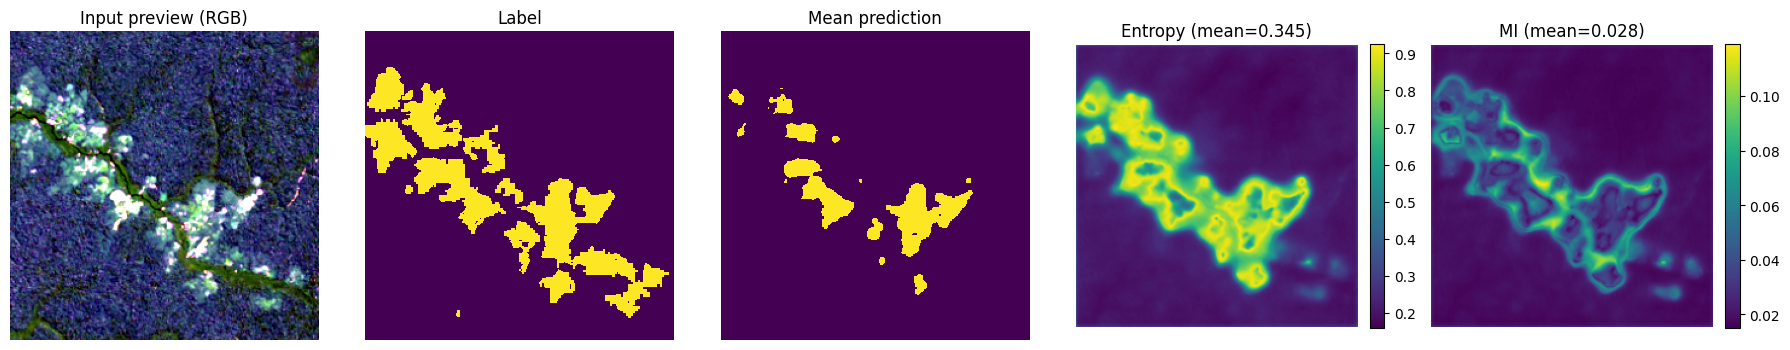

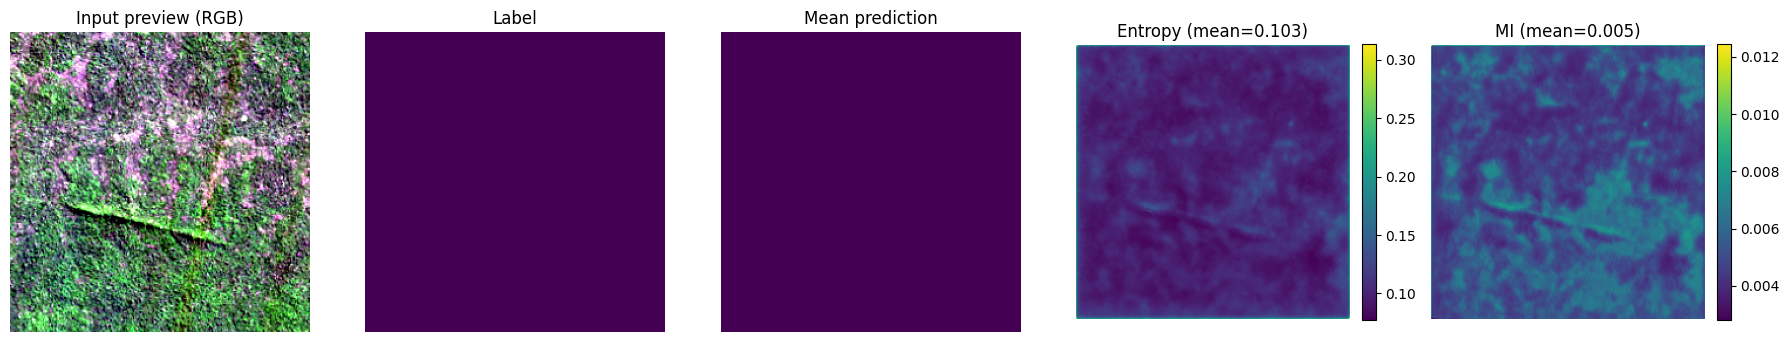

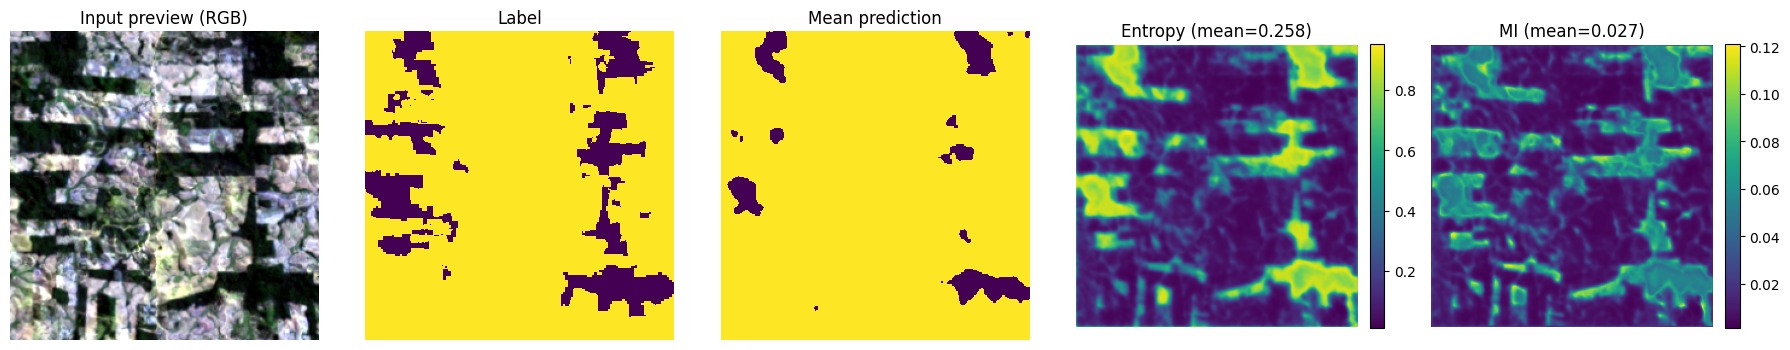

In [10]:
def enable_mc_dropout(model: nn.Module) -> None:
    """
    Enable dropout stochasticity while preventing BatchNorm from updating running stats.
    Recommended for MC Dropout at inference time.
    """
    model.train()  # turns dropout on, but also turns BN to train -> we override BN next
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
            m.eval()  # freeze BN stats

def _entropy_from_probs(probs: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    probs: [B, C, H, W]
    returns entropy: [B, H, W]
    """
    p = probs.clamp(min=eps, max=1.0)
    return -(p * torch.log(p)).sum(dim=1)

# ----------------------------
# 4.1 MC prediction core
# ----------------------------

@torch.no_grad()
def mc_predict(
    model: nn.Module,
    x: torch.Tensor,
    T: int = 10,
    num_classes: int = 3,
    device: torch.device = None,
    eps: float = 1e-12,
):
    """
    Returns:
      prob_mean: [B, C, H, W]  mean predictive probabilities
      pred_mean: [B, H, W]     argmax of prob_mean
      entropy  : [B, H, W]     predictive entropy H[ E[p(y|x,w)] ]
      mi       : [B, H, W]     mutual information = H[mean p] - mean_t H[p_t]
    """
    if device is None:
        device = next(model.parameters()).device

    x = x.to(device, non_blocking=True)

    enable_mc_dropout(model)

    probs_t = []
    ent_t = []

    for _ in range(T):
        logits = model(x)  # [B, C, H, W]
        probs = torch.softmax(logits, dim=1)  # [B, C, H, W]
        probs_t.append(probs)
        ent_t.append(_entropy_from_probs(probs, eps=eps))  # [B, H, W]

    probs_stack = torch.stack(probs_t, dim=0)     # [T, B, C, H, W]
    ent_stack   = torch.stack(ent_t,   dim=0)     # [T, B, H, W]

    prob_mean = probs_stack.mean(dim=0)           # [B, C, H, W]
    pred_mean = prob_mean.argmax(dim=1)           # [B, H, W]

    entropy = _entropy_from_probs(prob_mean, eps=eps)     # [B, H, W]
    exp_entropy = ent_stack.mean(dim=0)                   # [B, H, W]
    mi = entropy - exp_entropy                             # [B, H, W]

    return prob_mean, pred_mean, entropy, mi

# ----------------------------
# 4.2 Masking utilities (ignore_index)
# ----------------------------

def apply_ignore_mask_2d(map_bhw: torch.Tensor, y_bhw: torch.Tensor, ignore_index: int):
    """
    map_bhw: [B,H,W]
    y_bhw:   [B,H,W]
    returns float map with ignored pixels -> NaN (useful for plotting & summary stats)
    """
    m = map_bhw.clone().float()
    m[y_bhw == ignore_index] = float("nan")
    return m

def masked_mean(map_bhw: torch.Tensor) -> float:
    """
    map_bhw: float with NaNs
    """
    return float(torch.nanmean(map_bhw).item())

# ----------------------------
# 4.3 Visualise a few validation patches
# ----------------------------

def tensor_to_rgb(x_chw: torch.Tensor, rgb_idx=(0,1,2), stretch=True):
    """
    x_chw: [C,H,W] (already normalised)
    Make a quick RGB preview. Because inputs are z-scored, we optionally stretch per-patch.
    """
    x = x_chw[list(rgb_idx), :, :].detach().cpu().float()  # [3,H,W]
    rgb = x.permute(1,2,0).numpy()                         # [H,W,3]

    if stretch:
        # robust stretch using percentiles per channel
        out = np.zeros_like(rgb)
        for c in range(3):
            lo, hi = np.percentile(rgb[...,c], [2, 98])
            out[...,c] = (rgb[...,c] - lo) / (hi - lo + 1e-12)
        rgb = np.clip(out, 0, 1)
    else:
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-12)
    return rgb

def plot_mc_maps_for_patch(
    model: nn.Module,
    dataset,
    idx: int,
    T: int,
    num_classes: int,
    ignore_index: int,
    device: torch.device,
    rgb_idx=(0,1,2),
):
    x, y = dataset[idx]
    x_b = x.unsqueeze(0)  # [1,C,H,W]
    y_b = y.unsqueeze(0)  # [1,H,W]

    prob_mean, pred_mean, entropy, mi = mc_predict(
        model=model,
        x=x_b,
        T=T,
        num_classes=num_classes,
        device=device,
    )

    # mask maps
    entropy_m = apply_ignore_mask_2d(entropy.cpu(), y_b.cpu(), ignore_index=ignore_index)[0]
    mi_m      = apply_ignore_mask_2d(mi.cpu(),      y_b.cpu(), ignore_index=ignore_index)[0]

    # quick summaries
    ent_mean = masked_mean(entropy_m)
    mi_mean  = masked_mean(mi_m)

    rgb = tensor_to_rgb(x, rgb_idx=rgb_idx, stretch=True)

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(rgb)
    axes[0].set_title("Input preview (RGB)")
    axes[0].axis("off")

    axes[1].imshow(y.cpu().numpy(), interpolation="nearest")
    axes[1].set_title("Label")
    axes[1].axis("off")

    axes[2].imshow(pred_mean[0].cpu().numpy(), interpolation="nearest")
    axes[2].set_title("Mean prediction")
    axes[2].axis("off")

    im3 = axes[3].imshow(entropy_m.numpy())
    axes[3].set_title(f"Entropy (mean={ent_mean:.3f})")
    axes[3].axis("off")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    im4 = axes[4].imshow(mi_m.numpy())
    axes[4].set_title(f"MI (mean={mi_mean:.3f})")
    axes[4].axis("off")
    plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# ----------------------------
# 4.4 Run on a few validation samples
# ----------------------------

# Load best checkpoint from Step 3
ckpt = torch.load(ckpt_path, map_location=device)
model = build_unet_mcdo_explicit(drop_p=float(ckpt.get("drop_p", cfg.get("drop_p", 0.2)))).to(device)
model.load_state_dict(ckpt["model_state_dict"], strict=True)

T_mc = int(cfg.get("T_mc", 10))  # from Step 0 config
print("Loaded ckpt:", ckpt_path)
print("Using T_mc:", T_mc)

# Choose a few val indices (random or fixed)
rng = np.random.default_rng(cfg.get("seed", 42))
val_indices = rng.choice(len(val_ds), size=min(3, len(val_ds)), replace=False).tolist()
print("Val indices:", val_indices)

for i in val_indices:
    plot_mc_maps_for_patch(
        model=model,
        dataset=val_ds,
        idx=int(i),
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        rgb_idx=(0,1,2),  # R,G,B in your 6-band order
    )

## 4.5.1 Patch-level scoring function

In [11]:
@torch.no_grad()
def score_patch_uncertainty(
    model,
    dataset,
    idx: int,
    T: int,
    num_classes: int,
    ignore_index: int,
    device: torch.device,
):
    x, y = dataset[idx]
    x_b = x.unsqueeze(0)
    y_b = y.unsqueeze(0)

    prob_mean, pred_mean, entropy, mi = mc_predict(
        model=model,
        x=x_b,
        T=T,
        num_classes=num_classes,
        device=device,
    )

    # mask ignore
    entropy_m = apply_ignore_mask_2d(entropy.cpu(), y_b.cpu(), ignore_index)[0]
    mi_m      = apply_ignore_mask_2d(mi.cpu(),      y_b.cpu(), ignore_index)[0]

    # confidence
    conf = prob_mean.max(dim=1).values.cpu()
    conf_m = apply_ignore_mask_2d(conf, y_b.cpu(), ignore_index)[0]

    # accuracy (optional but useful)
    valid = (y_b != ignore_index)
    correct = (pred_mean.cpu() == y_b.cpu()) & valid
    acc = correct.sum().item() / max(valid.sum().item(), 1)

    return {
        "idx": idx,
        "entropy_mean": float(torch.nanmean(entropy_m)),
        "entropy_p95": float(torch.nanquantile(entropy_m, 0.95)),
        "mi_mean": float(torch.nanmean(mi_m)),
        "mi_p95": float(torch.nanquantile(mi_m, 0.95)),
        "conf_mean": float(torch.nanmean(conf_m)),
        "accuracy": float(acc),
    }

## 4.5.2 Score all validation patches

In [12]:
results = []

for i in range(len(val_ds)):
    scores = score_patch_uncertainty(
        model=model,
        dataset=val_ds,
        idx=i,
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
    )
    results.append(scores)

unc_df = pd.DataFrame(results)
unc_path = split_dir / "val_patch_uncertainty.csv"
unc_df.to_csv(unc_path, index=False)

print("Saved:", unc_path)
unc_df.head()

Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/val_patch_uncertainty.csv


,idx,entropy_mean,entropy_p95,mi_mean,mi_p95,conf_mean,accuracy
0,0,0.085051,0.103641,0.002555,0.003390,0.985445,1.000000
1,1,0.209260,0.229427,0.026902,0.028523,0.955609,1.000000
2,2,0.169616,0.185076,0.022981,0.025489,0.966091,1.000000
3,3,0.201191,0.231784,0.015710,0.017933,0.957968,0.999573
4,4,0.220311,0.273398,0.014281,0.018432,0.952724,1.000000


## Does uncertainty correlate with error?

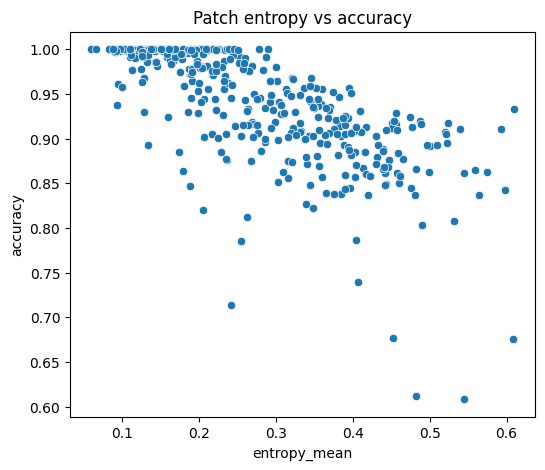

Correlation (entropy_mean vs accuracy): -0.7405632880673902


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=unc_df,
    x="entropy_mean",
    y="accuracy",
)
plt.title("Patch entropy vs accuracy")
plt.show()

print("Correlation (entropy_mean vs accuracy):",
      unc_df["entropy_mean"].corr(unc_df["accuracy"]))

# Step 5) Patch-Level Uncertainty Scoring + Dataset Audit

In [14]:
test_ds = RasterPatchDataset(
    img_path, lbl_path, test_patches,
    nodata_value=cfg["nodata_value"],
    ignore_index=cfg["ignore_index"],
    mean=train_mean, std=train_std,
    augment=False,
    seed=cfg["seed"],
)
print("Test dataset:", len(test_ds))

Test dataset: 520


Loaded: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/model_best.pt
Dropout p: 0.2
T_mc: 10
max_score_patches (active): None
Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/train_patch_scores.csv
Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/val_patch_scores.csv
Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/test_patch_scores.csv
Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/patch_scores_all.csv


,split,idx,row_off,col_off,entropy_mean,entropy_p95,mi_mean,mi_p95,conf_mean,disagree_frac,accuracy
0,train,0,8192,0,0.548481,0.926808,0.049111,0.078887,0.801309,0.083908,0.916092
1,train,1,8192,256,0.512753,0.840868,0.037579,0.070469,0.807642,0.091141,0.908859
2,train,2,8192,512,0.437261,0.858579,0.038297,0.080194,0.837554,0.093231,0.906769
3,train,3,8192,768,0.441891,0.839102,0.042743,0.091051,0.837157,0.090073,0.909927
4,train,4,8192,1024,0.511205,0.823864,0.040648,0.058668,0.803663,0.125946,0.874054


Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/top_uncertain_entropy.csv
Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/top_uncertain_mi.csv


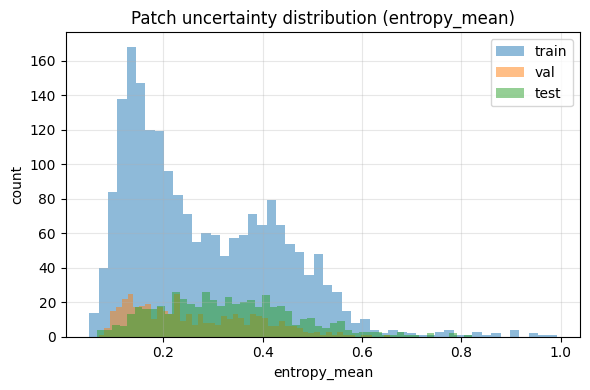

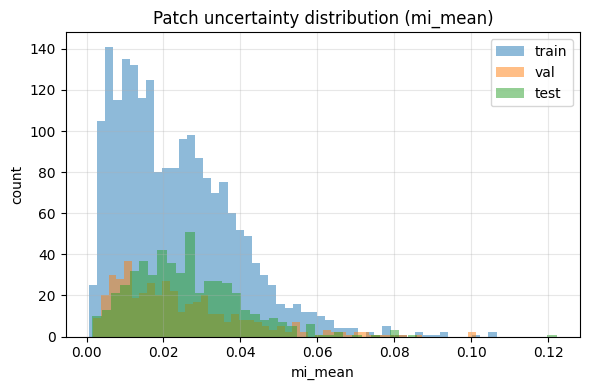

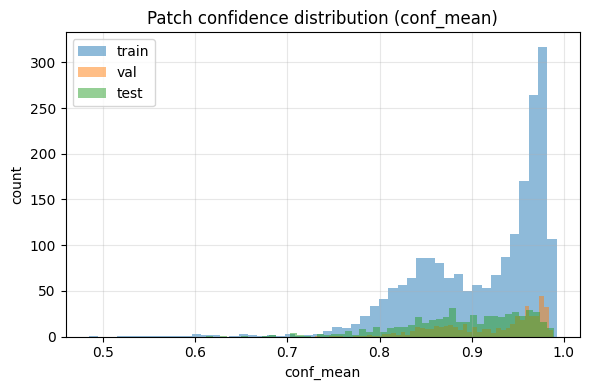

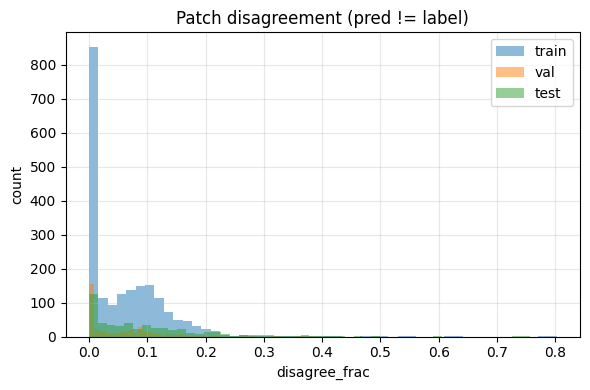

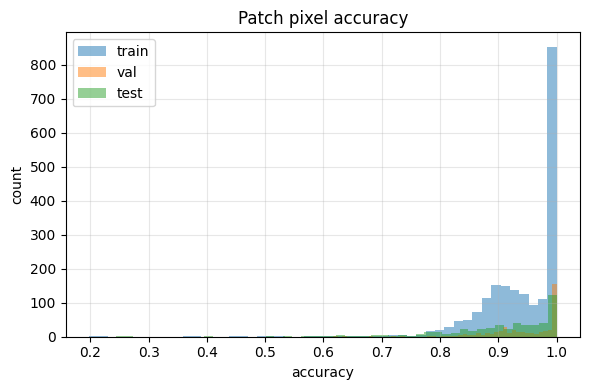

In [15]:
# ============================================================
#   - scores every patch with scalar uncertainty metrics
#   - runs for train/val/test
# Outputs:
#   - {split}_patch_scores.csv
#   - patch_scores_all.csv
#   - top_uncertain_entropy.csv
#   - top_uncertain_mi.csv
#   - histograms: entropy/mi/conf/disagree/accuracy
# ============================================================

# ---- assumes you already have from Step 4 ----
# enable_mc_dropout(model)
# mc_predict(model, x, T, num_classes, device)
# ckpt_path, build_unet_mcdo_explicit(...)
# cfg, split_dir, train_ds/val_ds/test_ds exist

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 5.0 Load best model (again, for safety)
# ----------------------------
ckpt = torch.load(ckpt_path, map_location=device)
DROP_P = float(ckpt.get("drop_p", cfg.get("drop_p", 0.2)))

model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)
model.load_state_dict(ckpt["model_state_dict"], strict=True)
model.eval()

T_mc = int(cfg.get("T_mc", 10))
print("Loaded:", ckpt_path)
print("Dropout p:", DROP_P)
print("T_mc:", T_mc)

# ----------------------------
# 5.1 Masked stats helpers (ignore_index aware)
# ----------------------------
@torch.no_grad()
def masked_mean_t(map_hw: torch.Tensor, valid_hw: torch.Tensor) -> float:
    v = map_hw[valid_hw]
    if v.numel() == 0:
        return float("nan")
    return float(v.mean().item())

@torch.no_grad()
def masked_quantile_t(map_hw: torch.Tensor, valid_hw: torch.Tensor, q: float) -> float:
    v = map_hw[valid_hw]
    if v.numel() == 0:
        return float("nan")
    # torch.quantile exists in your torch version; if not, we fall back to numpy
    try:
        return float(torch.quantile(v.float(), q).item())
    except Exception:
        vv = v.detach().cpu().numpy().astype(np.float32)
        return float(np.quantile(vv, q))

# ----------------------------
# 5.2 Scoring function for a dataset split
# ----------------------------
@torch.no_grad()
def score_split(
    split_name: str,
    dataset,
    model: torch.nn.Module,
    T: int,
    num_classes: int,
    ignore_index: int,
    device: torch.device,
    batch_size: int = 2,
    max_patches: Optional[int] = None,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Computes patch-level scalars:
      entropy_mean, entropy_p95, mi_mean, mi_p95, conf_mean,
      disagree_frac (pred != label), accuracy (pixel acc)
    Also stores patch coordinates: row_off, col_off
    """

    # deterministic subset option (useful for Phase 2 full-area)
    indices = np.arange(len(dataset))
    if max_patches is not None and max_patches < len(indices):
        rng = np.random.default_rng(seed)
        indices = rng.choice(indices, size=int(max_patches), replace=False)

    # simple subset wrapper (no extra class needed)
    def _get_item(i):
        return dataset[int(i)]

    loader = DataLoader(
        indices.tolist(),
        batch_size=batch_size,
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
        collate_fn=lambda batch: batch,  # list of indices
    )

    rows: List[Dict[str, Any]] = []

    for batch_idxs in loader:
        # batch_idxs is a list of dataset indices
        xs, ys = [], []
        for di in batch_idxs:
            x, y = _get_item(di)
            xs.append(x)
            ys.append(y)

        x_b = torch.stack(xs, dim=0).to(device, non_blocking=True)  # [B,C,H,W]
        y_b = torch.stack(ys, dim=0)                                # [B,H,W] on CPU is fine

        prob_mean, pred_mean, entropy, mi = mc_predict(
            model=model,
            x=x_b,
            T=T,
            num_classes=num_classes,
            device=device,
        )

        # confidence map (mean predictive confidence)
        conf = prob_mean.max(dim=1).values  # [B,H,W]

        # move pixel maps to CPU for scoring (small enough per batch)
        pred_cpu = pred_mean.detach().cpu()
        ent_cpu  = entropy.detach().cpu()
        mi_cpu   = mi.detach().cpu()
        conf_cpu = conf.detach().cpu()

        for bi, di in enumerate(batch_idxs):
            y = y_b[bi]  # [H,W]
            valid = (y != ignore_index)

            # patch-level uncertainty summaries
            ent_mean = masked_mean_t(ent_cpu[bi], valid)
            ent_p95  = masked_quantile_t(ent_cpu[bi], valid, 0.95)

            mi_mean  = masked_mean_t(mi_cpu[bi], valid)
            mi_p95   = masked_quantile_t(mi_cpu[bi], valid, 0.95)

            conf_mean = masked_mean_t(conf_cpu[bi], valid)

            # label-based metrics (available because you have labels)
            disagree = ((pred_cpu[bi] != y) & valid)
            correct  = ((pred_cpu[bi] == y) & valid)

            denom = int(valid.sum().item())
            disagree_frac = float(disagree.sum().item() / denom) if denom > 0 else float("nan")
            accuracy = float(correct.sum().item() / denom) if denom > 0 else float("nan")

            # patch coords (assumes your RasterPatchDataset keeps .patches like baseline)
            p = dataset.patches[int(di)]  # PatchSpec
            rows.append({
                "split": split_name,
                "idx": int(di),
                "row_off": int(p.row_off),
                "col_off": int(p.col_off),
                "entropy_mean": float(ent_mean),
                "entropy_p95": float(ent_p95),
                "mi_mean": float(mi_mean),
                "mi_p95": float(mi_p95),
                "conf_mean": float(conf_mean),
                "disagree_frac": float(disagree_frac),
                "accuracy": float(accuracy),
            })

    df = pd.DataFrame(rows).sort_values(["split", "idx"]).reset_index(drop=True)
    return df

# ----------------------------
# 5.3 Decide scoring budget (safe default for Phase 2)
# ----------------------------
# Phase 1: score everything (fast enough)
# Phase 2: you CAN score everything, but it's heavy with MC passes — so default to a cap unless you set cfg["max_score_patches"]
if cfg.get("phase") == "small":
    max_score = None
else:
    max_score = cfg.get("max_score_patches", 2000)  # you can set None to score all

print("max_score_patches (active):", max_score)

# ----------------------------
# 5.4 Run scoring for train/val/test
# ----------------------------
BATCH_SCORE = int(cfg.get("batch_size_mc", 2))  # MC dropout is heavy; keep small
seed = int(cfg.get("seed", 42))

df_train = score_split("train", train_ds, model, T_mc, cfg["num_classes"], cfg["ignore_index"],
                       device, batch_size=BATCH_SCORE, max_patches=max_score, seed=seed)
df_val   = score_split("val",   val_ds,   model, T_mc, cfg["num_classes"], cfg["ignore_index"],
                       device, batch_size=BATCH_SCORE, max_patches=max_score, seed=seed)
df_test  = score_split("test",  test_ds,  model, T_mc, cfg["num_classes"], cfg["ignore_index"],
                       device, batch_size=BATCH_SCORE, max_patches=max_score, seed=seed)

# save per-split
out_train = split_dir / "train_patch_scores.csv"
out_val   = split_dir / "val_patch_scores.csv"
out_test  = split_dir / "test_patch_scores.csv"

df_train.to_csv(out_train, index=False)
df_val.to_csv(out_val, index=False)
df_test.to_csv(out_test, index=False)

# save combined
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
out_all = split_dir / "patch_scores_all.csv"
df_all.to_csv(out_all, index=False)

print("Saved:", out_train)
print("Saved:", out_val)
print("Saved:", out_test)
print("Saved:", out_all)

display(df_all.head())

# ----------------------------
# 5.5 Top uncertain patches (CSV)
# ----------------------------
TOP_K = 25

top_ent = df_all.sort_values("entropy_mean", ascending=False).head(TOP_K)
top_mi  = df_all.sort_values("mi_mean", ascending=False).head(TOP_K)

out_top_ent = split_dir / "top_uncertain_entropy.csv"
out_top_mi  = split_dir / "top_uncertain_mi.csv"

top_ent.to_csv(out_top_ent, index=False)
top_mi.to_csv(out_top_mi, index=False)

print("Saved:", out_top_ent)
print("Saved:", out_top_mi)

# ----------------------------
# 5.6 Histograms (split-wise)
# ----------------------------
def plot_hist(df, col, title, bins=50):
    plt.figure(figsize=(6,4))
    for split in ["train","val","test"]:
        d = df[df["split"] == split][col].dropna().values
        if len(d) > 0:
            plt.hist(d, bins=bins, alpha=0.5, label=split)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_hist(df_all, "entropy_mean", "Patch uncertainty distribution (entropy_mean)")
plot_hist(df_all, "mi_mean",      "Patch uncertainty distribution (mi_mean)")
plot_hist(df_all, "conf_mean",    "Patch confidence distribution (conf_mean)")
plot_hist(df_all, "disagree_frac","Patch disagreement (pred != label)")
plot_hist(df_all, "accuracy",     "Patch pixel accuracy")

# ----------------------------
# 5.7 Small note: report block ratios (from Step 1 meta) if available
# ----------------------------
try:
    if "n_train_blocks" in meta and "n_val_blocks" in meta and "n_test_blocks" in meta:
        total_blocks = meta["n_train_blocks"] + meta["n_val_blocks"] + meta["n_test_blocks"]
        print("\nBlock ratios (train/val/test):")
        print(f"{meta['n_train_blocks']}/{total_blocks} = {meta['n_train_blocks']/total_blocks:.3f}")
        print(f"{meta['n_val_blocks']}/{total_blocks} = {meta['n_val_blocks']/total_blocks:.3f}")
        print(f"{meta['n_test_blocks']}/{total_blocks} = {meta['n_test_blocks']/total_blocks:.3f}")
except Exception:
    pass

# Step 6A — Filtering experiment (uncertainty removal vs random)

In [16]:
# ============================================================
# Uses: patch_scores_all.csv from Step 5
# Output: filter_experiment_summary.csv + printed table
# ============================================================

split_dir = Path(split_dir)
scores_path = split_dir / "patch_scores_all.csv"
assert scores_path.exists(), f"Missing: {scores_path}"

df = pd.read_csv(scores_path)

# ---- config ----
REMOVE_FRAC = 0.10              # 10% removal
N_RANDOM_RUNS = 5               # random repeats
RANDOM_SEEDS = [10, 20, 30, 40, 50]  # or list(range(N_RANDOM_RUNS))
METRICS = ["accuracy", "disagree_frac"]  # both are already in your table

# sanity checks
for c in ["split", "idx", "entropy_mean", "mi_mean", "accuracy", "disagree_frac"]:
    assert c in df.columns, f"Missing column: {c}"

# drop NaNs (should be rare; keeps experiment clean)
df = df.dropna(subset=["entropy_mean", "mi_mean", "accuracy", "disagree_frac"]).copy()

def _k_from_frac(n: int, frac: float) -> int:
    return max(1, int(np.ceil(frac * n)))

def _summary_stats(d: pd.DataFrame) -> dict:
    return {
        "n_patches": int(len(d)),
        "mean_accuracy": float(d["accuracy"].mean()),
        "mean_disagree": float(d["disagree_frac"].mean()),
    }

def run_strategy(d: pd.DataFrame, strategy: str, remove_frac: float, seed: int = 42) -> dict:
    """
    Returns stats AFTER removing k patches according to strategy.
    strategy in {"none", "top_entropy", "top_mi", "random"}
    """
    n = len(d)
    if strategy == "none":
        kept = d
        out = _summary_stats(kept)
        out.update({"strategy": "none", "remove_frac": 0.0, "k_removed": 0, "seed": None})
        return out

    k = _k_from_frac(n, remove_frac)

    if strategy == "top_entropy":
        kept = d.nsmallest(n - k, "entropy_mean")  # keep lowest entropy
    elif strategy == "top_mi":
        kept = d.nsmallest(n - k, "mi_mean")       # keep lowest MI
    elif strategy == "random":
        kept = d.sample(n=n - k, replace=False, random_state=int(seed))
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    out = _summary_stats(kept)
    out.update({"strategy": strategy, "remove_frac": float(remove_frac), "k_removed": int(k), "seed": int(seed) if strategy=="random" else None})
    return out

rows = []

for split_name in ["train", "val", "test"]:
    d = df[df["split"] == split_name].copy()
    if len(d) == 0:
        continue

    # baseline (no removal)
    base = run_strategy(d, "none", REMOVE_FRAC)
    base["split"] = split_name
    rows.append(base)

    # top entropy removal
    te = run_strategy(d, "top_entropy", REMOVE_FRAC)
    te["split"] = split_name
    rows.append(te)

    # top MI removal
    tm = run_strategy(d, "top_mi", REMOVE_FRAC)
    tm["split"] = split_name
    rows.append(tm)

    # random removal (multiple seeds)
    for s in RANDOM_SEEDS[:N_RANDOM_RUNS]:
        rr = run_strategy(d, "random", REMOVE_FRAC, seed=s)
        rr["split"] = split_name
        rows.append(rr)

df_runs = pd.DataFrame(rows)

# Aggregate random runs to mean±std (for each split)
def mean_std_fmt(x: pd.Series) -> str:
    return f"{x.mean():.4f} ± {x.std(ddof=1):.4f}" if len(x) > 1 else f"{x.mean():.4f}"

agg_rows = []
for split_name in df_runs["split"].unique():
    sub = df_runs[df_runs["split"] == split_name]

    # baseline / top_entropy / top_mi are single rows
    for st in ["none", "top_entropy", "top_mi"]:
        r = sub[sub["strategy"] == st].iloc[0].to_dict()
        r["mean_accuracy_fmt"] = f"{r['mean_accuracy']:.4f}"
        r["mean_disagree_fmt"] = f"{r['mean_disagree']:.4f}"
        agg_rows.append(r)

    # random: aggregate
    rnd = sub[sub["strategy"] == "random"]
    if len(rnd) > 0:
        r = {
            "split": split_name,
            "strategy": "random",
            "remove_frac": float(REMOVE_FRAC),
            "k_removed": int(rnd["k_removed"].iloc[0]),
            "n_patches": int(rnd["n_patches"].iloc[0]),
            "mean_accuracy": float(rnd["mean_accuracy"].mean()),
            "mean_disagree": float(rnd["mean_disagree"].mean()),
            "mean_accuracy_fmt": mean_std_fmt(rnd["mean_accuracy"]),
            "mean_disagree_fmt": mean_std_fmt(rnd["mean_disagree"]),
            "seed": None,
        }
        agg_rows.append(r)

df_summary = pd.DataFrame(agg_rows)[
    ["split", "strategy", "remove_frac", "k_removed", "n_patches",
     "mean_accuracy_fmt", "mean_disagree_fmt",
     "mean_accuracy", "mean_disagree"]
].sort_values(["split", "strategy"]).reset_index(drop=True)

# compute deltas vs baseline per split (nice for thesis tables)
out = []
for split_name in df_summary["split"].unique():
    s = df_summary[df_summary["split"] == split_name].copy()
    base_acc = float(s[s["strategy"] == "none"]["mean_accuracy"].iloc[0])
    base_dis = float(s[s["strategy"] == "none"]["mean_disagree"].iloc[0])
    s["delta_acc_vs_none"] = s["mean_accuracy"] - base_acc
    s["delta_disagree_vs_none"] = s["mean_disagree"] - base_dis
    out.append(s)
df_summary = pd.concat(out, ignore_index=True)

# save
out_path = split_dir / "filter_experiment_summary.csv"
df_summary.to_csv(out_path, index=False)

print("Saved:", out_path)
display(df_summary[[
    "split", "strategy", "remove_frac", "k_removed",
    "mean_accuracy_fmt", "delta_acc_vs_none",
    "mean_disagree_fmt", "delta_disagree_vs_none"
]])

Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/filter_experiment_summary.csv


,split,strategy,remove_frac,k_removed,mean_accuracy_fmt,delta_acc_vs_none,mean_disagree_fmt,delta_disagree_vs_none
0,test,none,0.0,0,0.8985,0.000000,0.1015,0.000000
1,test,random,0.1,52,0.8986 ± 0.0018,0.000153,0.1014 ± 0.0018,-0.000153
2,test,top_entropy,0.1,52,0.9173,0.018839,0.0827,-0.018839
3,test,top_mi,0.1,52,0.9048,0.006295,0.0952,-0.006295
4,train,none,0.0,0,0.9391,0.000000,0.0609,0.000000
5,train,random,0.1,202,0.9392 ± 0.0007,0.000148,0.0608 ± 0.0007,-0.000148
6,train,top_entropy,0.1,202,0.9508,0.011708,0.0492,-0.011708
7,train,top_mi,0.1,202,0.9465,0.007470,0.0535,-0.007470
8,val,none,0.0,0,0.9449,0.000000,0.0551,0.000000
9,val,random,0.1,44,0.9448 ± 0.0004,-0.000163,0.0552 ± 0.0004,0.000163


# Step 6B: Calibration (ECE + Reliability Diagram)

Loaded: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/model_best.pt
Dropout p: 0.2
T_mc: 10
n_bins: 15
max_cal_patches: None

=== ECE results ===
VAL  ECE: 0.0240  (valid pixels: 28311552)
TEST ECE: 0.0153 (valid pixels: 34078720)
Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/calibration_bins_val.csv
Saved: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/calibration_bins_test.csv


,split,bin,bin_lo,bin_hi,bin_center,count,avg_conf,avg_acc
0,val,0,0.000000,0.066667,0.033333,0,NaN,NaN
1,val,1,0.066667,0.133333,0.100000,0,NaN,NaN
2,val,2,0.133333,0.200000,0.166667,0,NaN,NaN
3,val,3,0.200000,0.266667,0.233333,0,NaN,NaN
4,val,4,0.266667,0.333333,0.300000,0,NaN,NaN


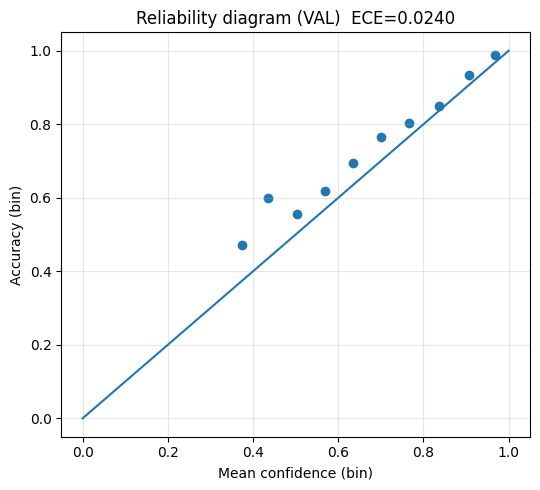

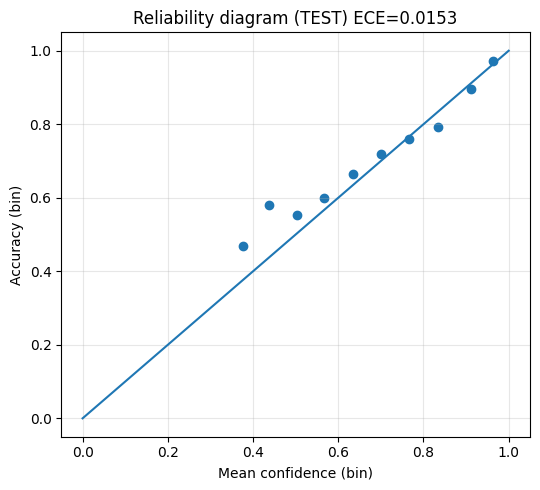

In [17]:
# ============================================================
#   Uses MC Dropout mean predictive probabilities (prob_mean)
#
# Outputs:
#   - calibration_bins_val.csv
#   - calibration_bins_test.csv
#   - reliability diagram plots (val/test)
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from typing import Optional, Dict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- assumes you already have from Step 4 ----
# mc_predict(model, x, T, num_classes, device) -> prob_mean, pred_mean, entropy, mi
# and from Step 3: ckpt_path, build_unet_mcdo_explicit(...)
# and from Step 3: val_ds, test_ds exist

# ----------------------------
# 6B.0 Load best model
# ----------------------------
ckpt = torch.load(ckpt_path, map_location=device)
DROP_P = float(ckpt.get("drop_p", cfg.get("drop_p", 0.2)))

model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)
model.load_state_dict(ckpt["model_state_dict"], strict=True)
model.eval()

T_mc = int(cfg.get("T_mc", 10))
print("Loaded:", ckpt_path)
print("Dropout p:", DROP_P)
print("T_mc:", T_mc)

# ----------------------------
# 6B.1 Calibration utilities
# ----------------------------
@torch.no_grad()
def compute_calibration_bins(
    model: torch.nn.Module,
    dataset,
    split_name: str,
    T: int,
    num_classes: int,
    ignore_index: int,
    device: torch.device,
    n_bins: int = 15,
    batch_size: int = 2,
    max_patches: Optional[int] = None,
    seed: int = 42,
) -> Dict[str, object]:
    """
    Computes ECE and reliability bins using pixel-level confidence and correctness.

    Confidence: max(prob_mean) per pixel
    Correctness: pred_mean == y per pixel

    Uses only valid pixels (y != ignore_index).

    Returns dict with:
      - df_bins: DataFrame of bins
      - ece: float
      - n_valid: int
    """

    # optional deterministic subset (useful in Phase 2 if needed)
    indices = np.arange(len(dataset))
    if max_patches is not None and max_patches < len(indices):
        rng = np.random.default_rng(seed)
        indices = rng.choice(indices, size=int(max_patches), replace=False)

    # bin edges in [0,1]
    bin_edges = torch.linspace(0.0, 1.0, steps=n_bins + 1)
    bin_lower = bin_edges[:-1]
    bin_upper = bin_edges[1:]

    # accumulators
    bin_count = torch.zeros(n_bins, dtype=torch.long)
    bin_conf_sum = torch.zeros(n_bins, dtype=torch.float64)
    bin_acc_sum = torch.zeros(n_bins, dtype=torch.float64)

    # simple loader over indices (similar to your scoring approach)
    loader = torch.utils.data.DataLoader(
        indices.tolist(),
        batch_size=batch_size,
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
        collate_fn=lambda batch: batch,  # list of indices
    )

    n_valid_total = 0

    for batch_idxs in loader:
        xs, ys = [], []
        for di in batch_idxs:
            x, y = dataset[int(di)]
            xs.append(x)
            ys.append(y)

        x_b = torch.stack(xs, dim=0).to(device, non_blocking=True)  # [B,C,H,W]
        y_b = torch.stack(ys, dim=0)                                # [B,H,W] (CPU)

        prob_mean, pred_mean, _, _ = mc_predict(
            model=model,
            x=x_b,
            T=T,
            num_classes=num_classes,
            device=device,
        )

        # confidence + correctness on CPU for binning
        conf = prob_mean.max(dim=1).values.detach().cpu()          # [B,H,W] in [0,1]
        pred = pred_mean.detach().cpu()                            # [B,H,W]
        y    = y_b                                                 # [B,H,W]

        valid = (y != ignore_index)
        if valid.sum().item() == 0:
            continue

        conf_v = conf[valid].flatten()                             # [N]
        corr_v = (pred[valid] == y[valid]).to(torch.float32)       # [N]
        n_valid_total += int(conf_v.numel())

        # binning
        # include right edge in last bin
        for b in range(n_bins):
            lo = bin_lower[b].item()
            hi = bin_upper[b].item()
            if b == n_bins - 1:
                m = (conf_v >= lo) & (conf_v <= hi)
            else:
                m = (conf_v >= lo) & (conf_v < hi)

            cnt = int(m.sum().item())
            if cnt == 0:
                continue

            bin_count[b] += cnt
            bin_conf_sum[b] += float(conf_v[m].sum().item())
            bin_acc_sum[b] += float(corr_v[m].sum().item())

    # compute per-bin averages
    bin_count_f = bin_count.to(torch.float64)
    avg_conf = torch.where(bin_count_f > 0, bin_conf_sum / bin_count_f, torch.nan)
    avg_acc  = torch.where(bin_count_f > 0, bin_acc_sum  / bin_count_f, torch.nan)

    # ECE = sum_b (|acc_b - conf_b| * (count_b / total))
    total = max(n_valid_total, 1)
    weights = bin_count_f / float(total)
    ece = torch.nansum(torch.abs(avg_acc - avg_conf) * weights).item()

    # bin centres for plotting
    bin_centres = ((bin_lower + bin_upper) / 2.0).numpy()
    df_bins = pd.DataFrame({
        "split": split_name,
        "bin": np.arange(n_bins),
        "bin_lo": bin_lower.numpy(),
        "bin_hi": bin_upper.numpy(),
        "bin_center": bin_centres,
        "count": bin_count.numpy(),
        "avg_conf": avg_conf.numpy(),
        "avg_acc": avg_acc.numpy(),
    })

    return {"df_bins": df_bins, "ece": float(ece), "n_valid": int(n_valid_total)}

def plot_reliability(df_bins: pd.DataFrame, title: str):
    # keep only non-empty bins
    d = df_bins[df_bins["count"] > 0].copy()
    x = d["avg_conf"].to_numpy()
    y = d["avg_acc"].to_numpy()

    plt.figure(figsize=(5.5, 5))
    plt.plot([0, 1], [0, 1])  # perfectly calibrated
    plt.scatter(x, y)
    plt.xlabel("Mean confidence (bin)")
    plt.ylabel("Accuracy (bin)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6B.2 Run for val + test
# ----------------------------
N_BINS = int(cfg.get("ece_bins", 15))
BATCH_CAL = int(cfg.get("batch_size_mc", 2))  # keep small; MC is heavy

# Phase 2 safety cap (optional)
if cfg.get("phase") == "small":
    max_cal_patches = None
else:
    max_cal_patches = cfg.get("max_cal_patches", None)  # set e.g. 2000 if you want

print("n_bins:", N_BINS)
print("max_cal_patches:", max_cal_patches)

res_val = compute_calibration_bins(
    model=model,
    dataset=val_ds,
    split_name="val",
    T=T_mc,
    num_classes=cfg["num_classes"],
    ignore_index=cfg["ignore_index"],
    device=device,
    n_bins=N_BINS,
    batch_size=BATCH_CAL,
    max_patches=max_cal_patches,
    seed=int(cfg.get("seed", 42)),
)
res_test = compute_calibration_bins(
    model=model,
    dataset=test_ds,
    split_name="test",
    T=T_mc,
    num_classes=cfg["num_classes"],
    ignore_index=cfg["ignore_index"],
    device=device,
    n_bins=N_BINS,
    batch_size=BATCH_CAL,
    max_patches=max_cal_patches,
    seed=int(cfg.get("seed", 42)),
)

df_val_bins = res_val["df_bins"]
df_test_bins = res_test["df_bins"]

# ----------------------------
# 6B.3 Save bins
# ----------------------------
out_val = Path(split_dir) / "calibration_bins_val.csv"
out_test = Path(split_dir) / "calibration_bins_test.csv"
df_val_bins.to_csv(out_val, index=False)
df_test_bins.to_csv(out_test, index=False)

print("\n=== ECE results ===")
print(f"VAL  ECE: {res_val['ece']:.4f}  (valid pixels: {res_val['n_valid']})")
print(f"TEST ECE: {res_test['ece']:.4f} (valid pixels: {res_test['n_valid']})")
print("Saved:", out_val)
print("Saved:", out_test)

display(df_val_bins.head())

# ----------------------------
# 6B.4 Reliability plots
# ----------------------------
plot_reliability(df_val_bins,  title=f"Reliability diagram (VAL)  ECE={res_val['ece']:.4f}")
plot_reliability(df_test_bins, title=f"Reliability diagram (TEST) ECE={res_test['ece']:.4f}")

# Cell 26.5 — Load train scores + filter helper

In [18]:
# =========================
# (NEW: needed for filter strategies)
# =========================

scores_train_path = Path(split_dir) / "train_patch_scores.csv"
scores_train = pd.read_csv(scores_train_path)
assert {"idx", "entropy_mean"}.issubset(scores_train.columns), "train_patch_scores.csv must have idx + entropy_mean"
scores_train["idx"] = scores_train["idx"].astype(int)

print("Loaded train scores:", scores_train_path, "| rows:", len(scores_train))

def make_filter_keep_indices(df_scores: pd.DataFrame, remove_frac: float):
    """
    Remove top remove_frac by entropy_mean (train only).
    Returns:
      keep_idxs: np.ndarray[int] indices to KEEP (matching full_train_ds indices)
      k_removed: int
    """
    df = df_scores[["idx", "entropy_mean"]].copy()
    n = len(df)
    k = int(np.floor(remove_frac * n))
    if k <= 0:
        return df["idx"].to_numpy().astype(int), 0

    order = df["entropy_mean"].to_numpy().argsort()[::-1]  # high -> low
    remove = set(df.iloc[order[:k]]["idx"].tolist())
    keep = df.loc[~df["idx"].isin(remove), "idx"].to_numpy()
    return keep.astype(int), int(k)

Loaded train scores: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/train_patch_scores.csv | rows: 2012


# Step 7 — run_one_strategy (RESTORE)

In [19]:
# =========================
# Step 7–8 shared: seeds + deterministic runs + dispatcher
# =========================

from pathlib import Path
import shutil, time, json, random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, Subset
import torch.nn as nn
import torch.optim as optim

# --- choose 10 seeds ---
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

split_dir = Path(split_dir)

def seed_everything(seed: int):
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def run_one_seed_for_strategy(seed_run: int, strategy: dict) -> dict:
    """
    Deterministic run per seed + dispatch to runner.
    """
    seed_run = int(seed_run)
    seed_everything(seed_run)
    cfg["seed"] = seed_run  # important: your datasets depend on cfg["seed"]

    # Dispatch by "mode"
    mode = strategy.get("mode", "filtering")  # "filtering" or "weighting"
    if mode == "filtering":
        res = run_one_strategy_filter(strategy)
    elif mode == "weighting":
        res = run_one_strategy_weight(strategy)
    else:
        raise ValueError(f"Unknown strategy mode: {mode}")

    res["seed"] = seed_run
    return res

In [20]:
def run_one_seed_for_strategy(seed_run: int, strategy: Dict[str, Any]) -> Dict[str, Any]:
    """
    Sets deterministic seed for this run, then dispatches to:
      - run_one_strategy(...) for baseline/filter experiments (Step 7)
      - run_one_strategy_weight(...) for baseline/weight experiments (Step 8)
    Returns the summary dict from the underlying runner, plus 'seed' field.
    """
    seed_run = int(seed_run)

    # 1) Make RNG deterministic for this run
    seed_everything(seed_run)

    # 2) Ensure cfg also reflects the seed (important: your datasets use cfg["seed"])
    cfg["seed"] = seed_run

    # 3) Dispatch to the correct runner
    if strategy["type"] in {"baseline", "filter"} and "remove_frac" in strategy or strategy["type"] == "filter":
        res = run_one_strategy(strategy)
    elif strategy["type"] in {"baseline", "weight"} and ("w_min" in strategy or strategy["type"] == "weight"):
        res = run_one_strategy_weight(strategy)
    else:
        # Fallback: choose based on type only
        if strategy["type"] in {"baseline", "filter"}:
            res = run_one_strategy(strategy)
        elif strategy["type"] in {"baseline", "weight"}:
            res = run_one_strategy_weight(strategy)
        else:
            raise ValueError(f"Unknown strategy type: {strategy['type']}")

    # 4) Standardise output seed field (your runners sometimes store cfg seed)
    res["seed"] = seed_run
    return res

## Step 7B.1 — Recreate Case 4 thresholds and mark train patches

In [21]:
# ============================================================
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# Load full patch score table
scores_all_path = Path(split_dir) / "patch_scores_all.csv"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

scores_all = pd.read_csv(scores_all_path).dropna(
    subset=["entropy_mean", "disagree_frac", "accuracy"]
).copy()

# Recreate thresholds exactly as in the thresholds notebook:
# thresholds are derived from the VAL split only
df_audit_pool_case4 = (
    scores_all[scores_all["split"] == "val"]
    .dropna(subset=["entropy_mean", "disagree_frac"])
    .copy()
    .reset_index(drop=True)
)

entropy_threshold_q60_case4 = df_audit_pool_case4["entropy_mean"].quantile(0.60)
disagreement_threshold_q75_case4 = df_audit_pool_case4["disagree_frac"].quantile(0.75)

print("Case 4 thresholds recreated from VAL split")
print("entropy_threshold_q60_case4       :", round(float(entropy_threshold_q60_case4), 6))
print("disagreement_threshold_q75_case4  :", round(float(disagreement_threshold_q75_case4), 6))

def assign_case_from_thresholds(row, entropy_thr, disagree_thr):
    high_entropy = row["entropy_mean"] >= entropy_thr
    high_disagreement = row["disagree_frac"] >= disagree_thr

    if (not high_entropy) and (not high_disagreement):
        return "case_1_low_entropy_agree"
    elif high_entropy and (not high_disagreement):
        return "case_2_high_entropy_agree"
    elif (not high_entropy) and high_disagreement:
        return "case_3_low_entropy_disagree"
    else:
        return "case_4_high_entropy_disagree"

scores_all["audit_case"] = scores_all.apply(
    assign_case_from_thresholds,
    axis=1,
    entropy_thr=entropy_threshold_q60_case4,
    disagree_thr=disagreement_threshold_q75_case4,
)

# Restrict to TRAIN split because filtering must only affect training patches
scores_train_case4 = (
    scores_all[scores_all["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

case4_train = scores_train_case4[
    scores_train_case4["audit_case"] == "case_4_high_entropy_disagree"
].copy()

print("\nTrain split size:", len(scores_train_case4))
print("Train Case 4 candidates:", len(case4_train))

display(
    case4_train[[
        "idx", "row_off", "col_off", "entropy_mean", "disagree_frac", "accuracy", "audit_case"
    ]]
    .sort_values(["entropy_mean", "disagree_frac"], ascending=[False, False])
    .head(20)
)

Case 4 thresholds recreated from VAL split
entropy_threshold_q60_case4       : 0.279863
disagreement_threshold_q75_case4  : 0.091267

Train split size: 2012
Train Case 4 candidates: 546


,idx,row_off,col_off,entropy_mean,disagree_frac,accuracy,audit_case
1670,1670,512,1536,0.992082,0.181183,0.818817,case_4_high_entropy_disagree
1671,1671,512,1792,0.956828,0.343323,0.656677,case_4_high_entropy_disagree
1673,1673,768,256,0.947576,0.139572,0.860428,case_4_high_entropy_disagree
1680,1680,1024,0,0.912521,0.250336,0.749664,case_4_high_entropy_disagree
1696,1696,1536,0,0.910172,0.131042,0.868958,case_4_high_entropy_disagree
1681,1681,1024,256,0.877914,0.536896,0.463104,case_4_high_entropy_disagree
1755,1755,1280,6912,0.862753,0.126846,0.873154,case_4_high_entropy_disagree
1678,1678,768,1536,0.853798,0.140579,0.859421,case_4_high_entropy_disagree
1763,1763,1536,6912,0.835285,0.118210,0.881790,case_4_high_entropy_disagree
1651,1651,0,768,0.832868,0.469604,0.530396,case_4_high_entropy_disagree


## Step 7B.2 — Case 4-only filtering helper

In [22]:
# ============================================================
# ============================================================

def make_filter_keep_indices_case4_only(
    df_scores_train: pd.DataFrame,
    remove_frac: float,
    entropy_thr: float,
    disagree_thr: float,
):
    """
    Remove up to k = floor(remove_frac * total_train_patches), but ONLY from train
    patches that fall in Case 4 under the thresholds notebook definition.

    Ranking inside Case 4:
      highest entropy first, then highest disagreement

    Returns:
      keep_idxs: np.ndarray[int]
      k_removed: int              # actual removed
      n_case4_available: int
    """
    df = df_scores_train.copy()

    # Case 4 mask
    case4_mask = (
        (df["entropy_mean"] >= float(entropy_thr)) &
        (df["disagree_frac"] >= float(disagree_thr))
    )

    df_case4 = df.loc[case4_mask].copy()

    n_total = len(df)
    n_case4_available = len(df_case4)

    k_target = int(np.floor(float(remove_frac) * n_total))
    if k_target <= 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_case4_available)

    # only remove from Case 4, capped by available count
    k_remove = min(k_target, n_case4_available)

    if k_remove == 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_case4_available)

    # rank within Case 4: highest entropy, then highest disagreement
    df_case4 = df_case4.sort_values(
        ["entropy_mean", "disagree_frac"],
        ascending=[False, False]
    )

    remove_ids = set(df_case4.head(k_remove)["idx"].astype(int).tolist())
    keep = df.loc[~df["idx"].isin(remove_ids), "idx"].to_numpy().astype(int)

    return keep, int(k_remove), int(n_case4_available)

## Step 7B.3 — Baseline + Case 4-only filtering runner

In [23]:
# ============================================================
# ============================================================

import json
import time
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

def run_one_strategy_filter_case4_only(strategy: dict) -> dict:
    """
    strategy["type"] in {"baseline", "filter_case4"}
    """
    assert strategy["type"] in {"baseline", "filter_case4"}

    run_dir = Path(runs_root_case4) / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_final_out = run_dir / "model_final.pt"
    ckpt_best_out  = run_dir / "model_best.pt"
    hist_out = run_dir / "train_history.csv"
    eval_out = run_dir / "eval_summary.json"
    bins_val_out = run_dir / "calibration_bins_val.csv"
    bins_test_out = run_dir / "calibration_bins_test.csv"

    # ---- build full train ds (with augmentation) ----
    full_train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=True,
        aug_prob=float(TRAIN_PARAMS.get("aug_prob", 0.0)),
        noise_std=float(TRAIN_PARAMS.get("noise_std", 0.0)),
        seed=int(cfg.get("seed", 42)),
    )

    # ---- apply Case 4-only filtering on TRAIN ----
    removed = 0
    n_case4_available = 0

    if strategy["type"] == "filter_case4":
        remove_frac = float(strategy["remove_frac"])

        keep_idxs, removed, n_case4_available = make_filter_keep_indices_case4_only(
            df_scores_train=scores_train_case4,
            remove_frac=remove_frac,
            entropy_thr=entropy_threshold_q60_case4,
            disagree_thr=disagreement_threshold_q75_case4,
        )
        train_ds2 = Subset(full_train_ds, keep_idxs.tolist())
    else:
        train_ds2 = full_train_ds

    # ---- val/test unchanged ----
    val_ds2 = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )
    test_ds2 = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    train_loader = DataLoader(
        train_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=True,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )
    val_loader = DataLoader(
        val_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )
    test_loader = DataLoader(
        test_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    # ---- model / optimiser / loss ----
    DROP_P = float(cfg.get("drop_p", 0.2))
    model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(TRAIN_PARAMS["lr"]),
        weight_decay=float(TRAIN_PARAMS["weight_decay"]),
    )

    criterion = nn.CrossEntropyLoss(ignore_index=cfg["ignore_index"], weight=weights_t)

    # ---- fixed epochs + best checkpoint ----
    max_epochs = 10
    history = []
    t0 = time.time()

    best_val_miou = -1.0
    best_epoch = -1

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_miou = eval_macro_iou(model, val_loader, cfg["num_classes"], cfg["ignore_index"], device)

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_macro_iou": float(val_miou),
        })

        print(f"[{strategy['name']}] Epoch {epoch:02d}/{max_epochs} | loss={train_loss:.4f} | val_mIoU={val_miou:.4f}")

        improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
        if improved:
            best_val_miou = float(val_miou)
            best_epoch = int(epoch)

            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "train_params": TRAIN_PARAMS,
                "strategy": strategy,
                "drop_p": DROP_P,
                "best_epoch": best_epoch,
                "best_val_miou": best_val_miou,
                "train_mean": train_mean,
                "train_std": train_std,
            }, ckpt_best_out)

    train_time = time.time() - t0
    pd.DataFrame(history).to_csv(hist_out, index=False)

    # final model
    torch.save({
        "model_state_dict": model.state_dict(),
        "cfg": cfg,
        "train_params": TRAIN_PARAMS,
        "strategy": strategy,
        "drop_p": DROP_P,
        "final_epoch": int(max_epochs),
        "train_mean": train_mean,
        "train_std": train_std,
    }, ckpt_final_out)

    # ---- load best checkpoint for eval ----
    ckpt_best = torch.load(ckpt_best_out, map_location=device)
    model = build_unet_mcdo_explicit(drop_p=float(ckpt_best.get("drop_p", DROP_P))).to(device)
    model.load_state_dict(ckpt_best["model_state_dict"], strict=True)
    model.eval()

    # ---- test mIoU ----
    test_miou = eval_macro_iou(model, test_loader, cfg["num_classes"], cfg["ignore_index"], device)

    # ---- calibration on val/test ----
    T_mc = int(cfg.get("T_mc", 10))
    n_bins = int(cfg.get("ece_bins", 15))
    batch_cal = int(cfg.get("batch_size_mc", 2))
    max_cal = None if cfg.get("phase") == "small" else cfg.get("max_cal_patches", None)

    res_val = compute_calibration_bins(
        model=model, dataset=val_ds2, split_name="val",
        T=T_mc, num_classes=cfg["num_classes"], ignore_index=cfg["ignore_index"], device=device,
        n_bins=n_bins, batch_size=batch_cal, max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )
    res_test = compute_calibration_bins(
        model=model, dataset=test_ds2, split_name="test",
        T=T_mc, num_classes=cfg["num_classes"], ignore_index=cfg["ignore_index"], device=device,
        n_bins=n_bins, batch_size=batch_cal, max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_val["df_bins"].to_csv(bins_val_out, index=False)
    res_test["df_bins"].to_csv(bins_test_out, index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "seed": int(cfg.get("seed", 42)),
        "remove_frac": float(strategy.get("remove_frac", 0.0)),
        "n_train_patches_used": int(len(train_ds2)),
        "removed_train_patches": int(removed),
        "n_case4_available": int(n_case4_available),
        "final_epoch": int(max_epochs),
        "best_epoch": int(best_epoch),
        "best_val_miou": float(best_val_miou),
        "test_miou": float(test_miou),
        "val_ece": float(res_val["ece"]),
        "test_ece": float(res_test["ece"]),
        "ece_bins": int(n_bins),
        "T_mc": int(T_mc),
        "train_time_sec": float(train_time),
        "case4_entropy_thr": float(entropy_threshold_q60_case4),
        "case4_disagree_thr": float(disagreement_threshold_q75_case4),
        "paths": {
            "run_dir": str(run_dir),
            "model_best": str(ckpt_best_out),
            "model_final": str(ckpt_final_out),
            "history": str(hist_out),
            "calib_val": str(bins_val_out),
            "calib_test": str(bins_test_out),
        },
    }

    with open(eval_out, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] Saved run artefacts -> {run_dir}")
    return summary

## Step 7B.4 — Execute baseline + Case 4-only filtering across 10 seeds

In [24]:
# ============================================================
# ============================================================

from pathlib import Path
import shutil

# same 10 seeds as existing multi-seed experiment
SEEDS_CASE4 = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

runs_root_case4 = split_dir / "step7_case4_only_filters_10seeds"
if runs_root_case4.exists():
    shutil.rmtree(runs_root_case4)
runs_root_case4.mkdir(parents=True, exist_ok=True)

print("Runs root:", runs_root_case4)

EXPERIMENTS_CASE4 = [
    {"key": "baseline",       "type": "baseline",     "remove_frac": None},
    {"key": "case4_filter_1", "type": "filter_case4", "remove_frac": 0.01},
    {"key": "case4_filter_2", "type": "filter_case4", "remove_frac": 0.02},
    {"key": "case4_filter_3", "type": "filter_case4", "remove_frac": 0.03},
]

all_rows_case4 = []

for exp in EXPERIMENTS_CASE4:
    for s in SEEDS_CASE4:
        seed_everything(s)
        cfg["seed"] = int(s)

        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "filter_case4",
                "remove_frac": float(exp["remove_frac"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_filter_case4_only(strat)
        res["exp_key"] = exp["key"]
        res["remove_frac"] = float(exp["remove_frac"]) if exp["remove_frac"] is not None else 0.0
        all_rows_case4.append(res)

df_case4_runs = pd.DataFrame(all_rows_case4)

out_csv_case4 = runs_root_case4 / "step7_case4_only_filters_10seeds.csv"
df_case4_runs.to_csv(out_csv_case4, index=False)

print("Saved raw runs:", out_csv_case4)

display(df_case4_runs[[
    "exp_key", "remove_frac", "seed",
    "best_epoch", "best_val_miou", "val_ece",
    "test_miou", "test_ece",
    "train_time_sec", "n_train_patches_used",
    "removed_train_patches", "n_case4_available"
]])

Runs root: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step7_case4_only_filters_10seeds

Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] Epoch 01/10 | loss=0.7825 | val_mIoU=0.7107
[baseline_seed_42] Epoch 02/10 | loss=0.5466 | val_mIoU=0.7394
[baseline_seed_42] Epoch 03/10 | loss=0.4418 | val_mIoU=0.7705
[baseline_seed_42] Epoch 04/10 | loss=0.3722 | val_mIoU=0.8174
[baseline_seed_42] Epoch 05/10 | loss=0.3296 | val_mIoU=0.7928
[baseline_seed_42] Epoch 06/10 | loss=0.3031 | val_mIoU=0.8067
[baseline_seed_42] Epoch 07/10 | loss=0.2781 | val_mIoU=0.7217
[baseline_seed_42] Epoch 08/10 | loss=0.2651 | val_mIoU=0.8289
[baseline_seed_42] Epoch 09/10 | loss=0.2579 | val_mIoU=0.7958
[baseline_seed_42] Epoch 10/10 | loss=0.2494 | val_mIoU=0.8089
[baseline_seed_42] Saved run artefacts -> ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step7_case4_only_filters_10seeds/baseline_seed_42

Running: {'name': 'baseline_seed_43', 'type': 'baseline'}
[basel

,exp_key,remove_frac,seed,best_epoch,best_val_miou,val_ece,test_miou,test_ece,train_time_sec,n_train_patches_used,removed_train_patches,n_case4_available
0,baseline,0.00,42,8,0.828854,0.056084,0.691083,0.035868,1357.154916,2012,0,0
1,baseline,0.00,43,3,0.739178,0.134152,0.600346,0.144620,1354.891495,2012,0,0
2,baseline,0.00,44,2,0.688647,0.241339,0.562817,0.231093,1360.788332,2012,0,0
3,baseline,0.00,45,8,0.825893,0.035552,0.673798,0.009385,1385.247530,2012,0,0
4,baseline,0.00,46,8,0.825247,0.055581,0.689380,0.070469,1391.782909,2012,0,0
5,baseline,0.00,47,9,0.579384,0.049796,0.483405,0.025699,1391.508710,2012,0,0
6,baseline,0.00,48,4,0.826726,0.116853,0.691570,0.120940,1383.933890,2012,0,0
7,baseline,0.00,49,7,0.813892,0.077011,0.666271,0.090927,1396.402614,2012,0,0
8,baseline,0.00,50,6,0.825053,0.047323,0.694104,0.038439,1396.027002,2012,0,0
9,baseline,0.00,51,10,0.831266,0.039502,0.661757,0.024226,1390.264682,2012,0,0


## Step 7B.5 — Summary table for Case 4-only filtering

In [25]:
# ============================================================
# ============================================================

summary_case4 = (
    df_case4_runs.groupby(["exp_key", "remove_frac"], as_index=False)
    .agg(
        n_runs=("seed", "count"),
        mean_removed=("removed_train_patches", "mean"),
        mean_case4_available=("n_case4_available", "mean"),

        val_miou_mean=("best_val_miou", "mean"),
        val_miou_std=("best_val_miou", "std"),
        val_ece_mean=("val_ece", "mean"),
        val_ece_std=("val_ece", "std"),

        test_miou_mean=("test_miou", "mean"),
        test_miou_std=("test_miou", "std"),
        test_ece_mean=("test_ece", "mean"),
        test_ece_std=("test_ece", "std"),
    )
)

summary_case4["val_miou_mean±std"] = summary_case4.apply(
    lambda r: f"{r['val_miou_mean']:.4f} ± {r['val_miou_std']:.4f}", axis=1
)
summary_case4["val_ece_mean±std"] = summary_case4.apply(
    lambda r: f"{r['val_ece_mean']:.4f} ± {r['val_ece_std']:.4f}", axis=1
)
summary_case4["test_miou_mean±std"] = summary_case4.apply(
    lambda r: f"{r['test_miou_mean']:.4f} ± {r['test_miou_std']:.4f}", axis=1
)
summary_case4["test_ece_mean±std"] = summary_case4.apply(
    lambda r: f"{r['test_ece_mean']:.4f} ± {r['test_ece_std']:.4f}", axis=1
)

# deltas vs baseline
baseline_row = summary_case4[summary_case4["exp_key"] == "baseline"].iloc[0]
summary_case4["delta_test_miou_vs_baseline"] = summary_case4["test_miou_mean"] - float(baseline_row["test_miou_mean"])
summary_case4["delta_test_ece_vs_baseline"] = summary_case4["test_ece_mean"] - float(baseline_row["test_ece_mean"])

summary_out_case4 = runs_root_case4 / "step7_case4_only_filters_10seeds_summary.csv"
summary_case4.to_csv(summary_out_case4, index=False)

print("Saved summary:", summary_out_case4)

display(summary_case4[[
    "exp_key", "remove_frac", "n_runs",
    "mean_removed", "mean_case4_available",
    "val_miou_mean±std", "val_ece_mean±std",
    "test_miou_mean±std", "test_ece_mean±std",
    "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
]])

Saved summary: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step7_case4_only_filters_10seeds/step7_case4_only_filters_10seeds_summary.csv


,exp_key,remove_frac,n_runs,mean_removed,mean_case4_available,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,delta_test_miou_vs_baseline,delta_test_ece_vs_baseline
0,baseline,0.00,10,0.0,0.0,0.7784 ± 0.0848,0.0853 ± 0.0640,0.6415 ± 0.0707,0.0792 ± 0.0696,0.000000,0.000000
1,case4_filter_1,0.01,10,20.0,571.0,0.7825 ± 0.0838,0.0783 ± 0.0534,0.6299 ± 0.0733,0.0644 ± 0.0587,-0.011571,-0.014764
2,case4_filter_2,0.02,10,40.0,571.0,0.7449 ± 0.1022,0.0722 ± 0.0873,0.6063 ± 0.0848,0.0608 ± 0.0816,-0.035136,-0.018373
3,case4_filter_3,0.03,10,60.0,571.0,0.7734 ± 0.0754,0.0973 ± 0.0980,0.6216 ± 0.0828,0.0827 ± 0.0986,-0.019867,0.003491


## Step 8A.1 — Recreate Case 4 thresholds and mark TRAIN patches

In [26]:
# ============================================================
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

scores_all_path = Path(split_dir) / "patch_scores_all.csv"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

scores_all = pd.read_csv(scores_all_path).dropna(
    subset=["entropy_mean", "disagree_frac", "accuracy"]
).copy()

# Thresholds derived from VAL split, same as thresholds/filtering notebook
df_audit_pool_case4 = (
    scores_all[scores_all["split"] == "val"]
    .dropna(subset=["entropy_mean", "disagree_frac"])
    .copy()
    .reset_index(drop=True)
)

entropy_threshold_q60_case4 = df_audit_pool_case4["entropy_mean"].quantile(0.60)
disagreement_threshold_q75_case4 = df_audit_pool_case4["disagree_frac"].quantile(0.75)

print("Case 4 thresholds recreated from VAL split")
print("entropy_threshold_q60_case4 :", round(float(entropy_threshold_q60_case4), 6))
print("disagreement_threshold_q75_case4 :", round(float(disagreement_threshold_q75_case4), 6))


def assign_case_from_thresholds(row, entropy_thr, disagree_thr):
    high_entropy = row["entropy_mean"] >= entropy_thr
    high_disagreement = row["disagree_frac"] >= disagree_thr

    if (not high_entropy) and (not high_disagreement):
        return "case_1_low_entropy_agree"
    elif high_entropy and (not high_disagreement):
        return "case_2_high_entropy_agree"
    elif (not high_entropy) and high_disagreement:
        return "case_3_low_entropy_disagree"
    else:
        return "case_4_high_entropy_disagree"


scores_all["audit_case"] = scores_all.apply(
    assign_case_from_thresholds,
    axis=1,
    entropy_thr=entropy_threshold_q60_case4,
    disagree_thr=disagreement_threshold_q75_case4,
)

scores_train_case4 = (
    scores_all[scores_all["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

case4_train = scores_train_case4[
    scores_train_case4["audit_case"] == "case_4_high_entropy_disagree"
].copy()

case4_ids = sorted(case4_train["idx"].astype(int).tolist())

print("\nTrain split size:", len(scores_train_case4))
print("Train Case 4 candidates:", len(case4_train))
print("First 20 Case 4 idxs:", case4_ids[:20])

display(
    case4_train[
        ["idx", "row_off", "col_off", "entropy_mean", "disagree_frac", "accuracy", "audit_case"]
    ].sort_values(["entropy_mean", "disagree_frac"], ascending=[False, False]).head(20)
)

Case 4 thresholds recreated from VAL split
entropy_threshold_q60_case4 : 0.311233
disagreement_threshold_q75_case4 : 0.089874

Train split size: 2012
Train Case 4 candidates: 571
First 20 Case 4 idxs: [0, 1, 2, 3, 4, 5, 6, 7, 12, 13, 15, 23, 29, 31, 39, 64, 66, 67, 69, 70]


,idx,row_off,col_off,entropy_mean,disagree_frac,accuracy,audit_case
1671,1671,512,1792,1.046796,0.102188,0.897812,case_4_high_entropy_disagree
1696,1696,1536,0,1.026018,0.221115,0.778885,case_4_high_entropy_disagree
1688,1688,1280,0,1.021388,0.701645,0.298355,case_4_high_entropy_disagree
1678,1678,768,1536,0.987312,0.161865,0.838135,case_4_high_entropy_disagree
1673,1673,768,256,0.981793,0.564499,0.435501,case_4_high_entropy_disagree
1680,1680,1024,0,0.981725,0.834930,0.165070,case_4_high_entropy_disagree
1652,1652,0,1024,0.977483,0.520721,0.479279,case_4_high_entropy_disagree
1681,1681,1024,256,0.942916,0.329941,0.670059,case_4_high_entropy_disagree
1689,1689,1280,256,0.938368,0.774765,0.225235,case_4_high_entropy_disagree
1672,1672,768,0,0.932868,0.616211,0.383789,case_4_high_entropy_disagree


## Step 8A.2 — Case 4-only patch weighting utilities

In [27]:
# ============================================================
# ============================================================

from torch.utils.data import Dataset
import torch
import torch.nn as nn
import numpy as np

class WeightedWrapperDataset(Dataset):
    """
    Wrap a dataset returning (x, y) -> returns (x, y, w_patch).
    weights must align to base dataset indices.
    """
    def __init__(self, base_ds: Dataset, weights: np.ndarray):
        self.base_ds = base_ds
        self.weights = np.asarray(weights, dtype=np.float32)
        assert len(self.weights) == len(self.base_ds)
        if hasattr(base_ds, "patches"):
            self.patches = base_ds.patches

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        x, y = self.base_ds[idx]
        w = float(self.weights[int(idx)])
        return x, y, torch.tensor(w, dtype=torch.float32)


def build_patch_weights_case4_only(
    scores_df_train: pd.DataFrame,
    n_patches: int,
    case4_idx_set: set,
    w_min: float,
) -> np.ndarray:
    """
    Only Case 4 patches are downweighted.
    Non-Case-4 patches keep weight 1.0.

    For Case 4 patches:
        w_i = max(w_min, 1 - disagree_frac_i)

    Unseen indices default to 1.0.
    """
    w_min = float(w_min)
    w = np.ones(n_patches, dtype=np.float32)

    for r in scores_df_train[["idx", "disagree_frac"]].itertuples(index=False):
        i = int(r.idx)
        if i not in case4_idx_set:
            continue

        d = float(r.disagree_frac)
        d = min(1.0, max(0.0, d))
        w[i] = max(w_min, 1.0 - d)

    return w


def train_one_epoch_weighted(model, loader, optimizer, device, ignore_index: int):
    """
    Expects loader yields (x, y, w_patch).
    Patch-level weighting:
      CE(reduction='none') -> average valid pixel loss per patch -> multiply by w_patch.
    """
    model.train()
    running = 0.0

    ce = nn.CrossEntropyLoss(
        ignore_index=ignore_index,
        weight=weights_t,
        reduction="none"
    )

    for x, y, w_patch in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        w_patch = w_patch.to(device, non_blocking=True).float()  # [B]

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)                 # [B, C, H, W]
        loss_pix = ce(logits, y)          # [B, H, W]

        valid = (y != ignore_index).float()
        denom = valid.sum(dim=(1, 2)).clamp(min=1.0)
        loss_patch = (loss_pix * valid).sum(dim=(1, 2)) / denom   # [B]

        loss = (loss_patch * w_patch).mean()
        loss.backward()
        optimizer.step()

        running += loss.item() * x.size(0)

    return running / len(loader.dataset)

## Step 8A.3 — One run for baseline / Case 4-only weighting

In [28]:
# ============================================================
# ============================================================

from pathlib import Path
import json
import time
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

def run_one_strategy_weight_case4(strategy):
    """
    strategy examples:
      {"name": "baseline_seed_42", "type": "baseline"}
      {"name": "case4_weight_wmin_0p3_seed_42", "type": "weight_case4", "w_min": 0.3}
    """
    assert strategy["type"] in {"baseline", "weight_case4"}

    run_dir = Path(runs_root_case4_weight) / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_final_out = run_dir / "model_final.pt"
    ckpt_best_out  = run_dir / "model_best.pt"
    hist_out = run_dir / "train_history.csv"
    eval_out = run_dir / "eval_summary.json"
    bins_val_out = run_dir / "calibration_bins_val.csv"
    bins_test_out = run_dir / "calibration_bins_test.csv"

    # ---- full train ds ----
    full_train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=True,
        aug_prob=float(TRAIN_PARAMS.get("aug_prob", 0.0)),
        noise_std=float(TRAIN_PARAMS.get("noise_std", 0.0)),
        seed=int(cfg.get("seed", 42)),
    )

    # ---- baseline vs Case 4-only weighting ----
    if strategy["type"] == "weight_case4":
        w_min = float(strategy["w_min"])
        w = build_patch_weights_case4_only(
            scores_df_train=scores_train_case4,
            n_patches=len(full_train_ds),
            case4_idx_set=set(case4_ids),
            w_min=w_min,
        )
        train_ds2 = WeightedWrapperDataset(full_train_ds, w)
        mean_case4_weight = float(w[list(case4_ids)].mean()) if len(case4_ids) > 0 else np.nan
        min_case4_weight = float(w[list(case4_ids)].min()) if len(case4_ids) > 0 else np.nan
        max_case4_weight = float(w[list(case4_ids)].max()) if len(case4_ids) > 0 else np.nan
    else:
        w_min = np.nan
        train_ds2 = full_train_ds
        mean_case4_weight = 1.0
        min_case4_weight = 1.0
        max_case4_weight = 1.0

    # ---- val/test unchanged ----
    val_ds2 = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    test_ds2 = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    train_loader = DataLoader(
        train_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=True,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    val_loader = DataLoader(
        val_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    test_loader = DataLoader(
        test_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    # ---- model / optimiser ----
    DROP_P = float(cfg.get("drop_p", 0.2))
    model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(TRAIN_PARAMS["lr"]),
        weight_decay=float(TRAIN_PARAMS["weight_decay"]),
    )

    criterion_std = nn.CrossEntropyLoss(
        ignore_index=cfg["ignore_index"],
        weight=weights_t
    )

    # ---- fixed epochs + best ckpt by val mIoU ----
    max_epochs = 10
    history = []
    best_val_miou = -1.0
    best_epoch = -1

    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        if strategy["type"] == "weight_case4":
            train_loss = train_one_epoch_weighted(
                model, train_loader, optimizer, device,
                ignore_index=cfg["ignore_index"]
            )
        else:
            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion_std, device
            )

        val_miou = eval_macro_iou(
            model, val_loader, cfg["num_classes"], cfg["ignore_index"], device
        )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_macro_iou": float(val_miou),
        })

        print(
            f"[{strategy['name']}] Epoch {epoch:02d}/{max_epochs} | "
            f"loss={train_loss:.4f} | val_mIoU={val_miou:.4f}"
        )

        improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
        if improved:
            best_val_miou = float(val_miou)
            best_epoch = int(epoch)

            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "train_params": TRAIN_PARAMS,
                "strategy": strategy,
                "drop_p": DROP_P,
                "best_epoch": best_epoch,
                "best_val_miou": best_val_miou,
                "train_mean": train_mean,
                "train_std": train_std,
            }, ckpt_best_out)

    train_time = time.time() - t0

    pd.DataFrame(history).to_csv(hist_out, index=False)

    torch.save({
        "model_state_dict": model.state_dict(),
        "cfg": cfg,
        "train_params": TRAIN_PARAMS,
        "strategy": strategy,
        "drop_p": DROP_P,
        "final_epoch": int(max_epochs),
        "train_mean": train_mean,
        "train_std": train_std,
    }, ckpt_final_out)

    # ---- reload best checkpoint for evaluation ----
    ckpt_best = torch.load(ckpt_best_out, map_location=device)
    model = build_unet_mcdo_explicit(
        drop_p=float(ckpt_best.get("drop_p", DROP_P))
    ).to(device)
    model.load_state_dict(ckpt_best["model_state_dict"], strict=True)
    model.eval()

    test_miou = eval_macro_iou(
        model, test_loader, cfg["num_classes"], cfg["ignore_index"], device
    )

    # ---- calibration ----
    T_mc = int(cfg.get("T_mc", 10))
    n_bins = int(cfg.get("ece_bins", 15))
    batch_cal = int(cfg.get("batch_size_mc", 2))
    max_cal = None if cfg.get("phase") == "small" else cfg.get("max_cal_patches", None)

    res_val = compute_calibration_bins(
        model=model,
        dataset=val_ds2,
        split_name="val",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_test = compute_calibration_bins(
        model=model,
        dataset=test_ds2,
        split_name="test",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_val["df_bins"].to_csv(bins_val_out, index=False)
    res_test["df_bins"].to_csv(bins_test_out, index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "w_min": float(w_min) if np.isfinite(w_min) else np.nan,
        "seed": int(cfg.get("seed", 42)),
        "n_train_patches_used": int(len(train_ds2)),
        "n_case4_available": int(len(case4_ids)),
        "mean_case4_weight": float(mean_case4_weight),
        "min_case4_weight": float(min_case4_weight),
        "max_case4_weight": float(max_case4_weight),
        "final_epoch": int(max_epochs),
        "best_epoch": int(best_epoch),
        "best_val_miou": float(best_val_miou),
        "test_miou": float(test_miou),
        "val_ece": float(res_val["ece"]),
        "test_ece": float(res_test["ece"]),
        "T_mc": int(T_mc),
        "ece_bins": int(n_bins),
        "train_time_sec": float(train_time),
        "case4_entropy_thr": float(entropy_threshold_q60_case4),
        "case4_disagree_thr": float(disagreement_threshold_q75_case4),
        "paths": {
            "run_dir": str(run_dir),
            "model_best": str(ckpt_best_out),
            "model_final": str(ckpt_final_out),
            "history": str(hist_out),
            "calib_val": str(bins_val_out),
            "calib_test": str(bins_test_out),
        }
    }

    with open(eval_out, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] Saved run artefacts -> {run_dir}")
    return summary

## Step 8A.4 — Execute baseline + Case 4-only weighting across 10 seeds

In [29]:
# ============================================================
# ============================================================

from pathlib import Path
import shutil
import random
import numpy as np
import pandas as pd
import torch

def seed_everything(seed: int):
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEEDS_CASE4_WEIGHT = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
W_MIN_SWEEP = np.round(np.linspace(0.0, 1.0, 11), 1).tolist()

runs_root_case4_weight = split_dir / "step8_case4_weight_sweep_10seeds"
if runs_root_case4_weight.exists():
    shutil.rmtree(runs_root_case4_weight)
runs_root_case4_weight.mkdir(parents=True, exist_ok=True)

print("Runs root:", runs_root_case4_weight)
print("Seeds:", SEEDS_CASE4_WEIGHT)
print("w_min sweep:", W_MIN_SWEEP)

EXPERIMENTS_CASE4_WEIGHT = [
    {"key": "baseline", "type": "baseline", "w_min": None}
]
for wmin in W_MIN_SWEEP:
    tag = str(wmin).replace(".", "p")
    EXPERIMENTS_CASE4_WEIGHT.append({
        "key": f"case4_weight_wmin_{tag}",
        "type": "weight_case4",
        "w_min": float(wmin),
    })

all_rows_case4_weight = []

for exp in EXPERIMENTS_CASE4_WEIGHT:
    for s in SEEDS_CASE4_WEIGHT:
        seed_everything(s)
        cfg["seed"] = int(s)

        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "weight_case4",
                "w_min": float(exp["w_min"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_weight_case4(strat)
        res["exp_key"] = exp["key"]
        res["w_min"] = float(exp["w_min"]) if exp["w_min"] is not None else np.nan
        all_rows_case4_weight.append(res)

df_case4_weight = pd.DataFrame(all_rows_case4_weight)

raw_out = runs_root_case4_weight / "step8_case4_weight_sweep_10seeds_raw.csv"
df_case4_weight.to_csv(raw_out, index=False)

display(
    df_case4_weight[[
        "exp_key", "w_min", "seed",
        "best_epoch", "best_val_miou", "val_ece",
        "test_miou", "test_ece",
        "mean_case4_weight", "train_time_sec"
    ]].sort_values(["exp_key", "seed"])
)

print("Saved raw:", raw_out)

Runs root: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step8_case4_weight_sweep_10seeds
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
w_min sweep: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] Epoch 01/10 | loss=0.7825 | val_mIoU=0.7107
[baseline_seed_42] Epoch 02/10 | loss=0.5466 | val_mIoU=0.7394
[baseline_seed_42] Epoch 03/10 | loss=0.4418 | val_mIoU=0.7705
[baseline_seed_42] Epoch 04/10 | loss=0.3722 | val_mIoU=0.8174
[baseline_seed_42] Epoch 05/10 | loss=0.3296 | val_mIoU=0.7928
[baseline_seed_42] Epoch 06/10 | loss=0.3031 | val_mIoU=0.8067
[baseline_seed_42] Epoch 07/10 | loss=0.2781 | val_mIoU=0.7217
[baseline_seed_42] Epoch 08/10 | loss=0.2651 | val_mIoU=0.8289
[baseline_seed_42] Epoch 09/10 | loss=0.2579 | val_mIoU=0.7958
[baseline_seed_42] Epoch 10/10 | loss=0.2494 | val_mIoU=0.8089
[baseline_seed_42] Saved run artefacts -> ../../data/outputs/proposed/small_unet_mcdo_p256_b204

,exp_key,w_min,seed,best_epoch,best_val_miou,val_ece,test_miou,test_ece,mean_case4_weight,train_time_sec
0,baseline,NaN,42,8,0.828854,0.056084,0.691083,0.035868,1.0,1419.384503
1,baseline,NaN,43,3,0.739178,0.134152,0.600346,0.144620,1.0,1405.793141
2,baseline,NaN,44,2,0.688647,0.241339,0.562817,0.231093,1.0,1396.735394
3,baseline,NaN,45,8,0.825893,0.035552,0.673798,0.009385,1.0,1415.533068
4,baseline,NaN,46,8,0.825247,0.055581,0.689380,0.070469,1.0,1415.539107
...,...,...,...,...,...,...,...,...,...,...
115,case4_weight_wmin_1p0,1.0,47,2,0.587138,0.123345,0.501905,0.139488,1.0,1404.067691
116,case4_weight_wmin_1p0,1.0,48,8,0.823308,0.039653,0.696313,0.021642,1.0,1408.882710
117,case4_weight_wmin_1p0,1.0,49,7,0.817390,0.072125,0.636096,0.045073,1.0,1407.397412
118,case4_weight_wmin_1p0,1.0,50,5,0.822567,0.078783,0.646127,0.046659,1.0,1391.497322


Saved raw: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step8_case4_weight_sweep_10seeds/step8_case4_weight_sweep_10seeds_raw.csv


## Step 8A.5 — Summarise Case 4-only weighting results

In [32]:
summary_df = df_case4_weight.copy()

# make baseline groupable
summary_df["w_min_key"] = summary_df["w_min"].apply(
    lambda x: "baseline" if pd.isna(x) else f"{float(x):.1f}"
)

summary_case4_weight = (
    summary_df
    .groupby(["exp_key", "w_min_key"], as_index=False)
    .agg(
        n_runs=("seed", "count"),
        n_case4_available=("n_case4_available", "mean"),
        mean_case4_weight=("mean_case4_weight", "mean"),

        val_miou_mean=("best_val_miou", "mean"),
        val_miou_std=("best_val_miou", "std"),
        val_ece_mean=("val_ece", "mean"),
        val_ece_std=("val_ece", "std"),

        test_miou_mean=("test_miou", "mean"),
        test_miou_std=("test_miou", "std"),
        test_ece_mean=("test_ece", "mean"),
        test_ece_std=("test_ece", "std"),
    )
)

summary_case4_weight["val_miou_mean±std"] = summary_case4_weight.apply(
    lambda r: f"{r['val_miou_mean']:.4f} ± {r['val_miou_std']:.4f}", axis=1
)
summary_case4_weight["val_ece_mean±std"] = summary_case4_weight.apply(
    lambda r: f"{r['val_ece_mean']:.4f} ± {r['val_ece_std']:.4f}", axis=1
)
summary_case4_weight["test_miou_mean±std"] = summary_case4_weight.apply(
    lambda r: f"{r['test_miou_mean']:.4f} ± {r['test_miou_std']:.4f}", axis=1
)
summary_case4_weight["test_ece_mean±std"] = summary_case4_weight.apply(
    lambda r: f"{r['test_ece_mean']:.4f} ± {r['test_ece_std']:.4f}", axis=1
)

baseline_row = summary_case4_weight[
    summary_case4_weight["exp_key"] == "baseline"
].iloc[0]

baseline_test_miou = float(baseline_row["test_miou_mean"])
baseline_test_ece = float(baseline_row["test_ece_mean"])

summary_case4_weight["delta_test_miou_vs_baseline"] = (
    summary_case4_weight["test_miou_mean"] - baseline_test_miou
)
summary_case4_weight["delta_test_ece_vs_baseline"] = (
    summary_case4_weight["test_ece_mean"] - baseline_test_ece
)

# optional numeric sort
summary_case4_weight["_w_sort"] = pd.to_numeric(
    summary_case4_weight["w_min_key"], errors="coerce"
).fillna(-1.0)

summary_case4_weight = summary_case4_weight.sort_values(
    ["_w_sort", "exp_key"]
).drop(columns="_w_sort")

summary_out = runs_root_case4_weight / "step8_case4_weight_sweep_10seeds_summary.csv"
summary_case4_weight.to_csv(summary_out, index=False)

display(
    summary_case4_weight[[
        "exp_key", "w_min_key", "n_runs", "n_case4_available", "mean_case4_weight",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
    ]]
)

print("Saved summary:", summary_out)

,exp_key,w_min_key,n_runs,n_case4_available,mean_case4_weight,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,delta_test_miou_vs_baseline,delta_test_ece_vs_baseline
0,baseline,baseline,10,571.0,1.000000,0.7784 ± 0.0848,0.0853 ± 0.0640,0.6415 ± 0.0707,0.0792 ± 0.0696,0.000000,0.000000
1,case4_weight_wmin_0p0,0.0,10,571.0,0.842006,0.7775 ± 0.0809,0.0764 ± 0.0587,0.6304 ± 0.0698,0.0664 ± 0.0626,-0.011011,-0.012747
2,case4_weight_wmin_0p1,0.1,10,571.0,0.842006,0.7775 ± 0.0809,0.0764 ± 0.0587,0.6304 ± 0.0698,0.0664 ± 0.0626,-0.011011,-0.012747
3,case4_weight_wmin_0p2,0.2,10,571.0,0.842091,0.7791 ± 0.0816,0.0680 ± 0.0671,0.6370 ± 0.0670,0.0592 ± 0.0722,-0.004432,-0.019997
4,case4_weight_wmin_0p3,0.3,10,571.0,0.842663,0.7831 ± 0.0781,0.0735 ± 0.0664,0.6415 ± 0.0701,0.0644 ± 0.0785,0.000039,-0.014734
5,case4_weight_wmin_0p4,0.4,10,571.0,0.843567,0.7767 ± 0.0822,0.0677 ± 0.0671,0.6271 ± 0.0667,0.0595 ± 0.0729,-0.014342,-0.019716
6,case4_weight_wmin_0p5,0.5,10,571.0,0.845190,0.7757 ± 0.0806,0.0682 ± 0.0643,0.6323 ± 0.0666,0.0618 ± 0.0674,-0.009151,-0.017334
7,case4_weight_wmin_0p6,0.6,10,571.0,0.847809,0.7760 ± 0.0814,0.0845 ± 0.0814,0.6263 ± 0.0757,0.0754 ± 0.0892,-0.015194,-0.003723
8,case4_weight_wmin_0p7,0.7,10,571.0,0.851487,0.7741 ± 0.0847,0.0803 ± 0.0630,0.6330 ± 0.0757,0.0669 ± 0.0690,-0.008496,-0.012227
9,case4_weight_wmin_0p8,0.8,10,571.0,0.860297,0.7880 ± 0.0780,0.0494 ± 0.0328,0.6434 ± 0.0652,0.0392 ± 0.0300,0.001909,-0.039943


Saved summary: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step8_case4_weight_sweep_10seeds/step8_case4_weight_sweep_10seeds_summary.csv


### Step 8A.6 — Optional plot of Case 4-only weighting sweep

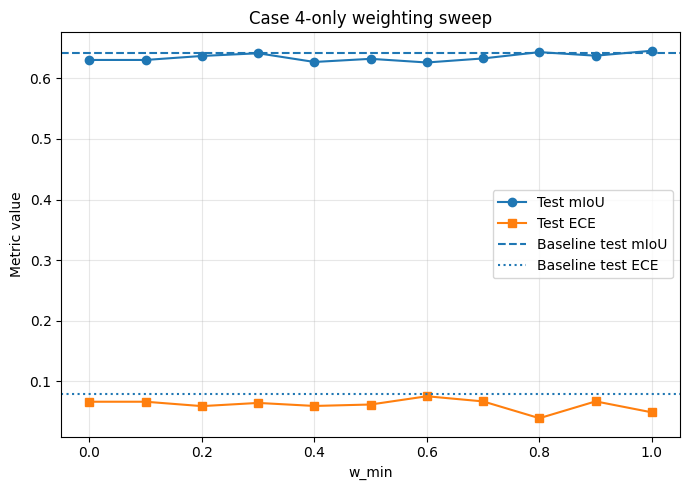

In [36]:
# ============================================================
# Step 8A.6 — Optional plot of Case 4-only weighting sweep
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

plot_df = summary_case4_weight.copy()

# exclude baseline from numeric sweep
plot_df = plot_df[plot_df["exp_key"] != "baseline"].copy()

# convert grouping key back to numeric
plot_df["w_min_num"] = pd.to_numeric(plot_df["w_min_key"], errors="coerce")
plot_df = plot_df.sort_values("w_min_num")

baseline_row = summary_case4_weight.loc[
    summary_case4_weight["exp_key"] == "baseline"
].iloc[0]
baseline_test_miou = float(baseline_row["test_miou_mean"])
baseline_test_ece = float(baseline_row["test_ece_mean"])

plt.figure(figsize=(7, 5))
plt.plot(plot_df["w_min_num"], plot_df["test_miou_mean"], marker="o", label="Test mIoU")
plt.plot(plot_df["w_min_num"], plot_df["test_ece_mean"], marker="s", label="Test ECE")
plt.axhline(baseline_test_miou, linestyle="--", label="Baseline test mIoU")
plt.axhline(baseline_test_ece, linestyle=":", label="Baseline test ECE")
plt.xlabel("w_min")
plt.ylabel("Metric value")
plt.title("Case 4-only weighting sweep")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Step 8A.7 — Pareto-efficient selection (INCLUDING baseline)

In [37]:
# ============================================================
# ============================================================
import numpy as np
import pandas as pd

df_sum = summary_case4_weight.copy()

MI = "val_miou_mean"
ECE = "val_ece_mean"

need_cols = {
    "exp_key", "w_min_key", "n_runs",
    MI, ECE,
    "test_miou_mean", "test_ece_mean",
    "val_miou_mean±std", "val_ece_mean±std",
    "test_miou_mean±std", "test_ece_mean±std",
}
missing = need_cols - set(df_sum.columns)
assert not missing, f"Missing columns: {missing}"

def pareto_efficient_maxmin(df: pd.DataFrame, miou_col: str, ece_col: str) -> pd.DataFrame:
    rows = df.copy().reset_index(drop=True)
    mi = rows[miou_col].to_numpy()
    ec = rows[ece_col].to_numpy()

    keep = np.ones(len(rows), dtype=bool)

    for i in range(len(rows)):
        if not keep[i]:
            continue
        dominates_i = (mi >= mi[i]) & (ec <= ec[i]) & ((mi > mi[i]) | (ec < ec[i]))
        dominates_i[i] = False
        if dominates_i.any():
            keep[i] = False

    return rows[keep].copy().reset_index(drop=True)

df_pareto = pareto_efficient_maxmin(df_sum, MI, ECE)

df_pareto_show = df_pareto.sort_values(
    [ECE, MI], ascending=[True, False]
).reset_index(drop=True)

print("=== Pareto-efficient settings (INCLUDING baseline) ===")
display(
    df_pareto_show[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std"
    ]]
)

=== Pareto-efficient settings (INCLUDING baseline) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std
0,case4_weight_wmin_0p8,0.8,10,0.7880 ± 0.0780,0.0494 ± 0.0328,0.6434 ± 0.0652,0.0392 ± 0.0300
1,case4_weight_wmin_1p0,1.0,10,0.7900 ± 0.0752,0.0643 ± 0.0369,0.6457 ± 0.0581,0.0489 ± 0.0504


### Step 8A.8 — Select best Pareto point (baseline allowed)

In [38]:
# ============================================================
# ============================================================

target_miou = float(df_sum[MI].max())
target_ece  = float(df_sum[ECE].min())

mi_range = float(df_sum[MI].max() - df_sum[MI].min()) or 1.0
ec_range = float(df_sum[ECE].max() - df_sum[ECE].min()) or 1.0

def dist_to_target(row):
    d_mi = (target_miou - float(row[MI])) / mi_range
    d_ec = (float(row[ECE]) - target_ece) / ec_range
    return float(np.sqrt(d_mi**2 + d_ec**2))

df_pareto = df_pareto.copy()
df_pareto["dist_to_target"] = df_pareto.apply(dist_to_target, axis=1)

best_row = df_pareto.sort_values("dist_to_target", ascending=True).iloc[0]
chosen_key = str(best_row["exp_key"])

print("=== Selected setting (baseline may win) ===")
display(
    pd.DataFrame([best_row])[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "dist_to_target"
    ]]
)

=== Selected setting (baseline may win) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,dist_to_target
0,case4_weight_wmin_0p8,0.8,10,0.7880 ± 0.0780,0.0494 ± 0.0328,0.6434 ± 0.0652,0.0392 ± 0.0300,0.110806


### Step 8A.9 — Final comparison

In [39]:
# ============================================================
# ============================================================

if chosen_key == "baseline":
    df_report = df_sum[df_sum["exp_key"] == "baseline"].copy()
else:
    df_report = df_sum[df_sum["exp_key"].isin(["baseline", chosen_key])].copy()

order = {"baseline": 0, chosen_key: 1}
df_report["_ord"] = df_report["exp_key"].map(order).fillna(99).astype(int)
df_report = df_report.sort_values("_ord").drop(columns="_ord")

baseline_test_miou = float(
    df_sum.loc[df_sum["exp_key"] == "baseline", "test_miou_mean"].iloc[0]
)
baseline_test_ece = float(
    df_sum.loc[df_sum["exp_key"] == "baseline", "test_ece_mean"].iloc[0]
)

df_report["delta_test_miou_vs_baseline"] = df_report["test_miou_mean"] - baseline_test_miou
df_report["delta_test_ece_vs_baseline"] = df_report["test_ece_mean"] - baseline_test_ece

print("=== Final comparison ===")
display(
    df_report[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
    ]]
)

=== Final comparison ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,delta_test_miou_vs_baseline,delta_test_ece_vs_baseline
0,baseline,baseline,10,0.7784 ± 0.0848,0.0853 ± 0.0640,0.6415 ± 0.0707,0.0792 ± 0.0696,0.000000,0.000000
9,case4_weight_wmin_0p8,0.8,10,0.7880 ± 0.0780,0.0494 ± 0.0328,0.6434 ± 0.0652,0.0392 ± 0.0300,0.001909,-0.039943


## Section 9 — Filtering only using high uncertainty

### Section 9.1 — Recreate high-uncertainty threshold and mark TRAIN patches

In [25]:
# ============================================================
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

scores_all_path = Path(split_dir) / "patch_scores_all.csv"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

scores_all = pd.read_csv(scores_all_path).dropna(
    subset=["entropy_mean", "disagree_frac", "accuracy"]
).copy()

# Threshold derived from VAL split only
df_audit_pool_unc = (
    scores_all[scores_all["split"] == "val"]
    .dropna(subset=["entropy_mean"])
    .copy()
    .reset_index(drop=True)
)

entropy_threshold_q60_unc = df_audit_pool_unc["entropy_mean"].quantile(0.60)

print("High-uncertainty threshold recreated from VAL split")
print("entropy_threshold_q60_unc :", round(float(entropy_threshold_q60_unc), 6))

scores_train_unc = (
    scores_all[scores_all["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

high_unc_train = scores_train_unc[
    scores_train_unc["entropy_mean"] >= float(entropy_threshold_q60_unc)
].copy()

high_unc_ids = sorted(high_unc_train["idx"].astype(int).tolist())

print("\nTrain split size:", len(scores_train_unc))
print("High-uncertainty TRAIN candidates:", len(high_unc_train))
print("First 20 high-uncertainty idxs:", high_unc_ids[:20])

display(
    high_unc_train[
        ["idx", "row_off", "col_off", "entropy_mean", "disagree_frac", "accuracy"]
    ].sort_values(["entropy_mean", "disagree_frac"], ascending=[False, False]).head(20)
)

High-uncertainty threshold recreated from VAL split
entropy_threshold_q60_unc : 0.706842

Train split size: 2012
High-uncertainty TRAIN candidates: 922
First 20 high-uncertainty idxs: [0, 1, 2, 3, 4, 5, 7, 9, 10, 11, 12, 13, 14, 15, 20, 21, 22, 23, 31, 36]


,idx,row_off,col_off,entropy_mean,disagree_frac,accuracy
1670,1670,512,1536,1.083966,0.061020,0.938980
1677,1677,768,1280,1.073432,0.005478,0.994522
1671,1671,512,1792,1.072216,0.058075,0.941925
1680,1680,1024,0,1.070717,0.044891,0.955109
1678,1678,768,1536,1.069723,0.059509,0.940491
1688,1688,1280,0,1.068836,0.068741,0.931259
1696,1696,1536,0,1.068465,0.082443,0.917557
1676,1676,768,1024,1.066396,0.009781,0.990219
1689,1689,1280,256,1.062975,0.017548,0.982452
1652,1652,0,1024,1.059926,0.317200,0.682800


### Section 9.2 — High-uncertainty-only filtering helper

In [26]:
# ============================================================
# ============================================================

def make_filter_keep_indices_uncertainty_only(
    df_scores_train: pd.DataFrame,
    remove_frac: float,
    entropy_thr: float,
):
    """
    Remove up to k = floor(remove_frac * total_train_patches), but ONLY from
    TRAIN patches with entropy_mean >= entropy_thr.

    Ranking inside the candidate pool:
      highest entropy first, then highest disagreement

    Returns:
      keep_idxs: np.ndarray[int]
      k_removed: int
      n_unc_available: int
    """
    df = df_scores_train.copy()

    unc_mask = df["entropy_mean"] >= float(entropy_thr)
    df_unc = df.loc[unc_mask].copy()

    n_total = len(df)
    n_unc_available = len(df_unc)

    k_target = int(np.floor(float(remove_frac) * n_total))
    if k_target <= 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_unc_available)

    k_remove = min(k_target, n_unc_available)
    if k_remove == 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_unc_available)

    df_unc = df_unc.sort_values(
        ["entropy_mean", "disagree_frac"],
        ascending=[False, False]
    )

    remove_ids = set(df_unc.head(k_remove)["idx"].astype(int).tolist())
    keep = df.loc[~df["idx"].isin(remove_ids), "idx"].to_numpy().astype(int)

    return keep, int(k_remove), int(n_unc_available)

### Section 9.3 — Baseline + high-uncertainty-only filtering runner

In [27]:
# ============================================================
# ============================================================

import json
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

def run_one_strategy_filter_uncertainty_only(strategy: dict) -> dict:
    """
    strategy["type"] in {"baseline", "filter_uncertainty_only"}
    """
    assert strategy["type"] in {"baseline", "filter_uncertainty_only"}

    run_dir = Path(runs_root_unc_only) / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_final_out = run_dir / "model_final.pt"
    ckpt_best_out  = run_dir / "model_best.pt"
    hist_out = run_dir / "train_history.csv"
    eval_out = run_dir / "eval_summary.json"
    bins_val_out = run_dir / "calibration_bins_val.csv"
    bins_test_out = run_dir / "calibration_bins_test.csv"

    # ---- full train ds ----
    full_train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=True,
        aug_prob=float(TRAIN_PARAMS.get("aug_prob", 0.0)),
        noise_std=float(TRAIN_PARAMS.get("noise_std", 0.0)),
        seed=int(cfg.get("seed", 42)),
    )

    # ---- apply high-uncertainty-only filtering on TRAIN ----
    removed = 0
    n_unc_available = 0

    if strategy["type"] == "filter_uncertainty_only":
        remove_frac = float(strategy["remove_frac"])
        keep_idxs, removed, n_unc_available = make_filter_keep_indices_uncertainty_only(
            df_scores_train=scores_train_unc,
            remove_frac=remove_frac,
            entropy_thr=entropy_threshold_q60_unc,
        )
        train_ds2 = Subset(full_train_ds, keep_idxs.tolist())
    else:
        train_ds2 = full_train_ds

    # ---- val/test unchanged ----
    val_ds2 = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    test_ds2 = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    train_loader = DataLoader(
        train_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=True,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )
    val_loader = DataLoader(
        val_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )
    test_loader = DataLoader(
        test_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    # ---- model / optimiser / loss ----
    DROP_P = float(cfg.get("drop_p", 0.2))
    model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(TRAIN_PARAMS["lr"]),
        weight_decay=float(TRAIN_PARAMS["weight_decay"]),
    )

    criterion = nn.CrossEntropyLoss(ignore_index=cfg["ignore_index"], weight=weights_t)

    # ---- fixed epochs + best checkpoint ----
    max_epochs = 10
    history = []
    t0 = time.time()

    best_val_miou = -1.0
    best_epoch = -1

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_miou = eval_macro_iou(model, val_loader, cfg["num_classes"], cfg["ignore_index"], device)

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_macro_iou": float(val_miou),
        })

        print(f"[{strategy['name']}] Epoch {epoch:02d}/{max_epochs} | loss={train_loss:.4f} | val_mIoU={val_miou:.4f}")

        improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
        if improved:
            best_val_miou = float(val_miou)
            best_epoch = int(epoch)

            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "train_params": TRAIN_PARAMS,
                "strategy": strategy,
                "drop_p": DROP_P,
                "best_epoch": best_epoch,
                "best_val_miou": best_val_miou,
                "train_mean": train_mean,
                "train_std": train_std,
            }, ckpt_best_out)

    train_time = time.time() - t0
    pd.DataFrame(history).to_csv(hist_out, index=False)

    torch.save({
        "model_state_dict": model.state_dict(),
        "cfg": cfg,
        "train_params": TRAIN_PARAMS,
        "strategy": strategy,
        "drop_p": DROP_P,
        "final_epoch": int(max_epochs),
        "train_mean": train_mean,
        "train_std": train_std,
    }, ckpt_final_out)

    # ---- reload best checkpoint for eval ----
    ckpt_best = torch.load(ckpt_best_out, map_location=device)
    model = build_unet_mcdo_explicit(drop_p=float(ckpt_best.get("drop_p", DROP_P))).to(device)
    model.load_state_dict(ckpt_best["model_state_dict"], strict=True)
    model.eval()

    test_miou = eval_macro_iou(model, test_loader, cfg["num_classes"], cfg["ignore_index"], device)

    # ---- calibration ----
    T_mc = int(cfg.get("T_mc", 10))
    n_bins = int(cfg.get("ece_bins", 15))
    batch_cal = int(cfg.get("batch_size_mc", 2))
    max_cal = None if cfg.get("phase") == "small" else cfg.get("max_cal_patches", None)

    res_val = compute_calibration_bins(
        model=model, dataset=val_ds2, split_name="val",
        T=T_mc, num_classes=cfg["num_classes"], ignore_index=cfg["ignore_index"], device=device,
        n_bins=n_bins, batch_size=batch_cal, max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )
    res_test = compute_calibration_bins(
        model=model, dataset=test_ds2, split_name="test",
        T=T_mc, num_classes=cfg["num_classes"], ignore_index=cfg["ignore_index"], device=device,
        n_bins=n_bins, batch_size=batch_cal, max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_val["df_bins"].to_csv(bins_val_out, index=False)
    res_test["df_bins"].to_csv(bins_test_out, index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "seed": int(cfg.get("seed", 42)),
        "remove_frac": float(strategy.get("remove_frac", 0.0)),
        "n_train_patches_used": int(len(train_ds2)),
        "removed_train_patches": int(removed),
        "n_unc_available": int(n_unc_available),
        "final_epoch": int(max_epochs),
        "best_epoch": int(best_epoch),
        "best_val_miou": float(best_val_miou),
        "test_miou": float(test_miou),
        "val_ece": float(res_val["ece"]),
        "test_ece": float(res_test["ece"]),
        "ece_bins": int(n_bins),
        "T_mc": int(T_mc),
        "train_time_sec": float(train_time),
        "unc_entropy_thr": float(entropy_threshold_q60_unc),
        "paths": {
            "run_dir": str(run_dir),
            "model_best": str(ckpt_best_out),
            "model_final": str(ckpt_final_out),
            "history": str(hist_out),
            "calib_val": str(bins_val_out),
            "calib_test": str(bins_test_out),
        },
    }

    with open(eval_out, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] Saved run artefacts -> {run_dir}")
    return summary

### Section 9.4 — Execute baseline + high-uncertainty-only filtering

In [28]:
# ============================================================
# ============================================================

from pathlib import Path
import shutil

SEEDS_UNC_ONLY = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

runs_root_unc_only = split_dir / "step9_uncertainty_only_filters_10seeds"
if runs_root_unc_only.exists():
    shutil.rmtree(runs_root_unc_only)
runs_root_unc_only.mkdir(parents=True, exist_ok=True)

print("Runs root:", runs_root_unc_only)

EXPERIMENTS_UNC_ONLY = [
    {"key": "baseline",           "type": "baseline",                "remove_frac": None},
    {"key": "unc_filter_5",       "type": "filter_uncertainty_only", "remove_frac": 0.05},
    {"key": "unc_filter_10",      "type": "filter_uncertainty_only", "remove_frac": 0.10},
    {"key": "unc_filter_20",      "type": "filter_uncertainty_only", "remove_frac": 0.20},
    {"key": "unc_filter_30",      "type": "filter_uncertainty_only", "remove_frac": 0.30},
    {"key": "unc_filter_40",      "type": "filter_uncertainty_only", "remove_frac": 0.40},
    {"key": "unc_filter_50",      "type": "filter_uncertainty_only", "remove_frac": 0.50},
]

all_rows_unc_only = []

for exp in EXPERIMENTS_UNC_ONLY:
    for s in SEEDS_UNC_ONLY:
        seed_everything(s)
        cfg["seed"] = int(s)

        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "filter_uncertainty_only",
                "remove_frac": float(exp["remove_frac"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_filter_uncertainty_only(strat)
        res["exp_key"] = exp["key"]
        res["remove_frac"] = float(exp["remove_frac"]) if exp["remove_frac"] is not None else 0.0
        all_rows_unc_only.append(res)

df_unc_only_runs = pd.DataFrame(all_rows_unc_only)

out_csv_unc_only = runs_root_unc_only / "step9_uncertainty_only_filters_10seeds.csv"
df_unc_only_runs.to_csv(out_csv_unc_only, index=False)

print("Saved raw runs:", out_csv_unc_only)

display(df_unc_only_runs[[
    "exp_key", "remove_frac", "seed",
    "best_epoch", "best_val_miou", "val_ece",
    "test_miou", "test_ece",
    "train_time_sec", "n_train_patches_used",
    "removed_train_patches", "n_unc_available"
]])

Runs root: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step9_uncertainty_only_filters_10seeds

Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] Epoch 01/10 | loss=0.7825 | val_mIoU=0.7107
[baseline_seed_42] Epoch 02/10 | loss=0.5466 | val_mIoU=0.7394
[baseline_seed_42] Epoch 03/10 | loss=0.4418 | val_mIoU=0.7705
[baseline_seed_42] Epoch 04/10 | loss=0.3722 | val_mIoU=0.8174
[baseline_seed_42] Epoch 05/10 | loss=0.3296 | val_mIoU=0.7928
[baseline_seed_42] Epoch 06/10 | loss=0.3031 | val_mIoU=0.8067
[baseline_seed_42] Epoch 07/10 | loss=0.2781 | val_mIoU=0.7217
[baseline_seed_42] Epoch 08/10 | loss=0.2651 | val_mIoU=0.8289
[baseline_seed_42] Epoch 09/10 | loss=0.2579 | val_mIoU=0.7958
[baseline_seed_42] Epoch 10/10 | loss=0.2494 | val_mIoU=0.8089
[baseline_seed_42] Saved run artefacts -> ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step9_uncertainty_only_filters_10seeds/baseline_seed_42

Running: {'name': 'baseline_seed_43', 'type': 'basel

,exp_key,remove_frac,seed,best_epoch,best_val_miou,val_ece,test_miou,test_ece,train_time_sec,n_train_patches_used,removed_train_patches,n_unc_available
0,baseline,0.0,42,8,0.828854,0.056084,0.691083,0.035868,1350.057763,2012,0,0
1,baseline,0.0,43,3,0.739178,0.134152,0.600346,0.144620,1358.227455,2012,0,0
2,baseline,0.0,44,2,0.688647,0.241339,0.562817,0.231093,1377.700593,2012,0,0
3,baseline,0.0,45,8,0.825893,0.035552,0.673798,0.009385,1372.223083,2012,0,0
4,baseline,0.0,46,8,0.825247,0.055581,0.689380,0.070469,1374.857960,2012,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
65,unc_filter_50,0.5,47,8,0.570379,0.051248,0.438301,0.019353,837.615028,1090,922,922
66,unc_filter_50,0.5,48,6,0.577977,0.164419,0.443079,0.175515,848.795993,1090,922,922
67,unc_filter_50,0.5,49,2,0.581960,0.315270,0.403616,0.200191,848.312296,1090,922,922
68,unc_filter_50,0.5,50,10,0.574726,0.050656,0.430560,0.039542,847.143946,1090,922,922


### Section 9.5 — Summary table for high-uncertainty-only filtering

In [29]:
# ============================================================
# ============================================================

summary_unc_only = (
    df_unc_only_runs.groupby(["exp_key", "remove_frac"], as_index=False)
    .agg(
        n_runs=("seed", "count"),
        mean_removed=("removed_train_patches", "mean"),
        mean_unc_available=("n_unc_available", "mean"),

        val_miou_mean=("best_val_miou", "mean"),
        val_miou_std=("best_val_miou", "std"),
        val_ece_mean=("val_ece", "mean"),
        val_ece_std=("val_ece", "std"),

        test_miou_mean=("test_miou", "mean"),
        test_miou_std=("test_miou", "std"),
        test_ece_mean=("test_ece", "mean"),
        test_ece_std=("test_ece", "std"),
    )
)

summary_unc_only["val_miou_mean±std"] = summary_unc_only.apply(
    lambda r: f"{r['val_miou_mean']:.4f} ± {r['val_miou_std']:.4f}", axis=1
)
summary_unc_only["val_ece_mean±std"] = summary_unc_only.apply(
    lambda r: f"{r['val_ece_mean']:.4f} ± {r['val_ece_std']:.4f}", axis=1
)
summary_unc_only["test_miou_mean±std"] = summary_unc_only.apply(
    lambda r: f"{r['test_miou_mean']:.4f} ± {r['test_miou_std']:.4f}", axis=1
)
summary_unc_only["test_ece_mean±std"] = summary_unc_only.apply(
    lambda r: f"{r['test_ece_mean']:.4f} ± {r['test_ece_std']:.4f}", axis=1
)

baseline_row = summary_unc_only[summary_unc_only["exp_key"] == "baseline"].iloc[0]
summary_unc_only["delta_test_miou_vs_baseline"] = (
    summary_unc_only["test_miou_mean"] - float(baseline_row["test_miou_mean"])
)
summary_unc_only["delta_test_ece_vs_baseline"] = (
    summary_unc_only["test_ece_mean"] - float(baseline_row["test_ece_mean"])
)

summary_out_unc_only = runs_root_unc_only / "step9_uncertainty_only_filters_10seeds_summary.csv"
summary_unc_only.to_csv(summary_out_unc_only, index=False)

print("Saved summary:", summary_out_unc_only)

display(summary_unc_only[[
    "exp_key", "remove_frac", "n_runs",
    "mean_removed", "mean_unc_available",
    "val_miou_mean±std", "val_ece_mean±std",
    "test_miou_mean±std", "test_ece_mean±std",
    "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
]])

Saved summary: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step9_uncertainty_only_filters_10seeds/step9_uncertainty_only_filters_10seeds_summary.csv


,exp_key,remove_frac,n_runs,mean_removed,mean_unc_available,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,delta_test_miou_vs_baseline,delta_test_ece_vs_baseline
0,baseline,0.00,10,0.0,0.0,0.7784 ± 0.0848,0.0853 ± 0.0640,0.6415 ± 0.0707,0.0792 ± 0.0696,0.000000,0.000000
1,unc_filter_10,0.10,10,201.0,922.0,0.6789 ± 0.1009,0.0834 ± 0.0953,0.5461 ± 0.0696,0.0699 ± 0.0806,-0.095397,-0.009301
2,unc_filter_20,0.20,10,402.0,922.0,0.6167 ± 0.0466,0.0948 ± 0.1263,0.4707 ± 0.0524,0.0782 ± 0.1141,-0.170727,-0.000942
3,unc_filter_30,0.30,10,603.0,922.0,0.5925 ± 0.0291,0.0552 ± 0.0260,0.4700 ± 0.0129,0.0449 ± 0.0251,-0.171474,-0.034308
4,unc_filter_40,0.40,10,804.0,922.0,0.5804 ± 0.0192,0.1001 ± 0.0923,0.4495 ± 0.0231,0.0842 ± 0.0862,-0.191974,0.005046
5,unc_filter_5,0.05,10,100.0,922.0,0.7382 ± 0.1043,0.0412 ± 0.0204,0.5963 ± 0.0845,0.0255 ± 0.0168,-0.045135,-0.053693
6,unc_filter_50,0.50,10,922.0,922.0,0.5746 ± 0.0035,0.1263 ± 0.0771,0.4457 ± 0.0187,0.1042 ± 0.0606,-0.195706,0.025066


## Section 10 — Filtering only using high disagreement

### Section 10.1 — Recreate high-disagreement threshold and mark TRAIN patches

In [30]:
# ============================================================
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

scores_all_path = Path(split_dir) / "patch_scores_all.csv"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

scores_all = pd.read_csv(scores_all_path).dropna(
    subset=["entropy_mean", "disagree_frac", "accuracy"]
).copy()

# Threshold derived from VAL split only
df_audit_pool_dis = (
    scores_all[scores_all["split"] == "val"]
    .dropna(subset=["disagree_frac"])
    .copy()
    .reset_index(drop=True)
)

disagreement_threshold_q75_dis = df_audit_pool_dis["disagree_frac"].quantile(0.75)

print("High-disagreement threshold recreated from VAL split")
print("disagreement_threshold_q75_dis :", round(float(disagreement_threshold_q75_dis), 6))

scores_train_dis = (
    scores_all[scores_all["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

high_dis_train = scores_train_dis[
    scores_train_dis["disagree_frac"] >= float(disagreement_threshold_q75_dis)
].copy()

high_dis_ids = sorted(high_dis_train["idx"].astype(int).tolist())

print("\nTrain split size:", len(scores_train_dis))
print("High-disagreement TRAIN candidates:", len(high_dis_train))
print("First 20 high-disagreement idxs:", high_dis_ids[:20])

display(
    high_dis_train[
        ["idx", "row_off", "col_off", "entropy_mean", "disagree_frac", "accuracy"]
    ].sort_values(["disagree_frac", "entropy_mean"], ascending=[False, False]).head(20)
)

High-disagreement threshold recreated from VAL split
disagreement_threshold_q75_dis : 0.110817

Train split size: 2012
High-disagreement TRAIN candidates: 485
First 20 high-disagreement idxs: [1, 4, 5, 7, 13, 15, 23, 31, 39, 64, 66, 67, 69, 70, 71, 72, 73, 75, 78, 79]


,idx,row_off,col_off,entropy_mean,disagree_frac,accuracy
1139,1139,5120,8960,0.745848,0.813141,0.186859
1656,1656,256,0,0.613752,0.772339,0.227661
1131,1131,4864,8960,0.826448,0.566940,0.433060
1664,1664,512,0,0.777027,0.562943,0.437057
1138,1138,5120,8704,0.790324,0.504684,0.495316
964,964,12032,1024,0.674013,0.492233,0.507767
1147,1147,5376,8960,0.863807,0.468063,0.531937
1146,1146,5376,8704,0.833026,0.466995,0.533005
1747,1747,1024,6912,0.990509,0.449081,0.550919
1153,1153,5632,8448,0.790634,0.414841,0.585159


### Section 10.2 — High-disagreement-only filtering helper

In [31]:
# ============================================================
# ============================================================

def make_filter_keep_indices_disagreement_only(
    df_scores_train: pd.DataFrame,
    remove_frac: float,
    disagree_thr: float,
):
    """
    Remove up to k = floor(remove_frac * total_train_patches), but ONLY from
    TRAIN patches with disagree_frac >= disagree_thr.

    Ranking inside the candidate pool:
      highest disagreement first, then highest entropy

    Returns:
      keep_idxs: np.ndarray[int]
      k_removed: int
      n_dis_available: int
    """
    df = df_scores_train.copy()

    dis_mask = df["disagree_frac"] >= float(disagree_thr)
    df_dis = df.loc[dis_mask].copy()

    n_total = len(df)
    n_dis_available = len(df_dis)

    k_target = int(np.floor(float(remove_frac) * n_total))
    if k_target <= 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_dis_available)

    k_remove = min(k_target, n_dis_available)
    if k_remove == 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_dis_available)

    df_dis = df_dis.sort_values(
        ["disagree_frac", "entropy_mean"],
        ascending=[False, False]
    )

    remove_ids = set(df_dis.head(k_remove)["idx"].astype(int).tolist())
    keep = df.loc[~df["idx"].isin(remove_ids), "idx"].to_numpy().astype(int)

    return keep, int(k_remove), int(n_dis_available)

### Section 10.3 — Baseline + high-disagreement-only filtering runner

In [32]:
# ============================================================
# ============================================================

import json
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

def run_one_strategy_filter_disagreement_only(strategy: dict) -> dict:
    """
    strategy["type"] in {"baseline", "filter_disagreement_only"}
    """
    assert strategy["type"] in {"baseline", "filter_disagreement_only"}

    run_dir = Path(runs_root_dis_only) / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_final_out = run_dir / "model_final.pt"
    ckpt_best_out  = run_dir / "model_best.pt"
    hist_out = run_dir / "train_history.csv"
    eval_out = run_dir / "eval_summary.json"
    bins_val_out = run_dir / "calibration_bins_val.csv"
    bins_test_out = run_dir / "calibration_bins_test.csv"

    full_train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=True,
        aug_prob=float(TRAIN_PARAMS.get("aug_prob", 0.0)),
        noise_std=float(TRAIN_PARAMS.get("noise_std", 0.0)),
        seed=int(cfg.get("seed", 42)),
    )

    removed = 0
    n_dis_available = 0

    if strategy["type"] == "filter_disagreement_only":
        remove_frac = float(strategy["remove_frac"])
        keep_idxs, removed, n_dis_available = make_filter_keep_indices_disagreement_only(
            df_scores_train=scores_train_dis,
            remove_frac=remove_frac,
            disagree_thr=disagreement_threshold_q75_dis,
        )
        train_ds2 = Subset(full_train_ds, keep_idxs.tolist())
    else:
        train_ds2 = full_train_ds

    val_ds2 = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    test_ds2 = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    train_loader = DataLoader(
        train_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=True,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )
    val_loader = DataLoader(
        val_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )
    test_loader = DataLoader(
        test_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    DROP_P = float(cfg.get("drop_p", 0.2))
    model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(TRAIN_PARAMS["lr"]),
        weight_decay=float(TRAIN_PARAMS["weight_decay"]),
    )

    criterion = nn.CrossEntropyLoss(ignore_index=cfg["ignore_index"], weight=weights_t)

    max_epochs = 10
    history = []
    t0 = time.time()

    best_val_miou = -1.0
    best_epoch = -1

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_miou = eval_macro_iou(model, val_loader, cfg["num_classes"], cfg["ignore_index"], device)

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_macro_iou": float(val_miou),
        })

        print(f"[{strategy['name']}] Epoch {epoch:02d}/{max_epochs} | loss={train_loss:.4f} | val_mIoU={val_miou:.4f}")

        improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
        if improved:
            best_val_miou = float(val_miou)
            best_epoch = int(epoch)

            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "train_params": TRAIN_PARAMS,
                "strategy": strategy,
                "drop_p": DROP_P,
                "best_epoch": best_epoch,
                "best_val_miou": best_val_miou,
                "train_mean": train_mean,
                "train_std": train_std,
            }, ckpt_best_out)

    train_time = time.time() - t0
    pd.DataFrame(history).to_csv(hist_out, index=False)

    torch.save({
        "model_state_dict": model.state_dict(),
        "cfg": cfg,
        "train_params": TRAIN_PARAMS,
        "strategy": strategy,
        "drop_p": DROP_P,
        "final_epoch": int(max_epochs),
        "train_mean": train_mean,
        "train_std": train_std,
    }, ckpt_final_out)

    ckpt_best = torch.load(ckpt_best_out, map_location=device)
    model = build_unet_mcdo_explicit(drop_p=float(ckpt_best.get("drop_p", DROP_P))).to(device)
    model.load_state_dict(ckpt_best["model_state_dict"], strict=True)
    model.eval()

    test_miou = eval_macro_iou(model, test_loader, cfg["num_classes"], cfg["ignore_index"], device)

    T_mc = int(cfg.get("T_mc", 10))
    n_bins = int(cfg.get("ece_bins", 15))
    batch_cal = int(cfg.get("batch_size_mc", 2))
    max_cal = None if cfg.get("phase") == "small" else cfg.get("max_cal_patches", None)

    res_val = compute_calibration_bins(
        model=model, dataset=val_ds2, split_name="val",
        T=T_mc, num_classes=cfg["num_classes"], ignore_index=cfg["ignore_index"], device=device,
        n_bins=n_bins, batch_size=batch_cal, max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )
    res_test = compute_calibration_bins(
        model=model, dataset=test_ds2, split_name="test",
        T=T_mc, num_classes=cfg["num_classes"], ignore_index=cfg["ignore_index"], device=device,
        n_bins=n_bins, batch_size=batch_cal, max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_val["df_bins"].to_csv(bins_val_out, index=False)
    res_test["df_bins"].to_csv(bins_test_out, index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "seed": int(cfg.get("seed", 42)),
        "remove_frac": float(strategy.get("remove_frac", 0.0)),
        "n_train_patches_used": int(len(train_ds2)),
        "removed_train_patches": int(removed),
        "n_dis_available": int(n_dis_available),
        "final_epoch": int(max_epochs),
        "best_epoch": int(best_epoch),
        "best_val_miou": float(best_val_miou),
        "test_miou": float(test_miou),
        "val_ece": float(res_val["ece"]),
        "test_ece": float(res_test["ece"]),
        "ece_bins": int(n_bins),
        "T_mc": int(T_mc),
        "train_time_sec": float(train_time),
        "disagree_thr": float(disagreement_threshold_q75_dis),
        "paths": {
            "run_dir": str(run_dir),
            "model_best": str(ckpt_best_out),
            "model_final": str(ckpt_final_out),
            "history": str(hist_out),
            "calib_val": str(bins_val_out),
            "calib_test": str(bins_test_out),
        },
    }

    with open(eval_out, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] Saved run artefacts -> {run_dir}")
    return summary

### Section 10.4 — Execute baseline + high-disagreement-only filtering

In [33]:
# ============================================================
# ============================================================

from pathlib import Path
import shutil

SEEDS_DIS_ONLY = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

runs_root_dis_only = split_dir / "step10_disagreement_only_filters_10seeds"
if runs_root_dis_only.exists():
    shutil.rmtree(runs_root_dis_only)
runs_root_dis_only.mkdir(parents=True, exist_ok=True)

print("Runs root:", runs_root_dis_only)

EXPERIMENTS_DIS_ONLY = [
    {"key": "baseline",           "type": "baseline",                 "remove_frac": None},
    {"key": "dis_filter_5",       "type": "filter_disagreement_only", "remove_frac": 0.05},
    {"key": "dis_filter_10",      "type": "filter_disagreement_only", "remove_frac": 0.10},
    {"key": "dis_filter_20",      "type": "filter_disagreement_only", "remove_frac": 0.20},
    {"key": "dis_filter_30",      "type": "filter_disagreement_only", "remove_frac": 0.30},
    {"key": "dis_filter_40",      "type": "filter_disagreement_only", "remove_frac": 0.40},
    {"key": "dis_filter_50",      "type": "filter_disagreement_only", "remove_frac": 0.50},
]

all_rows_dis_only = []

for exp in EXPERIMENTS_DIS_ONLY:
    for s in SEEDS_DIS_ONLY:
        seed_everything(s)
        cfg["seed"] = int(s)

        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "filter_disagreement_only",
                "remove_frac": float(exp["remove_frac"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_filter_disagreement_only(strat)
        res["exp_key"] = exp["key"]
        res["remove_frac"] = float(exp["remove_frac"]) if exp["remove_frac"] is not None else 0.0
        all_rows_dis_only.append(res)

df_dis_only_runs = pd.DataFrame(all_rows_dis_only)

out_csv_dis_only = runs_root_dis_only / "step10_disagreement_only_filters_10seeds.csv"
df_dis_only_runs.to_csv(out_csv_dis_only, index=False)

print("Saved raw runs:", out_csv_dis_only)

display(df_dis_only_runs[[
    "exp_key", "remove_frac", "seed",
    "best_epoch", "best_val_miou", "val_ece",
    "test_miou", "test_ece",
    "train_time_sec", "n_train_patches_used",
    "removed_train_patches", "n_dis_available"
]])

Runs root: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step10_disagreement_only_filters_10seeds

Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] Epoch 01/10 | loss=0.7825 | val_mIoU=0.7107
[baseline_seed_42] Epoch 02/10 | loss=0.5466 | val_mIoU=0.7394
[baseline_seed_42] Epoch 03/10 | loss=0.4418 | val_mIoU=0.7705
[baseline_seed_42] Epoch 04/10 | loss=0.3722 | val_mIoU=0.8174
[baseline_seed_42] Epoch 05/10 | loss=0.3296 | val_mIoU=0.7928
[baseline_seed_42] Epoch 06/10 | loss=0.3031 | val_mIoU=0.8067
[baseline_seed_42] Epoch 07/10 | loss=0.2781 | val_mIoU=0.7217
[baseline_seed_42] Epoch 08/10 | loss=0.2651 | val_mIoU=0.8289
[baseline_seed_42] Epoch 09/10 | loss=0.2579 | val_mIoU=0.7958
[baseline_seed_42] Epoch 10/10 | loss=0.2494 | val_mIoU=0.8090
[baseline_seed_42] Saved run artefacts -> ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step10_disagreement_only_filters_10seeds/baseline_seed_42

Running: {'name': 'baseline_seed_43', 'type': 'b

,exp_key,remove_frac,seed,best_epoch,best_val_miou,val_ece,test_miou,test_ece,train_time_sec,n_train_patches_used,removed_train_patches,n_dis_available
0,baseline,0.0,42,8,0.828854,0.056084,0.691083,0.035868,1451.902518,2012,0,0
1,baseline,0.0,43,3,0.739178,0.134152,0.600346,0.144620,1474.383777,2012,0,0
2,baseline,0.0,44,2,0.688647,0.241339,0.562817,0.231093,1455.646000,2012,0,0
3,baseline,0.0,45,8,0.825893,0.035552,0.673798,0.009385,1449.134933,2012,0,0
4,baseline,0.0,46,8,0.825247,0.055581,0.689380,0.070469,1448.932413,2012,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
65,dis_filter_50,0.5,47,10,0.580408,0.019557,0.495188,0.012997,1103.203819,1527,485,485
66,dis_filter_50,0.5,48,3,0.606466,0.210944,0.486011,0.213315,1110.567289,1527,485,485
67,dis_filter_50,0.5,49,10,0.578699,0.044006,0.492848,0.031291,1163.116666,1527,485,485
68,dis_filter_50,0.5,50,8,0.579294,0.047983,0.489294,0.029363,1113.301356,1527,485,485


### Section 10.5 — Summary table for high-disagreement-only filtering

In [34]:
# ============================================================
# ============================================================

summary_dis_only = (
    df_dis_only_runs.groupby(["exp_key", "remove_frac"], as_index=False)
    .agg(
        n_runs=("seed", "count"),
        mean_removed=("removed_train_patches", "mean"),
        mean_dis_available=("n_dis_available", "mean"),

        val_miou_mean=("best_val_miou", "mean"),
        val_miou_std=("best_val_miou", "std"),
        val_ece_mean=("val_ece", "mean"),
        val_ece_std=("val_ece", "std"),

        test_miou_mean=("test_miou", "mean"),
        test_miou_std=("test_miou", "std"),
        test_ece_mean=("test_ece", "mean"),
        test_ece_std=("test_ece", "std"),
    )
)

summary_dis_only["val_miou_mean±std"] = summary_dis_only.apply(
    lambda r: f"{r['val_miou_mean']:.4f} ± {r['val_miou_std']:.4f}", axis=1
)
summary_dis_only["val_ece_mean±std"] = summary_dis_only.apply(
    lambda r: f"{r['val_ece_mean']:.4f} ± {r['val_ece_std']:.4f}", axis=1
)
summary_dis_only["test_miou_mean±std"] = summary_dis_only.apply(
    lambda r: f"{r['test_miou_mean']:.4f} ± {r['test_miou_std']:.4f}", axis=1
)
summary_dis_only["test_ece_mean±std"] = summary_dis_only.apply(
    lambda r: f"{r['test_ece_mean']:.4f} ± {r['test_ece_std']:.4f}", axis=1
)

baseline_row = summary_dis_only[summary_dis_only["exp_key"] == "baseline"].iloc[0]
summary_dis_only["delta_test_miou_vs_baseline"] = (
    summary_dis_only["test_miou_mean"] - float(baseline_row["test_miou_mean"])
)
summary_dis_only["delta_test_ece_vs_baseline"] = (
    summary_dis_only["test_ece_mean"] - float(baseline_row["test_ece_mean"])
)

summary_out_dis_only = runs_root_dis_only / "step10_disagreement_only_filters_10seeds_summary.csv"
summary_dis_only.to_csv(summary_out_dis_only, index=False)

print("Saved summary:", summary_out_dis_only)

display(summary_dis_only[[
    "exp_key", "remove_frac", "n_runs",
    "mean_removed", "mean_dis_available",
    "val_miou_mean±std", "val_ece_mean±std",
    "test_miou_mean±std", "test_ece_mean±std",
    "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
]])

Saved summary: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step10_disagreement_only_filters_10seeds/step10_disagreement_only_filters_10seeds_summary.csv


,exp_key,remove_frac,n_runs,mean_removed,mean_dis_available,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,delta_test_miou_vs_baseline,delta_test_ece_vs_baseline
0,baseline,0.00,10,0.0,0.0,0.7784 ± 0.0848,0.0853 ± 0.0640,0.6415 ± 0.0707,0.0792 ± 0.0696,0.000000,0.000000
1,dis_filter_10,0.10,10,201.0,485.0,0.7086 ± 0.1044,0.0405 ± 0.0310,0.5778 ± 0.0813,0.0314 ± 0.0234,-0.063678,-0.047726
2,dis_filter_20,0.20,10,402.0,485.0,0.6480 ± 0.0554,0.0967 ± 0.1005,0.5297 ± 0.0377,0.0899 ± 0.1123,-0.111749,0.010778
3,dis_filter_30,0.30,10,485.0,485.0,0.5930 ± 0.0255,0.0763 ± 0.0782,0.4930 ± 0.0147,0.0668 ± 0.0900,-0.148425,-0.012412
4,dis_filter_40,0.40,10,485.0,485.0,0.5930 ± 0.0255,0.0763 ± 0.0782,0.4930 ± 0.0147,0.0668 ± 0.0900,-0.148425,-0.012412
5,dis_filter_5,0.05,10,100.0,485.0,0.7269 ± 0.1026,0.0706 ± 0.0805,0.5915 ± 0.0867,0.0624 ± 0.0850,-0.049987,-0.016754
6,dis_filter_50,0.50,10,485.0,485.0,0.5930 ± 0.0255,0.0763 ± 0.0782,0.4930 ± 0.0147,0.0668 ± 0.0900,-0.148425,-0.012412


## Section 11 — Filtering using Case 4 (high entropy + high disagreement)

### Section 11.1 — Recreate Case 4 thresholds and mark TRAIN patches

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd

scores_all_path = Path(split_dir) / "patch_scores_all.csv"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

scores_all = pd.read_csv(scores_all_path).dropna(
    subset=["entropy_mean", "disagree_frac", "accuracy"]
).copy()

# Thresholds derived from VAL split only
df_audit_pool_case4_s11 = (
    scores_all[scores_all["split"] == "val"]
    .dropna(subset=["entropy_mean", "disagree_frac"])
    .copy()
    .reset_index(drop=True)
)

entropy_threshold_q60_case4_s11 = df_audit_pool_case4_s11["entropy_mean"].quantile(0.60)
disagreement_threshold_q75_case4_s11 = df_audit_pool_case4_s11["disagree_frac"].quantile(0.75)

print("Case 4 thresholds recreated from VAL split")
print("entropy_threshold_q60_case4_s11      :", round(float(entropy_threshold_q60_case4_s11), 6))
print("disagreement_threshold_q75_case4_s11 :", round(float(disagreement_threshold_q75_case4_s11), 6))

def assign_case_from_thresholds_s11(row, entropy_thr, disagree_thr):
    high_entropy = row["entropy_mean"] >= entropy_thr
    high_disagreement = row["disagree_frac"] >= disagree_thr

    if (not high_entropy) and (not high_disagreement):
        return "case_1_low_entropy_agree"
    elif high_entropy and (not high_disagreement):
        return "case_2_high_entropy_agree"
    elif (not high_entropy) and high_disagreement:
        return "case_3_low_entropy_disagree"
    else:
        return "case_4_high_entropy_disagree"

scores_all["audit_case_s11"] = scores_all.apply(
    assign_case_from_thresholds_s11,
    axis=1,
    entropy_thr=entropy_threshold_q60_case4_s11,
    disagree_thr=disagreement_threshold_q75_case4_s11,
)

scores_train_case4_s11 = (
    scores_all[scores_all["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

case4_train_s11 = scores_train_case4_s11[
    scores_train_case4_s11["audit_case_s11"] == "case_4_high_entropy_disagree"
].copy()

case4_ids_s11 = sorted(case4_train_s11["idx"].astype(int).tolist())

print("\nTrain split size:", len(scores_train_case4_s11))
print("Train Case 4 candidates:", len(case4_train_s11))
print("First 20 Case 4 idxs:", case4_ids_s11[:20])

display(
    case4_train_s11[
        ["idx", "row_off", "col_off", "entropy_mean", "disagree_frac", "accuracy", "audit_case_s11"]
    ].sort_values(["entropy_mean", "disagree_frac"], ascending=[False, False]).head(20)
)

Case 4 thresholds recreated from VAL split
entropy_threshold_q60_case4_s11      : 0.419357
disagreement_threshold_q75_case4_s11 : 0.086594

Train split size: 2012
Train Case 4 candidates: 473
First 20 Case 4 idxs: [1, 2, 3, 4, 5, 7, 13, 15, 31, 64, 65, 66, 67, 69, 70, 72, 73, 75, 78, 79]


,idx,row_off,col_off,entropy_mean,disagree_frac,accuracy,audit_case_s11
1688,1688,1280,0,1.014968,0.197296,0.802704,case_4_high_entropy_disagree
1696,1696,1536,0,1.000670,0.173523,0.826477,case_4_high_entropy_disagree
1680,1680,1024,0,0.968565,0.090103,0.909897,case_4_high_entropy_disagree
1673,1673,768,256,0.938655,0.200180,0.799820,case_4_high_entropy_disagree
1746,1746,1024,6656,0.890662,0.256195,0.743805,case_4_high_entropy_disagree
1669,1669,512,1280,0.878152,0.416779,0.583221,case_4_high_entropy_disagree
1678,1678,768,1536,0.875179,0.228607,0.771393,case_4_high_entropy_disagree
1739,1739,768,6912,0.875108,0.176605,0.823395,case_4_high_entropy_disagree
1763,1763,1536,6912,0.861025,0.164642,0.835358,case_4_high_entropy_disagree
1670,1670,512,1536,0.858284,0.203033,0.796967,case_4_high_entropy_disagree


### Section 11.2 — Case 4-only filtering helper

In [25]:
def make_filter_keep_indices_case4_only_s11(
    df_scores_train: pd.DataFrame,
    remove_frac: float,
    entropy_thr: float,
    disagree_thr: float,
):
    """
    Remove up to k = floor(remove_frac * total_train_patches), but ONLY from
    TRAIN patches that fall in Case 4:
        high entropy AND high disagreement

    Ranking inside Case 4:
      highest entropy first, then highest disagreement

    Returns:
      keep_idxs: np.ndarray[int]
      k_removed: int
      n_case4_available: int
    """
    df = df_scores_train.copy()

    case4_mask = (
        (df["entropy_mean"] >= float(entropy_thr)) &
        (df["disagree_frac"] >= float(disagree_thr))
    )
    df_case4 = df.loc[case4_mask].copy()

    n_total = len(df)
    n_case4_available = len(df_case4)

    k_target = int(np.floor(float(remove_frac) * n_total))
    if k_target <= 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_case4_available)

    k_remove = min(k_target, n_case4_available)
    if k_remove == 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_case4_available)

    df_case4 = df_case4.sort_values(
        ["entropy_mean", "disagree_frac"],
        ascending=[False, False]
    )

    remove_ids = set(df_case4.head(k_remove)["idx"].astype(int).tolist())
    keep = df.loc[~df["idx"].isin(remove_ids), "idx"].to_numpy().astype(int)

    return keep, int(k_remove), int(n_case4_available)

### Section 11.3 — Baseline + Case 4-only filtering runner

In [26]:
import json
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

def run_one_strategy_filter_case4_only_s11(strategy: dict) -> dict:
    """
    strategy["type"] in {"baseline", "filter_case4_only"}
    """
    assert strategy["type"] in {"baseline", "filter_case4_only"}

    run_dir = Path(runs_root_case4_only_s11) / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_final_out = run_dir / "model_final.pt"
    ckpt_best_out  = run_dir / "model_best.pt"
    hist_out = run_dir / "train_history.csv"
    eval_out = run_dir / "eval_summary.json"
    bins_val_out = run_dir / "calibration_bins_val.csv"
    bins_test_out = run_dir / "calibration_bins_test.csv"

    full_train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=True,
        aug_prob=float(TRAIN_PARAMS.get("aug_prob", 0.0)),
        noise_std=float(TRAIN_PARAMS.get("noise_std", 0.0)),
        seed=int(cfg.get("seed", 42)),
    )

    removed = 0
    n_case4_available = 0

    if strategy["type"] == "filter_case4_only":
        remove_frac = float(strategy["remove_frac"])
        keep_idxs, removed, n_case4_available = make_filter_keep_indices_case4_only_s11(
            df_scores_train=scores_train_case4_s11,
            remove_frac=remove_frac,
            entropy_thr=entropy_threshold_q60_case4_s11,
            disagree_thr=disagreement_threshold_q75_case4_s11,
        )
        train_ds2 = Subset(full_train_ds, keep_idxs.tolist())
    else:
        train_ds2 = full_train_ds

    val_ds2 = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    test_ds2 = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    train_loader = DataLoader(
        train_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=True,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )
    val_loader = DataLoader(
        val_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )
    test_loader = DataLoader(
        test_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    DROP_P = float(cfg.get("drop_p", 0.2))
    model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(TRAIN_PARAMS["lr"]),
        weight_decay=float(TRAIN_PARAMS["weight_decay"]),
    )

    criterion = nn.CrossEntropyLoss(
        ignore_index=cfg["ignore_index"],
        weight=weights_t
    )

    max_epochs = 10
    history = []
    t0 = time.time()

    best_val_miou = -1.0
    best_epoch = -1

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_miou = eval_macro_iou(model, val_loader, cfg["num_classes"], cfg["ignore_index"], device)

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_macro_iou": float(val_miou),
        })

        print(
            f"[{strategy['name']}] Epoch {epoch:02d}/{max_epochs} | "
            f"loss={train_loss:.4f} | val_mIoU={val_miou:.4f}"
        )

        improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
        if improved:
            best_val_miou = float(val_miou)
            best_epoch = int(epoch)

            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "train_params": TRAIN_PARAMS,
                "strategy": strategy,
                "drop_p": DROP_P,
                "best_epoch": best_epoch,
                "best_val_miou": best_val_miou,
                "train_mean": train_mean,
                "train_std": train_std,
            }, ckpt_best_out)

    train_time = time.time() - t0
    pd.DataFrame(history).to_csv(hist_out, index=False)

    torch.save({
        "model_state_dict": model.state_dict(),
        "cfg": cfg,
        "train_params": TRAIN_PARAMS,
        "strategy": strategy,
        "drop_p": DROP_P,
        "final_epoch": int(max_epochs),
        "train_mean": train_mean,
        "train_std": train_std,
    }, ckpt_final_out)

    ckpt_best = torch.load(ckpt_best_out, map_location=device)
    model = build_unet_mcdo_explicit(
        drop_p=float(ckpt_best.get("drop_p", DROP_P))
    ).to(device)
    model.load_state_dict(ckpt_best["model_state_dict"], strict=True)
    model.eval()

    test_miou = eval_macro_iou(
        model, test_loader, cfg["num_classes"], cfg["ignore_index"], device
    )

    T_mc = int(cfg.get("T_mc", 10))
    n_bins = int(cfg.get("ece_bins", 15))
    batch_cal = int(cfg.get("batch_size_mc", 2))
    max_cal = None if cfg.get("phase") == "small" else cfg.get("max_cal_patches", None)

    res_val = compute_calibration_bins(
        model=model,
        dataset=val_ds2,
        split_name="val",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_test = compute_calibration_bins(
        model=model,
        dataset=test_ds2,
        split_name="test",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_val["df_bins"].to_csv(bins_val_out, index=False)
    res_test["df_bins"].to_csv(bins_test_out, index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "seed": int(cfg.get("seed", 42)),
        "remove_frac": float(strategy.get("remove_frac", 0.0)),
        "n_train_patches_used": int(len(train_ds2)),
        "removed_train_patches": int(removed),
        "n_case4_available": int(n_case4_available),
        "final_epoch": int(max_epochs),
        "best_epoch": int(best_epoch),
        "best_val_miou": float(best_val_miou),
        "test_miou": float(test_miou),
        "val_ece": float(res_val["ece"]),
        "test_ece": float(res_test["ece"]),
        "ece_bins": int(n_bins),
        "T_mc": int(T_mc),
        "train_time_sec": float(train_time),
        "case4_entropy_thr": float(entropy_threshold_q60_case4_s11),
        "case4_disagree_thr": float(disagreement_threshold_q75_case4_s11),
        "paths": {
            "run_dir": str(run_dir),
            "model_best": str(ckpt_best_out),
            "model_final": str(ckpt_final_out),
            "history": str(hist_out),
            "calib_val": str(bins_val_out),
            "calib_test": str(bins_test_out),
        },
    }

    with open(eval_out, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] Saved run artefacts -> {run_dir}")
    return summary

### Section 11.4 — Execute baseline + Case 4-only filtering

In [27]:
from pathlib import Path
import shutil

SEEDS_CASE4_ONLY_S11 = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

runs_root_case4_only_s11 = split_dir / "step11_case4_only_filters_10seeds"
if runs_root_case4_only_s11.exists():
    shutil.rmtree(runs_root_case4_only_s11)
runs_root_case4_only_s11.mkdir(parents=True, exist_ok=True)

print("Runs root:", runs_root_case4_only_s11)

EXPERIMENTS_CASE4_ONLY_S11 = [
    {"key": "baseline",        "type": "baseline",          "remove_frac": None},
    {"key": "case4_filter_5",  "type": "filter_case4_only", "remove_frac": 0.05},
    {"key": "case4_filter_10", "type": "filter_case4_only", "remove_frac": 0.10},
    {"key": "case4_filter_20", "type": "filter_case4_only", "remove_frac": 0.20},
    {"key": "case4_filter_30", "type": "filter_case4_only", "remove_frac": 0.30},
    {"key": "case4_filter_40", "type": "filter_case4_only", "remove_frac": 0.40},
    {"key": "case4_filter_50", "type": "filter_case4_only", "remove_frac": 0.50},
]

all_rows_case4_only_s11 = []

for exp in EXPERIMENTS_CASE4_ONLY_S11:
    for s in SEEDS_CASE4_ONLY_S11:
        seed_everything(s)
        cfg["seed"] = int(s)

        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "filter_case4_only",
                "remove_frac": float(exp["remove_frac"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_filter_case4_only_s11(strat)
        res["exp_key"] = exp["key"]
        res["remove_frac"] = float(exp["remove_frac"]) if exp["remove_frac"] is not None else 0.0
        all_rows_case4_only_s11.append(res)

df_case4_only_s11_runs = pd.DataFrame(all_rows_case4_only_s11)

out_csv_case4_only_s11 = runs_root_case4_only_s11 / "step11_case4_only_filters_10seeds.csv"
df_case4_only_s11_runs.to_csv(out_csv_case4_only_s11, index=False)

print("Saved raw runs:", out_csv_case4_only_s11)

display(df_case4_only_s11_runs[[
    "exp_key", "remove_frac", "seed",
    "best_epoch", "best_val_miou", "val_ece",
    "test_miou", "test_ece",
    "train_time_sec", "n_train_patches_used",
    "removed_train_patches", "n_case4_available"
]])

Runs root: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step11_case4_only_filters_10seeds

Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] Epoch 01/10 | loss=0.7825 | val_mIoU=0.7107
[baseline_seed_42] Epoch 02/10 | loss=0.5466 | val_mIoU=0.7394
[baseline_seed_42] Epoch 03/10 | loss=0.4418 | val_mIoU=0.7705
[baseline_seed_42] Epoch 04/10 | loss=0.3722 | val_mIoU=0.8174
[baseline_seed_42] Epoch 05/10 | loss=0.3296 | val_mIoU=0.7928
[baseline_seed_42] Epoch 06/10 | loss=0.3031 | val_mIoU=0.8067
[baseline_seed_42] Epoch 07/10 | loss=0.2781 | val_mIoU=0.7217
[baseline_seed_42] Epoch 08/10 | loss=0.2651 | val_mIoU=0.8289
[baseline_seed_42] Epoch 09/10 | loss=0.2579 | val_mIoU=0.7958
[baseline_seed_42] Epoch 10/10 | loss=0.2494 | val_mIoU=0.8089
[baseline_seed_42] Saved run artefacts -> ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step11_case4_only_filters_10seeds/baseline_seed_42

Running: {'name': 'baseline_seed_43', 'type': 'baseline'}
[bas

,exp_key,remove_frac,seed,best_epoch,best_val_miou,val_ece,test_miou,test_ece,train_time_sec,n_train_patches_used,removed_train_patches,n_case4_available
0,baseline,0.0,42,8,0.828854,0.056084,0.691083,0.035868,1331.968473,2012,0,0
1,baseline,0.0,43,3,0.739178,0.134152,0.600346,0.144620,1330.703166,2012,0,0
2,baseline,0.0,44,2,0.688647,0.241339,0.562817,0.231093,1327.671782,2012,0,0
3,baseline,0.0,45,8,0.825893,0.035552,0.673798,0.009385,1372.946822,2012,0,0
4,baseline,0.0,46,8,0.825247,0.055581,0.689380,0.070469,1369.729431,2012,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
65,case4_filter_50,0.5,47,6,0.578355,0.042945,0.484466,0.032369,1117.887478,1539,473,473
66,case4_filter_50,0.5,48,7,0.699072,0.044531,0.568597,0.033057,1138.784176,1539,473,473
67,case4_filter_50,0.5,49,9,0.598924,0.036440,0.438765,0.039193,1119.696214,1539,473,473
68,case4_filter_50,0.5,50,10,0.759570,0.036682,0.571156,0.047058,1123.404016,1539,473,473


### Section 11.5 — Summary table for Case 4-only filtering

In [28]:
summary_case4_only_s11 = (
    df_case4_only_s11_runs.groupby(["exp_key", "remove_frac"], as_index=False)
    .agg(
        n_runs=("seed", "count"),
        mean_removed=("removed_train_patches", "mean"),
        mean_case4_available=("n_case4_available", "mean"),

        val_miou_mean=("best_val_miou", "mean"),
        val_miou_std=("best_val_miou", "std"),
        val_ece_mean=("val_ece", "mean"),
        val_ece_std=("val_ece", "std"),

        test_miou_mean=("test_miou", "mean"),
        test_miou_std=("test_miou", "std"),
        test_ece_mean=("test_ece", "mean"),
        test_ece_std=("test_ece", "std"),
    )
)

summary_case4_only_s11["val_miou_mean±std"] = summary_case4_only_s11.apply(
    lambda r: f"{r['val_miou_mean']:.4f} ± {r['val_miou_std']:.4f}", axis=1
)
summary_case4_only_s11["val_ece_mean±std"] = summary_case4_only_s11.apply(
    lambda r: f"{r['val_ece_mean']:.4f} ± {r['val_ece_std']:.4f}", axis=1
)
summary_case4_only_s11["test_miou_mean±std"] = summary_case4_only_s11.apply(
    lambda r: f"{r['test_miou_mean']:.4f} ± {r['test_miou_std']:.4f}", axis=1
)
summary_case4_only_s11["test_ece_mean±std"] = summary_case4_only_s11.apply(
    lambda r: f"{r['test_ece_mean']:.4f} ± {r['test_ece_std']:.4f}", axis=1
)

baseline_row = summary_case4_only_s11[summary_case4_only_s11["exp_key"] == "baseline"].iloc[0]
summary_case4_only_s11["delta_test_miou_vs_baseline"] = (
    summary_case4_only_s11["test_miou_mean"] - float(baseline_row["test_miou_mean"])
)
summary_case4_only_s11["delta_test_ece_vs_baseline"] = (
    summary_case4_only_s11["test_ece_mean"] - float(baseline_row["test_ece_mean"])
)

summary_out_case4_only_s11 = runs_root_case4_only_s11 / "step11_case4_only_filters_10seeds_summary.csv"
summary_case4_only_s11.to_csv(summary_out_case4_only_s11, index=False)

print("Saved summary:", summary_out_case4_only_s11)

display(summary_case4_only_s11[[
    "exp_key", "remove_frac", "n_runs",
    "mean_removed", "mean_case4_available",
    "val_miou_mean±std", "val_ece_mean±std",
    "test_miou_mean±std", "test_ece_mean±std",
    "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
]])

Saved summary: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step11_case4_only_filters_10seeds/step11_case4_only_filters_10seeds_summary.csv


,exp_key,remove_frac,n_runs,mean_removed,mean_case4_available,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,delta_test_miou_vs_baseline,delta_test_ece_vs_baseline
0,baseline,0.00,10,0.0,0.0,0.7785 ± 0.0846,0.0844 ± 0.0646,0.6396 ± 0.0754,0.0790 ± 0.0698,0.000000,0.000000
1,case4_filter_10,0.10,10,201.0,473.0,0.7130 ± 0.1140,0.0642 ± 0.0914,0.5658 ± 0.0934,0.0528 ± 0.0753,-0.073831,-0.026224
2,case4_filter_20,0.20,10,402.0,473.0,0.6788 ± 0.0811,0.1297 ± 0.1250,0.5287 ± 0.0770,0.1164 ± 0.1064,-0.110891,0.037401
3,case4_filter_30,0.30,10,473.0,473.0,0.6725 ± 0.0885,0.0419 ± 0.0211,0.5304 ± 0.0662,0.0390 ± 0.0236,-0.109169,-0.039990
4,case4_filter_40,0.40,10,473.0,473.0,0.6720 ± 0.0863,0.0490 ± 0.0386,0.5333 ± 0.0625,0.0424 ± 0.0340,-0.106244,-0.036592
5,case4_filter_5,0.05,10,100.0,473.0,0.7331 ± 0.1138,0.0632 ± 0.0934,0.5956 ± 0.0854,0.0534 ± 0.0908,-0.043968,-0.025613
6,case4_filter_50,0.50,10,473.0,473.0,0.6720 ± 0.0865,0.0397 ± 0.0155,0.5345 ± 0.0639,0.0348 ± 0.0150,-0.105115,-0.044163


## Section 12 — Weighting using entropy only

### Section 12.1 — Shared weighting helpers for Sections 12–14

In [27]:
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

class WeightedWrapperDataset(Dataset):
    """
    Wrap a dataset returning (x, y) -> returns (x, y, w_patch).
    weights must align to base dataset indices.
    """
    def __init__(self, base_ds: Dataset, weights: np.ndarray):
        self.base_ds = base_ds
        self.weights = np.asarray(weights, dtype=np.float32)
        assert len(self.weights) == len(self.base_ds)
        if hasattr(base_ds, "patches"):
            self.patches = base_ds.patches

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        x, y = self.base_ds[idx]
        w = float(self.weights[int(idx)])
        return x, y, torch.tensor(w, dtype=torch.float32)


def train_one_epoch_weighted(model, loader, optimizer, device, ignore_index: int):
    """
    Expects loader yields (x, y, w_patch).
    Patch-level weighting:
      CE(reduction='none') -> average valid pixel loss per patch -> multiply by w_patch.
    """
    model.train()
    running = 0.0

    ce = nn.CrossEntropyLoss(
        ignore_index=ignore_index,
        weight=weights_t,
        reduction="none"
    )

    for x, y, w_patch in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        w_patch = w_patch.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss_pix = ce(logits, y)

        valid = (y != ignore_index).float()
        denom = valid.sum(dim=(1, 2)).clamp(min=1.0)
        loss_patch = (loss_pix * valid).sum(dim=(1, 2)) / denom

        loss = (loss_patch * w_patch).mean()
        loss.backward()
        optimizer.step()

        running += loss.item() * x.size(0)

    return running / len(loader.dataset)


def minmax_scale_series(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    s_min = float(s.min())
    s_max = float(s.max())
    if np.isclose(s_max, s_min):
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - s_min) / (s_max - s_min)


def build_patch_weights_entropy_only(
    scores_df_train: pd.DataFrame,
    n_patches: int,
    target_idx_set: set,
    w_min: float,
) -> np.ndarray:
    """
    Downweight only selected entropy-target patches.
    Weight rule:
        w_i = max(w_min, 1 - scaled_entropy_i)
    Non-target patches get weight 1.0.
    """
    w = np.ones(n_patches, dtype=np.float32)
    w_min = float(w_min)

    df = scores_df_train.copy()
    df["entropy_scaled"] = minmax_scale_series(df["entropy_mean"])

    for r in df[["idx", "entropy_scaled"]].itertuples(index=False):
        i = int(r.idx)
        if i not in target_idx_set:
            continue
        score = float(r.entropy_scaled)
        score = min(1.0, max(0.0, score))
        w[i] = max(w_min, 1.0 - score)

    return w


def build_patch_weights_disagreement_only(
    scores_df_train: pd.DataFrame,
    n_patches: int,
    target_idx_set: set,
    w_min: float,
) -> np.ndarray:
    """
    Downweight only selected disagreement-target patches.
    Weight rule:
        w_i = max(w_min, 1 - disagree_frac_i)
    Non-target patches get weight 1.0.
    """
    w = np.ones(n_patches, dtype=np.float32)
    w_min = float(w_min)

    df = scores_df_train.copy()

    for r in df[["idx", "disagree_frac"]].itertuples(index=False):
        i = int(r.idx)
        if i not in target_idx_set:
            continue
        score = float(r.disagree_frac)
        score = min(1.0, max(0.0, score))
        w[i] = max(w_min, 1.0 - score)

    return w


def build_patch_weights_entropy_disagreement(
    scores_df_train: pd.DataFrame,
    n_patches: int,
    target_idx_set: set,
    w_min: float,
) -> np.ndarray:
    """
    Downweight only selected combined-target patches.
    Combined score:
        combined_score = 0.5 * scaled_entropy + 0.5 * disagree_frac
        w_i = max(w_min, 1 - combined_score)
    Non-target patches get weight 1.0.
    """
    w = np.ones(n_patches, dtype=np.float32)
    w_min = float(w_min)

    df = scores_df_train.copy()
    df["entropy_scaled"] = minmax_scale_series(df["entropy_mean"])
    df["combined_score"] = 0.5 * df["entropy_scaled"] + 0.5 * df["disagree_frac"]

    for r in df[["idx", "combined_score"]].itertuples(index=False):
        i = int(r.idx)
        if i not in target_idx_set:
            continue
        score = float(r.combined_score)
        score = min(1.0, max(0.0, score))
        w[i] = max(w_min, 1.0 - score)

    return w


def summarise_weight_runs_unet(df_runs: pd.DataFrame, out_csv: Path):
    summary = (
        df_runs
        .groupby(["exp_key", "w_min_key"], as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_target_available=("n_target_available", "mean"),
            mean_target_weight=("mean_target_weight", "mean"),

            val_miou_mean=("best_val_miou", "mean"),
            val_miou_std=("best_val_miou", "std"),
            val_ece_mean=("val_ece", "mean"),
            val_ece_std=("val_ece", "std"),

            test_miou_mean=("test_miou", "mean"),
            test_miou_std=("test_miou", "std"),
            test_ece_mean=("test_ece", "mean"),
            test_ece_std=("test_ece", "std"),
        )
    )

    summary["val_miou_mean±std"] = summary.apply(
        lambda r: f"{r['val_miou_mean']:.4f} ± {r['val_miou_std']:.4f}", axis=1
    )
    summary["val_ece_mean±std"] = summary.apply(
        lambda r: f"{r['val_ece_mean']:.4f} ± {r['val_ece_std']:.4f}", axis=1
    )
    summary["test_miou_mean±std"] = summary.apply(
        lambda r: f"{r['test_miou_mean']:.4f} ± {r['test_miou_std']:.4f}", axis=1
    )
    summary["test_ece_mean±std"] = summary.apply(
        lambda r: f"{r['test_ece_mean']:.4f} ± {r['test_ece_std']:.4f}", axis=1
    )

    baseline_row = summary[summary["exp_key"] == "baseline"].iloc[0]
    baseline_test_miou = float(baseline_row["test_miou_mean"])
    baseline_test_ece = float(baseline_row["test_ece_mean"])

    summary["delta_test_miou_vs_baseline"] = summary["test_miou_mean"] - baseline_test_miou
    summary["delta_test_ece_vs_baseline"] = summary["test_ece_mean"] - baseline_test_ece

    summary["_w_sort"] = pd.to_numeric(summary["w_min_key"], errors="coerce").fillna(-1.0)
    summary = summary.sort_values(["_w_sort", "exp_key"]).drop(columns="_w_sort")

    summary.to_csv(out_csv, index=False)
    print("Saved summary:", out_csv)

    return summary


def pareto_efficient_maxmin(df: pd.DataFrame, miou_col: str, ece_col: str) -> pd.DataFrame:
    rows = df.copy().reset_index(drop=True)
    mi = rows[miou_col].to_numpy()
    ec = rows[ece_col].to_numpy()

    keep = np.ones(len(rows), dtype=bool)

    for i in range(len(rows)):
        if not keep[i]:
            continue
        dominates_i = (mi >= mi[i]) & (ec <= ec[i]) & ((mi > mi[i]) | (ec < ec[i]))
        dominates_i[i] = False
        if dominates_i.any():
            keep[i] = False

    return rows[keep].copy().reset_index(drop=True)


def select_best_pareto_vs_baseline_unet(summary_df: pd.DataFrame):
    MI = "val_miou_mean"
    ECE = "val_ece_mean"

    df_sum = summary_df.copy()
    df_pareto = pareto_efficient_maxmin(df_sum, MI, ECE)

    target_miou = float(df_sum[MI].max())
    target_ece  = float(df_sum[ECE].min())

    mi_range = float(df_sum[MI].max() - df_sum[MI].min()) or 1.0
    ec_range = float(df_sum[ECE].max() - df_sum[ECE].min()) or 1.0

    def dist_to_target(row):
        d_mi = (target_miou - float(row[MI])) / mi_range
        d_ec = (float(row[ECE]) - target_ece) / ec_range
        return float(np.sqrt(d_mi**2 + d_ec**2))

    df_pareto = df_pareto.copy()
    df_pareto["dist_to_target"] = df_pareto.apply(dist_to_target, axis=1)

    best_row = df_pareto.sort_values("dist_to_target", ascending=True).iloc[0]
    chosen_key = str(best_row["exp_key"])

    if chosen_key == "baseline":
        df_report = df_sum[df_sum["exp_key"] == "baseline"].copy()
    else:
        df_report = df_sum[df_sum["exp_key"].isin(["baseline", chosen_key])].copy()

    order = {"baseline": 0, chosen_key: 1}
    df_report["_ord"] = df_report["exp_key"].map(order).fillna(99).astype(int)
    df_report = df_report.sort_values("_ord").drop(columns="_ord")

    return df_pareto, best_row, df_report

print("Shared weighting helpers ready.")

Shared weighting helpers ready.


### Section 12.2 — Define target entropy patch set

In [58]:
# ### Section 12.2 — Define target entropy patch set

# In[30]:

# ============================================================
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

scores_all_path = Path(split_dir) / "patch_scores_all.csv"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

scores_all_entropy_weight = pd.read_csv(scores_all_path).dropna(
    subset=["entropy_mean", "disagree_frac", "accuracy"]
).copy()

# Recreate TRAIN split table locally so Section 12 does not depend on Section 9
scores_train_entropy_weight = (
    scores_all_entropy_weight[scores_all_entropy_weight["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

# Recreate entropy threshold locally as well
df_audit_pool_entropy_weight = (
    scores_all_entropy_weight[scores_all_entropy_weight["split"] == "val"]
    .dropna(subset=["entropy_mean"])
    .copy()
    .reset_index(drop=True)
)

entropy_threshold_q60_entropy_weight = df_audit_pool_entropy_weight["entropy_mean"].quantile(0.60)

entropy_target_ids = set(
    scores_train_entropy_weight.loc[
        scores_train_entropy_weight["entropy_mean"] >= float(entropy_threshold_q60_entropy_weight),
        "idx"
    ].astype(int).tolist()
)

print("Entropy-only threshold recreated from VAL split")
print("entropy_threshold_q60_entropy_weight :", round(float(entropy_threshold_q60_entropy_weight), 6))
print("Entropy-only target count:", len(entropy_target_ids))
print("First 20 target ids:", sorted(list(entropy_target_ids))[:20])

Entropy-only threshold recreated from VAL split
entropy_threshold_q60_entropy_weight : 0.976563
Entropy-only target count: 777
First 20 target ids: [13, 16, 17, 19, 20, 21, 24, 25, 27, 29, 32, 41, 42, 43, 45, 46, 47, 52, 53, 55]


### Section 12.3 — One run for baseline / entropy-only weighting

In [59]:
from pathlib import Path
import json
import time
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

def run_one_strategy_weight_entropy_only(strategy):
    """
    strategy examples:
      {"name": "baseline_seed_42", "type": "baseline"}
      {"name": "entropy_weight_wmin_0p3_seed_42", "type": "weight_entropy_only", "w_min": 0.3}
    """
    assert strategy["type"] in {"baseline", "weight_entropy_only"}

    run_dir = Path(runs_root_entropy_weight) / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_final_out = run_dir / "model_final.pt"
    ckpt_best_out  = run_dir / "model_best.pt"
    hist_out = run_dir / "train_history.csv"
    eval_out = run_dir / "eval_summary.json"
    bins_val_out = run_dir / "calibration_bins_val.csv"
    bins_test_out = run_dir / "calibration_bins_test.csv"

    full_train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=True,
        aug_prob=float(TRAIN_PARAMS.get("aug_prob", 0.0)),
        noise_std=float(TRAIN_PARAMS.get("noise_std", 0.0)),
        seed=int(cfg.get("seed", 42)),
    )

    if strategy["type"] == "weight_entropy_only":
        w_min = float(strategy["w_min"])
        w = build_patch_weights_entropy_only(
            scores_df_train=scores_train_entropy_weight,
            n_patches=len(full_train_ds),
            target_idx_set=set(entropy_target_ids),
            w_min=w_min,
        )
        train_ds2 = WeightedWrapperDataset(full_train_ds, w)
        mean_target_weight = float(w[list(entropy_target_ids)].mean()) if len(entropy_target_ids) > 0 else np.nan
        min_target_weight = float(w[list(entropy_target_ids)].min()) if len(entropy_target_ids) > 0 else np.nan
        max_target_weight = float(w[list(entropy_target_ids)].max()) if len(entropy_target_ids) > 0 else np.nan
    else:
        w_min = np.nan
        train_ds2 = full_train_ds
        mean_target_weight = 1.0
        min_target_weight = 1.0
        max_target_weight = 1.0

    val_ds2 = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    test_ds2 = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    train_loader = DataLoader(
        train_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=True,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    val_loader = DataLoader(
        val_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    test_loader = DataLoader(
        test_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    DROP_P = float(cfg.get("drop_p", 0.2))
    model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(TRAIN_PARAMS["lr"]),
        weight_decay=float(TRAIN_PARAMS["weight_decay"]),
    )

    criterion_std = nn.CrossEntropyLoss(
        ignore_index=cfg["ignore_index"],
        weight=weights_t
    )

    max_epochs = 10
    history = []
    best_val_miou = -1.0
    best_epoch = -1

    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        if strategy["type"] == "weight_entropy_only":
            train_loss = train_one_epoch_weighted(
                model, train_loader, optimizer, device,
                ignore_index=cfg["ignore_index"]
            )
        else:
            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion_std, device
            )

        val_miou = eval_macro_iou(
            model, val_loader, cfg["num_classes"], cfg["ignore_index"], device
        )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_macro_iou": float(val_miou),
        })

        print(
            f"[{strategy['name']}] Epoch {epoch:02d}/{max_epochs} | "
            f"loss={train_loss:.4f} | val_mIoU={val_miou:.4f}"
        )

        improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
        if improved:
            best_val_miou = float(val_miou)
            best_epoch = int(epoch)

            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "train_params": TRAIN_PARAMS,
                "strategy": strategy,
                "drop_p": DROP_P,
                "best_epoch": best_epoch,
                "best_val_miou": best_val_miou,
                "train_mean": train_mean,
                "train_std": train_std,
            }, ckpt_best_out)

    train_time = time.time() - t0

    pd.DataFrame(history).to_csv(hist_out, index=False)

    torch.save({
        "model_state_dict": model.state_dict(),
        "cfg": cfg,
        "train_params": TRAIN_PARAMS,
        "strategy": strategy,
        "drop_p": DROP_P,
        "final_epoch": int(max_epochs),
        "train_mean": train_mean,
        "train_std": train_std,
    }, ckpt_final_out)

    ckpt_best = torch.load(ckpt_best_out, map_location=device)
    model = build_unet_mcdo_explicit(
        drop_p=float(ckpt_best.get("drop_p", DROP_P))
    ).to(device)
    model.load_state_dict(ckpt_best["model_state_dict"], strict=True)
    model.eval()

    test_miou = eval_macro_iou(
        model, test_loader, cfg["num_classes"], cfg["ignore_index"], device
    )

    T_mc = int(cfg.get("T_mc", 10))
    n_bins = int(cfg.get("ece_bins", 15))
    batch_cal = int(cfg.get("batch_size_mc", 2))
    max_cal = None if cfg.get("phase") == "small" else cfg.get("max_cal_patches", None)

    res_val = compute_calibration_bins(
        model=model,
        dataset=val_ds2,
        split_name="val",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_test = compute_calibration_bins(
        model=model,
        dataset=test_ds2,
        split_name="test",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_val["df_bins"].to_csv(bins_val_out, index=False)
    res_test["df_bins"].to_csv(bins_test_out, index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "w_min": float(w_min) if np.isfinite(w_min) else np.nan,
        "seed": int(cfg.get("seed", 42)),
        "n_train_patches_used": int(len(train_ds2)),
        "n_target_available": int(len(entropy_target_ids)),
        "mean_target_weight": float(mean_target_weight),
        "min_target_weight": float(min_target_weight),
        "max_target_weight": float(max_target_weight),
        "final_epoch": int(max_epochs),
        "best_epoch": int(best_epoch),
        "best_val_miou": float(best_val_miou),
        "test_miou": float(test_miou),
        "val_ece": float(res_val["ece"]),
        "test_ece": float(res_test["ece"]),
        "T_mc": int(T_mc),
        "ece_bins": int(n_bins),
        "train_time_sec": float(train_time),
        "entropy_thr": float(entropy_threshold_q60_entropy_weight),        
        "paths": {
            "run_dir": str(run_dir),
            "model_best": str(ckpt_best_out),
            "model_final": str(ckpt_final_out),
            "history": str(hist_out),
            "calib_val": str(bins_val_out),
            "calib_test": str(bins_test_out),
        }
    }

    with open(eval_out, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] Saved run artefacts -> {run_dir}")
    return summary

### Section 12.4 — Execute baseline + entropy-only weighting sweep

In [60]:
SEEDS_ENTROPY_WEIGHT = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
W_MIN_SWEEP = np.round(np.linspace(0.0, 1.0, 11), 1).tolist()

runs_root_entropy_weight = split_dir / "step12_entropy_only_weight_sweep_10seeds"
if runs_root_entropy_weight.exists():
    shutil.rmtree(runs_root_entropy_weight)
runs_root_entropy_weight.mkdir(parents=True, exist_ok=True)

print("Runs root:", runs_root_entropy_weight)
print("Seeds:", SEEDS_ENTROPY_WEIGHT)
print("w_min sweep:", W_MIN_SWEEP)

EXPERIMENTS_ENTROPY_WEIGHT = [{"key": "baseline", "type": "baseline", "w_min": None}]
for wmin in W_MIN_SWEEP:
    tag = str(wmin).replace(".", "p")
    EXPERIMENTS_ENTROPY_WEIGHT.append({
        "key": f"entropy_weight_wmin_{tag}",
        "type": "weight_entropy_only",
        "w_min": float(wmin),
    })

all_rows_entropy_weight = []

for exp in EXPERIMENTS_ENTROPY_WEIGHT:
    for s in SEEDS_ENTROPY_WEIGHT:
        seed_everything(s)
        cfg["seed"] = int(s)

        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "weight_entropy_only",
                "w_min": float(exp["w_min"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_weight_entropy_only(strat)
        res["exp_key"] = exp["key"]
        res["w_min"] = float(exp["w_min"]) if exp["w_min"] is not None else np.nan
        all_rows_entropy_weight.append(res)

df_entropy_weight = pd.DataFrame(all_rows_entropy_weight)
df_entropy_weight["w_min_key"] = df_entropy_weight["w_min"].apply(
    lambda x: "baseline" if pd.isna(x) else f"{float(x):.1f}"
)

raw_out_entropy_weight = runs_root_entropy_weight / "step12_entropy_only_weight_sweep_10seeds_raw.csv"
df_entropy_weight.to_csv(raw_out_entropy_weight, index=False)

print("Saved raw:", raw_out_entropy_weight)
display(df_entropy_weight[[
    "exp_key", "w_min", "seed",
    "best_epoch", "best_val_miou", "val_ece",
    "test_miou", "test_ece",
    "mean_target_weight", "train_time_sec"
]].sort_values(["exp_key", "seed"]))

Runs root: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step12_entropy_only_weight_sweep_10seeds
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
w_min sweep: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] Epoch 01/10 | loss=0.7825 | val_mIoU=0.7107
[baseline_seed_42] Epoch 02/10 | loss=0.5466 | val_mIoU=0.7394
[baseline_seed_42] Epoch 03/10 | loss=0.4418 | val_mIoU=0.7705
[baseline_seed_42] Epoch 04/10 | loss=0.3722 | val_mIoU=0.8174
[baseline_seed_42] Epoch 05/10 | loss=0.3296 | val_mIoU=0.7928
[baseline_seed_42] Epoch 06/10 | loss=0.3031 | val_mIoU=0.8067
[baseline_seed_42] Epoch 07/10 | loss=0.2781 | val_mIoU=0.7217
[baseline_seed_42] Epoch 08/10 | loss=0.2651 | val_mIoU=0.8289
[baseline_seed_42] Epoch 09/10 | loss=0.2579 | val_mIoU=0.7958
[baseline_seed_42] Epoch 10/10 | loss=0.2494 | val_mIoU=0.8089
[baseline_seed_42] Saved run artefacts -> ../../data/outputs/proposed/small_unet_mcdo_p

,exp_key,w_min,seed,best_epoch,best_val_miou,val_ece,test_miou,test_ece,mean_target_weight,train_time_sec
0,baseline,NaN,42,8,0.828854,0.056084,0.691083,0.035868,1.0,1482.071062
1,baseline,NaN,43,3,0.739178,0.134152,0.600346,0.144620,1.0,1539.672397
2,baseline,NaN,44,2,0.688647,0.241339,0.562817,0.231093,1.0,1468.796225
3,baseline,NaN,45,8,0.825893,0.035552,0.673798,0.009385,1.0,1549.204483
4,baseline,NaN,46,8,0.825247,0.055581,0.689380,0.070469,1.0,1444.205525
...,...,...,...,...,...,...,...,...,...,...
115,entropy_weight_wmin_1p0,1.0,47,2,0.587138,0.123345,0.501905,0.139488,1.0,1412.419675
116,entropy_weight_wmin_1p0,1.0,48,8,0.823308,0.039653,0.696313,0.021642,1.0,1425.747699
117,entropy_weight_wmin_1p0,1.0,49,7,0.817390,0.072125,0.636096,0.045073,1.0,1437.726616
118,entropy_weight_wmin_1p0,1.0,50,5,0.822567,0.078783,0.646127,0.046659,1.0,1426.359312


### Section 12.5 — Summary + Pareto: entropy-only weighting

In [61]:
summary_entropy_weight = summarise_weight_runs_unet(
    df_runs=df_entropy_weight,
    out_csv=runs_root_entropy_weight / "step12_entropy_only_weight_sweep_10seeds_summary.csv"
)

print("=== Pareto-efficient settings (INCLUDING baseline) ===")
df_pareto_entropy_weight, best_entropy_weight_row, report_entropy_weight = select_best_pareto_vs_baseline_unet(summary_entropy_weight)

display(
    df_pareto_entropy_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std"
    ]]
)

print("=== Selected setting (baseline may win) ===")
display(
    pd.DataFrame([best_entropy_weight_row])[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "dist_to_target"
    ]]
)

print("=== Final comparison ===")
display(
    report_entropy_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
    ]]
)

Saved summary: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step12_entropy_only_weight_sweep_10seeds/step12_entropy_only_weight_sweep_10seeds_summary.csv
=== Pareto-efficient settings (INCLUDING baseline) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std
0,entropy_weight_wmin_0p1,0.1,10,0.7021 ± 0.0918,0.0513 ± 0.0393,0.5617 ± 0.0573,0.0419 ± 0.0361
1,entropy_weight_wmin_0p8,0.8,10,0.7859 ± 0.0787,0.0539 ± 0.0524,0.6359 ± 0.0673,0.0423 ± 0.0655
2,entropy_weight_wmin_0p9,0.9,10,0.7915 ± 0.0780,0.0609 ± 0.0537,0.6489 ± 0.0617,0.0539 ± 0.0694


=== Selected setting (baseline may win) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,dist_to_target
1,entropy_weight_wmin_0p8,0.8,10,0.7859 ± 0.0787,0.0539 ± 0.0524,0.6359 ± 0.0673,0.0423 ± 0.0655,0.076075


=== Final comparison ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_ece_mean±std,test_miou_mean±std,test_ece_mean±std,delta_test_miou_vs_baseline,delta_test_ece_vs_baseline
0,baseline,baseline,10,0.7784 ± 0.0848,0.0853 ± 0.0640,0.6415 ± 0.0707,0.0792 ± 0.0696,0.00000,0.000000
9,entropy_weight_wmin_0p8,0.8,10,0.7859 ± 0.0787,0.0539 ± 0.0524,0.6359 ± 0.0673,0.0423 ± 0.0655,-0.00552,-0.036881


## Section 13 — Weighting using disagreement only

### Section 13.1 — Define target disagreement patch set

In [31]:
# ### Section 13.1 — Define target disagreement patch set

# In[62]:

# ============================================================
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

scores_all_path = Path(split_dir) / "patch_scores_all.csv"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

scores_all_disagreement_weight = pd.read_csv(scores_all_path).dropna(
    subset=["entropy_mean", "disagree_frac", "accuracy"]
).copy()

# Recreate TRAIN split table locally so Section 13 does not depend on Section 10
scores_train_disagreement_weight = (
    scores_all_disagreement_weight[scores_all_disagreement_weight["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

# Recreate disagreement threshold locally as well
df_audit_pool_disagreement_weight = (
    scores_all_disagreement_weight[scores_all_disagreement_weight["split"] == "val"]
    .dropna(subset=["disagree_frac"])
    .copy()
    .reset_index(drop=True)
)

disagreement_threshold_q75_disagreement_weight = (
    df_audit_pool_disagreement_weight["disagree_frac"].quantile(0.75)
)

disagreement_target_ids = set(
    scores_train_disagreement_weight.loc[
        scores_train_disagreement_weight["disagree_frac"] >= float(disagreement_threshold_q75_disagreement_weight),
        "idx"
    ].astype(int).tolist()
)

print("Disagreement-only threshold recreated from VAL split")
print("disagreement_threshold_q75_disagreement_weight :", round(float(disagreement_threshold_q75_disagreement_weight), 6))
print("Disagreement-only target count:", len(disagreement_target_ids))
print("First 20 target ids:", sorted(list(disagreement_target_ids))[:20])

Disagreement-only threshold recreated from VAL split
disagreement_threshold_q75_disagreement_weight : 0.091267
Disagreement-only target count: 598
First 20 target ids: [2, 4, 5, 7, 12, 13, 15, 22, 23, 29, 31, 39, 64, 65, 66, 67, 69, 70, 71, 72]


### Section 13.2 — One run for baseline / disagreement-only weighting

In [32]:
from pathlib import Path
import json
import time
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

def run_one_strategy_weight_disagreement_only(strategy):
    """
    strategy examples:
      {"name": "baseline_seed_42", "type": "baseline"}
      {"name": "disagreement_weight_wmin_0p3_seed_42", "type": "weight_disagreement_only", "w_min": 0.3}
    """
    assert strategy["type"] in {"baseline", "weight_disagreement_only"}

    run_dir = Path(runs_root_disagreement_weight) / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_final_out = run_dir / "model_final.pt"
    ckpt_best_out  = run_dir / "model_best.pt"
    hist_out = run_dir / "train_history.csv"
    eval_out = run_dir / "eval_summary.json"
    bins_val_out = run_dir / "calibration_bins_val.csv"
    bins_test_out = run_dir / "calibration_bins_test.csv"

    full_train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=True,
        aug_prob=float(TRAIN_PARAMS.get("aug_prob", 0.0)),
        noise_std=float(TRAIN_PARAMS.get("noise_std", 0.0)),
        seed=int(cfg.get("seed", 42)),
    )

    if strategy["type"] == "weight_disagreement_only":
        w_min = float(strategy["w_min"])
        w = build_patch_weights_disagreement_only(
            scores_df_train=scores_train_disagreement_weight,
            n_patches=len(full_train_ds),
            target_idx_set=set(disagreement_target_ids),
            w_min=w_min,
        )
        train_ds2 = WeightedWrapperDataset(full_train_ds, w)
        mean_target_weight = float(w[list(disagreement_target_ids)].mean()) if len(disagreement_target_ids) > 0 else np.nan
        min_target_weight = float(w[list(disagreement_target_ids)].min()) if len(disagreement_target_ids) > 0 else np.nan
        max_target_weight = float(w[list(disagreement_target_ids)].max()) if len(disagreement_target_ids) > 0 else np.nan
    else:
        w_min = np.nan
        train_ds2 = full_train_ds
        mean_target_weight = 1.0
        min_target_weight = 1.0
        max_target_weight = 1.0

    val_ds2 = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    test_ds2 = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    train_loader = DataLoader(
        train_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=True,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    val_loader = DataLoader(
        val_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    test_loader = DataLoader(
        test_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    DROP_P = float(cfg.get("drop_p", 0.2))
    model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(TRAIN_PARAMS["lr"]),
        weight_decay=float(TRAIN_PARAMS["weight_decay"]),
    )

    criterion_std = nn.CrossEntropyLoss(
        ignore_index=cfg["ignore_index"],
        weight=weights_t
    )

    max_epochs = 10
    history = []
    best_val_miou = -1.0
    best_epoch = -1

    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        if strategy["type"] == "weight_disagreement_only":
            train_loss = train_one_epoch_weighted(
                model, train_loader, optimizer, device,
                ignore_index=cfg["ignore_index"]
            )
        else:
            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion_std, device
            )

        val_miou = eval_macro_iou(
            model, val_loader, cfg["num_classes"], cfg["ignore_index"], device
        )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_macro_iou": float(val_miou),
        })

        print(
            f"[{strategy['name']}] Epoch {epoch:02d}/{max_epochs} | "
            f"loss={train_loss:.4f} | val_mIoU={val_miou:.4f}"
        )

        improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
        if improved:
            best_val_miou = float(val_miou)
            best_epoch = int(epoch)

            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "train_params": TRAIN_PARAMS,
                "strategy": strategy,
                "drop_p": DROP_P,
                "best_epoch": best_epoch,
                "best_val_miou": best_val_miou,
                "train_mean": train_mean,
                "train_std": train_std,
            }, ckpt_best_out)

    train_time = time.time() - t0

    pd.DataFrame(history).to_csv(hist_out, index=False)

    torch.save({
        "model_state_dict": model.state_dict(),
        "cfg": cfg,
        "train_params": TRAIN_PARAMS,
        "strategy": strategy,
        "drop_p": DROP_P,
        "final_epoch": int(max_epochs),
        "train_mean": train_mean,
        "train_std": train_std,
    }, ckpt_final_out)

    ckpt_best = torch.load(ckpt_best_out, map_location=device)
    model = build_unet_mcdo_explicit(
        drop_p=float(ckpt_best.get("drop_p", DROP_P))
    ).to(device)
    model.load_state_dict(ckpt_best["model_state_dict"], strict=True)
    model.eval()

    test_miou = eval_macro_iou(
        model, test_loader, cfg["num_classes"], cfg["ignore_index"], device
    )

    T_mc = int(cfg.get("T_mc", 10))
    n_bins = int(cfg.get("ece_bins", 15))
    batch_cal = int(cfg.get("batch_size_mc", 2))
    max_cal = None if cfg.get("phase") == "small" else cfg.get("max_cal_patches", None)

    res_val = compute_calibration_bins(
        model=model,
        dataset=val_ds2,
        split_name="val",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_test = compute_calibration_bins(
        model=model,
        dataset=test_ds2,
        split_name="test",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_val["df_bins"].to_csv(bins_val_out, index=False)
    res_test["df_bins"].to_csv(bins_test_out, index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "w_min": float(w_min) if np.isfinite(w_min) else np.nan,
        "seed": int(cfg.get("seed", 42)),
        "n_train_patches_used": int(len(train_ds2)),
        "n_target_available": int(len(disagreement_target_ids)),
        "mean_target_weight": float(mean_target_weight),
        "min_target_weight": float(min_target_weight),
        "max_target_weight": float(max_target_weight),
        "final_epoch": int(max_epochs),
        "best_epoch": int(best_epoch),
        "best_val_miou": float(best_val_miou),
        "test_miou": float(test_miou),
        "val_ece": float(res_val["ece"]),
        "test_ece": float(res_test["ece"]),
        "T_mc": int(T_mc),
        "ece_bins": int(n_bins),
        "train_time_sec": float(train_time),
        "disagree_thr": float(disagreement_threshold_q75_disagreement_weight),
        "paths": {
            "run_dir": str(run_dir),
            "model_best": str(ckpt_best_out),
            "model_final": str(ckpt_final_out),
            "history": str(hist_out),
            "calib_val": str(bins_val_out),
            "calib_test": str(bins_test_out),
        }
    }

    with open(eval_out, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] Saved run artefacts -> {run_dir}")
    return summary

### Section 13.3 — Execute baseline + disagreement-only weighting sweep

In [ ]:
# ### Section 13.3 — Execute baseline + disagreement-only weighting sweep

# In[26]:

# ============================================================
# ============================================================

SEEDS_DISAGREEMENT_WEIGHT = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
W_MIN_SWEEP_DISAGREEMENT = np.round(np.linspace(0.0, 1.0, 11), 1).tolist()

runs_root_disagreement_weight = split_dir / "step13_disagreement_only_weight_sweep_10seeds"
if runs_root_disagreement_weight.exists():
    shutil.rmtree(runs_root_disagreement_weight)
runs_root_disagreement_weight.mkdir(parents=True, exist_ok=True)

print("Runs root:", runs_root_disagreement_weight)
print("Seeds:", SEEDS_DISAGREEMENT_WEIGHT)
print("w_min sweep:", W_MIN_SWEEP_DISAGREEMENT)

EXPERIMENTS_DISAGREEMENT_WEIGHT = [{"key": "baseline", "type": "baseline", "w_min": None}]
for wmin in W_MIN_SWEEP_DISAGREEMENT:
    tag = str(wmin).replace(".", "p")
    EXPERIMENTS_DISAGREEMENT_WEIGHT.append({
        "key": f"disagreement_weight_wmin_{tag}",
        "type": "weight_disagreement_only",
        "w_min": float(wmin),
    })

all_rows_disagreement_weight = []

for exp in EXPERIMENTS_DISAGREEMENT_WEIGHT:
    for s in SEEDS_DISAGREEMENT_WEIGHT:
        seed_everything(s)
        cfg["seed"] = int(s)

        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "weight_disagreement_only",
                "w_min": float(exp["w_min"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_weight_disagreement_only(strat)
        res["exp_key"] = exp["key"]
        res["w_min"] = float(exp["w_min"]) if exp["w_min"] is not None else np.nan
        all_rows_disagreement_weight.append(res)

df_disagreement_weight = pd.DataFrame(all_rows_disagreement_weight)
df_disagreement_weight["w_min_key"] = df_disagreement_weight["w_min"].apply(
    lambda x: "baseline" if pd.isna(x) else f"{float(x):.1f}"
)

raw_out_disagreement_weight = runs_root_disagreement_weight / "step13_disagreement_only_weight_sweep_10seeds_raw.csv"
df_disagreement_weight.to_csv(raw_out_disagreement_weight, index=False)

print("Saved raw:", raw_out_disagreement_weight)
display(df_disagreement_weight[[
    "exp_key", "w_min", "seed",
    "best_epoch", "best_val_miou", "val_ece",
    "test_miou", "test_ece",
    "mean_target_weight", "train_time_sec"
]].sort_values(["exp_key", "seed"]))

Runs root: ../../data/outputs/proposed/small_unet_mcdo_p256_b2048/step13_disagreement_only_weight_sweep_10seeds
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
w_min sweep: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] Epoch 01/10 | loss=0.7825 | val_mIoU=0.7107
[baseline_seed_42] Epoch 02/10 | loss=0.5466 | val_mIoU=0.7394
[baseline_seed_42] Epoch 03/10 | loss=0.4418 | val_mIoU=0.7705
[baseline_seed_42] Epoch 04/10 | loss=0.3722 | val_mIoU=0.8174
[baseline_seed_42] Epoch 05/10 | loss=0.3296 | val_mIoU=0.7928
[baseline_seed_42] Epoch 06/10 | loss=0.3031 | val_mIoU=0.8067
[baseline_seed_42] Epoch 07/10 | loss=0.2781 | val_mIoU=0.7217
[baseline_seed_42] Epoch 08/10 | loss=0.2650 | val_mIoU=0.8233
[baseline_seed_42] Epoch 09/10 | loss=0.2569 | val_mIoU=0.7841
[baseline_seed_42] Epoch 10/10 | loss=0.2471 | val_mIoU=0.7956
[baseline_seed_42] Saved run artefacts -> ../../data/outputs/proposed/small_unet_m

### Section 13.4 — Summary + Pareto: disagreement-only weighting

In [ ]:
summary_disagreement_weight = summarise_weight_runs_unet(
    df_runs=df_disagreement_weight,
    out_csv=runs_root_disagreement_weight / "step13_disagreement_only_weight_sweep_10seeds_summary.csv"
)

print("=== Pareto-efficient settings (INCLUDING baseline) ===")
df_pareto_disagreement_weight, best_disagreement_weight_row, report_disagreement_weight = select_best_pareto_vs_baseline_unet(summary_disagreement_weight)

display(
    df_pareto_disagreement_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std"
    ]]
)

print("=== Selected setting (baseline may win) ===")
display(
    pd.DataFrame([best_disagreement_weight_row])[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "dist_to_target"
    ]]
)

print("=== Final comparison ===")
display(
    report_disagreement_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
    ]]
)

## Section 14 — Weighting using entropy + disagreement

### Section 14.1 — Define target combined patch set

In [ ]:
# ### Section 14.1 — Define target combined patch set

# In[ ]:

# ============================================================
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

scores_all_path = Path(split_dir) / "patch_scores_all.csv"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

scores_all_combined_weight = pd.read_csv(scores_all_path).dropna(
    subset=["entropy_mean", "disagree_frac", "accuracy"]
).copy()

# Recreate TRAIN split table locally so Section 14 does not depend on Section 11
scores_train_combined_weight = (
    scores_all_combined_weight[scores_all_combined_weight["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

# Recreate combined thresholds locally from VAL
df_audit_pool_combined_weight = (
    scores_all_combined_weight[scores_all_combined_weight["split"] == "val"]
    .dropna(subset=["entropy_mean", "disagree_frac"])
    .copy()
    .reset_index(drop=True)
)

entropy_threshold_q60_combined_weight = (
    df_audit_pool_combined_weight["entropy_mean"].quantile(0.60)
)
disagreement_threshold_q75_combined_weight = (
    df_audit_pool_combined_weight["disagree_frac"].quantile(0.75)
)

combined_target_ids = set(
    scores_train_combined_weight.loc[
        (scores_train_combined_weight["entropy_mean"] >= float(entropy_threshold_q60_combined_weight)) &
        (scores_train_combined_weight["disagree_frac"] >= float(disagreement_threshold_q75_combined_weight)),
        "idx"
    ].astype(int).tolist()
)

print("Combined thresholds recreated from VAL split")
print("entropy_threshold_q60_combined_weight      :", round(float(entropy_threshold_q60_combined_weight), 6))
print("disagreement_threshold_q75_combined_weight :", round(float(disagreement_threshold_q75_combined_weight), 6))
print("Combined target count:", len(combined_target_ids))
print("First 20 target ids:", sorted(list(combined_target_ids))[:20])

### Section 14.2 — One run for baseline / entropy+disagreement weighting

In [ ]:
from pathlib import Path
import json
import time
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

def run_one_strategy_weight_entropy_disagreement(strategy):
    """
    strategy examples:
      {"name": "baseline_seed_42", "type": "baseline"}
      {"name": "combined_weight_wmin_0p3_seed_42", "type": "weight_entropy_disagreement", "w_min": 0.3}
    """
    assert strategy["type"] in {"baseline", "weight_entropy_disagreement"}

    run_dir = Path(runs_root_combined_weight) / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_final_out = run_dir / "model_final.pt"
    ckpt_best_out  = run_dir / "model_best.pt"
    hist_out = run_dir / "train_history.csv"
    eval_out = run_dir / "eval_summary.json"
    bins_val_out = run_dir / "calibration_bins_val.csv"
    bins_test_out = run_dir / "calibration_bins_test.csv"

    full_train_ds = RasterPatchDataset(
        img_path, lbl_path, train_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=True,
        aug_prob=float(TRAIN_PARAMS.get("aug_prob", 0.0)),
        noise_std=float(TRAIN_PARAMS.get("noise_std", 0.0)),
        seed=int(cfg.get("seed", 42)),
    )

    if strategy["type"] == "weight_entropy_disagreement":
        w_min = float(strategy["w_min"])
        w = build_patch_weights_entropy_disagreement(
            scores_df_train=scores_train_combined_weight,
            n_patches=len(full_train_ds),
            target_idx_set=set(combined_target_ids),
            w_min=w_min,
        )
        train_ds2 = WeightedWrapperDataset(full_train_ds, w)
        mean_target_weight = float(w[list(combined_target_ids)].mean()) if len(combined_target_ids) > 0 else np.nan
        min_target_weight = float(w[list(combined_target_ids)].min()) if len(combined_target_ids) > 0 else np.nan
        max_target_weight = float(w[list(combined_target_ids)].max()) if len(combined_target_ids) > 0 else np.nan
    else:
        w_min = np.nan
        train_ds2 = full_train_ds
        mean_target_weight = 1.0
        min_target_weight = 1.0
        max_target_weight = 1.0

    val_ds2 = RasterPatchDataset(
        img_path, lbl_path, val_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    test_ds2 = RasterPatchDataset(
        img_path, lbl_path, test_patches,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        mean=train_mean, std=train_std,
        augment=False,
        seed=int(cfg.get("seed", 42)),
    )

    train_loader = DataLoader(
        train_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=True,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    val_loader = DataLoader(
        val_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    test_loader = DataLoader(
        test_ds2,
        batch_size=int(TRAIN_PARAMS["batch_size"]),
        shuffle=False,
        num_workers=int(cfg.get("num_workers", 0)),
        pin_memory=bool(cfg.get("pin_memory", device.type == "cuda")),
    )

    DROP_P = float(cfg.get("drop_p", 0.2))
    model = build_unet_mcdo_explicit(drop_p=DROP_P).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(TRAIN_PARAMS["lr"]),
        weight_decay=float(TRAIN_PARAMS["weight_decay"]),
    )

    criterion_std = nn.CrossEntropyLoss(
        ignore_index=cfg["ignore_index"],
        weight=weights_t
    )

    max_epochs = 10
    history = []
    best_val_miou = -1.0
    best_epoch = -1

    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        if strategy["type"] == "weight_entropy_disagreement":
            train_loss = train_one_epoch_weighted(
                model, train_loader, optimizer, device,
                ignore_index=cfg["ignore_index"]
            )
        else:
            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion_std, device
            )

        val_miou = eval_macro_iou(
            model, val_loader, cfg["num_classes"], cfg["ignore_index"], device
        )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_macro_iou": float(val_miou),
        })

        print(
            f"[{strategy['name']}] Epoch {epoch:02d}/{max_epochs} | "
            f"loss={train_loss:.4f} | val_mIoU={val_miou:.4f}"
        )

        improved = np.isfinite(val_miou) and (val_miou > best_val_miou + 1e-4)
        if improved:
            best_val_miou = float(val_miou)
            best_epoch = int(epoch)

            torch.save({
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "train_params": TRAIN_PARAMS,
                "strategy": strategy,
                "drop_p": DROP_P,
                "best_epoch": best_epoch,
                "best_val_miou": best_val_miou,
                "train_mean": train_mean,
                "train_std": train_std,
            }, ckpt_best_out)

    train_time = time.time() - t0

    pd.DataFrame(history).to_csv(hist_out, index=False)

    torch.save({
        "model_state_dict": model.state_dict(),
        "cfg": cfg,
        "train_params": TRAIN_PARAMS,
        "strategy": strategy,
        "drop_p": DROP_P,
        "final_epoch": int(max_epochs),
        "train_mean": train_mean,
        "train_std": train_std,
    }, ckpt_final_out)

    ckpt_best = torch.load(ckpt_best_out, map_location=device)
    model = build_unet_mcdo_explicit(
        drop_p=float(ckpt_best.get("drop_p", DROP_P))
    ).to(device)
    model.load_state_dict(ckpt_best["model_state_dict"], strict=True)
    model.eval()

    test_miou = eval_macro_iou(
        model, test_loader, cfg["num_classes"], cfg["ignore_index"], device
    )

    T_mc = int(cfg.get("T_mc", 10))
    n_bins = int(cfg.get("ece_bins", 15))
    batch_cal = int(cfg.get("batch_size_mc", 2))
    max_cal = None if cfg.get("phase") == "small" else cfg.get("max_cal_patches", None)

    res_val = compute_calibration_bins(
        model=model,
        dataset=val_ds2,
        split_name="val",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_test = compute_calibration_bins(
        model=model,
        dataset=test_ds2,
        split_name="test",
        T=T_mc,
        num_classes=cfg["num_classes"],
        ignore_index=cfg["ignore_index"],
        device=device,
        n_bins=n_bins,
        batch_size=batch_cal,
        max_patches=max_cal,
        seed=int(cfg.get("seed", 42)),
    )

    res_val["df_bins"].to_csv(bins_val_out, index=False)
    res_test["df_bins"].to_csv(bins_test_out, index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "w_min": float(w_min) if np.isfinite(w_min) else np.nan,
        "seed": int(cfg.get("seed", 42)),
        "n_train_patches_used": int(len(train_ds2)),
        "n_target_available": int(len(combined_target_ids)),
        "mean_target_weight": float(mean_target_weight),
        "min_target_weight": float(min_target_weight),
        "max_target_weight": float(max_target_weight),
        "final_epoch": int(max_epochs),
        "best_epoch": int(best_epoch),
        "best_val_miou": float(best_val_miou),
        "test_miou": float(test_miou),
        "val_ece": float(res_val["ece"]),
        "test_ece": float(res_test["ece"]),
        "T_mc": int(T_mc),
        "ece_bins": int(n_bins),
        "train_time_sec": float(train_time),
        "entropy_thr": float(entropy_threshold_q60_combined_weight),
        "disagree_thr": float(disagreement_threshold_q75_combined_weight),
        "paths": {
            "run_dir": str(run_dir),
            "model_best": str(ckpt_best_out),
            "model_final": str(ckpt_final_out),
            "history": str(hist_out),
            "calib_val": str(bins_val_out),
            "calib_test": str(bins_test_out),
        }
    }

    with open(eval_out, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] Saved run artefacts -> {run_dir}")
    return summary

### Section 14.3 — Execute baseline + entropy+disagreement weighting sweep

In [ ]:
SEEDS_COMBINED_WEIGHT = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

runs_root_combined_weight = split_dir / "step14_entropy_disagreement_weight_sweep_10seeds"
if runs_root_combined_weight.exists():
    shutil.rmtree(runs_root_combined_weight)
runs_root_combined_weight.mkdir(parents=True, exist_ok=True)

print("Runs root:", runs_root_combined_weight)
print("Seeds:", SEEDS_COMBINED_WEIGHT)
print("w_min sweep:", W_MIN_SWEEP)

EXPERIMENTS_COMBINED_WEIGHT = [{"key": "baseline", "type": "baseline", "w_min": None}]
for wmin in W_MIN_SWEEP:
    tag = str(wmin).replace(".", "p")
    EXPERIMENTS_COMBINED_WEIGHT.append({
        "key": f"combined_weight_wmin_{tag}",
        "type": "weight_entropy_disagreement",
        "w_min": float(wmin),
    })

all_rows_combined_weight = []

for exp in EXPERIMENTS_COMBINED_WEIGHT:
    for s in SEEDS_COMBINED_WEIGHT:
        seed_everything(s)
        cfg["seed"] = int(s)

        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "weight_entropy_disagreement",
                "w_min": float(exp["w_min"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_weight_entropy_disagreement(strat)
        res["exp_key"] = exp["key"]
        res["w_min"] = float(exp["w_min"]) if exp["w_min"] is not None else np.nan
        all_rows_combined_weight.append(res)

df_combined_weight = pd.DataFrame(all_rows_combined_weight)
df_combined_weight["w_min_key"] = df_combined_weight["w_min"].apply(
    lambda x: "baseline" if pd.isna(x) else f"{float(x):.1f}"
)

raw_out_combined_weight = runs_root_combined_weight / "step14_entropy_disagreement_weight_sweep_10seeds_raw.csv"
df_combined_weight.to_csv(raw_out_combined_weight, index=False)

print("Saved raw:", raw_out_combined_weight)
display(df_combined_weight[[
    "exp_key", "w_min", "seed",
    "best_epoch", "best_val_miou", "val_ece",
    "test_miou", "test_ece",
    "mean_target_weight", "train_time_sec"
]].sort_values(["exp_key", "seed"]))

### Section 14.4 — Summary + Pareto: entropy+disagreement weighting

In [ ]:
summary_combined_weight = summarise_weight_runs_unet(
    df_runs=df_combined_weight,
    out_csv=runs_root_combined_weight / "step14_entropy_disagreement_weight_sweep_10seeds_summary.csv"
)

print("=== Pareto-efficient settings (INCLUDING baseline) ===")
df_pareto_combined_weight, best_combined_weight_row, report_combined_weight = select_best_pareto_vs_baseline_unet(summary_combined_weight)

display(
    df_pareto_combined_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std"
    ]]
)

print("=== Selected setting (baseline may win) ===")
display(
    pd.DataFrame([best_combined_weight_row])[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "dist_to_target"
    ]]
)

print("=== Final comparison ===")
display(
    report_combined_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_ece_mean±std",
        "test_miou_mean±std", "test_ece_mean±std",
        "delta_test_miou_vs_baseline", "delta_test_ece_vs_baseline"
    ]]
)

## Optional plotting cell for Sections 12–14 weighting sweeps

In [ ]:
def plot_weight_summary_bars_unet(summary_df: pd.DataFrame, title: str):
    d = summary_df[summary_df["exp_key"] != "baseline"].copy()
    d["w_min_num"] = pd.to_numeric(d["w_min_key"], errors="coerce")
    d = d.sort_values("w_min_num").reset_index(drop=True)

    baseline = summary_df[summary_df["exp_key"] == "baseline"].iloc[0]

    plt.figure(figsize=(7, 5))
    plt.plot(d["w_min_num"], d["test_miou_mean"], marker="o", label="Test mIoU")
    plt.plot(d["w_min_num"], d["test_ece_mean"], marker="s", label="Test ECE")
    plt.axhline(float(baseline["test_miou_mean"]), linestyle="--", label="Baseline test mIoU")
    plt.axhline(float(baseline["test_ece_mean"]), linestyle=":", label="Baseline test ECE")
    plt.xlabel("w_min")
    plt.ylabel("Metric value")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_weight_summary_bars_unet(summary_entropy_weight, "Entropy-only weighting sweep")
plot_weight_summary_bars_unet(summary_disagreement_weight, "Disagreement-only weighting sweep")
plot_weight_summary_bars_unet(summary_combined_weight, "Entropy + disagreement weighting sweep")